In [1]:
import os, io, zipfile, requests, shutil

if os.path.exists("texturepacks"):
    shutil.rmtree("texturepacks")
os.makedirs("texturepacks", exist_ok=True)

urls = """
https://modrinth.com/resourcepack/allure-pack
https://modrinth.com/resourcepack/ashen
https://modrinth.com/resourcepack/bare-bones
https://modrinth.com/resourcepack/blockpixel
https://modrinth.com/resourcepack/candy-texture-pack
https://modrinth.com/resourcepack/cartoon-texture-pack
https://modrinth.com/resourcepack/chinese-mythology-mash-up
https://modrinth.com/resourcepack/city-texture-pack
https://modrinth.com/resourcepack/faithful-32x
https://modrinth.com/resourcepack/fallout-mashup
https://modrinth.com/resourcepack/fantasy-texture-pack
https://modrinth.com/resourcepack/festive-mash-up
https://modrinth.com/resourcepack/greek-mythology-mash-up
https://modrinth.com/resourcepack/halloween-mash-up
https://modrinth.com/resourcepack/kdcraft
https://modrinth.com/resourcepack/mass-effect-mash-up
https://modrinth.com/resourcepack/minecraft-lite-edition-wool-edition
https://modrinth.com/resourcepack/natural-texture-pack
https://modrinth.com/resourcepack/norse-mythology-mash-up
https://modrinth.com/resourcepack/pastelcraft
https://modrinth.com/resourcepack/pattern-texture-pack
https://modrinth.com/resourcepack/pirates-of-the-caribbean-mash-up
https://modrinth.com/resourcepack/pixel-perfection-legacy
https://modrinth.com/resourcepack/plastic-texture-pack
https://modrinth.com/resourcepack/pollachius
https://modrinth.com/resourcepack/steampunk-texture-pack
https://modrinth.com/resourcepack/super-cute
https://modrinth.com/resourcepack/super-mario-mash-up
https://modrinth.com/resourcepack/wind-waker-edition
""".strip().splitlines()

def is_block_dir(path):
    name = os.path.basename(path).lower()
    parent = os.path.basename(os.path.dirname(path)).lower()
    return parent == "textures" and name in {"block", "blocks"}

for url in urls:
    slug = url.rstrip("/").split("/")[-1]
    print(f"Fetching {slug}")
    r = requests.get(f"https://api.modrinth.com/v2/project/{slug}/version")
    r.raise_for_status()
    versions = r.json()
    if not versions:
        print("No versions found")
        continue

    file_url = versions[0]["files"][0]["url"]
    resp = requests.get(file_url)
    resp.raise_for_status()

    base = f"texturepacks/{slug}"
    os.makedirs(base, exist_ok=True)

    with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
        z.extractall(base)

    images_dir = os.path.join(base, "images")
    copied = 0
    for root, dirs, files in os.walk(base):
        if is_block_dir(root):
            os.makedirs(images_dir, exist_ok=True)
            for fn in files:
                if fn.lower().endswith(".png"):
                    src = os.path.join(root, fn)
                    dst = os.path.join(images_dir, fn)
                    if os.path.exists(dst):
                        stem, ext = os.path.splitext(fn)
                        i = 1
                        while os.path.exists(dst):
                            dst = os.path.join(images_dir, f"{stem}_{i}{ext}")
                            i += 1
                    shutil.copy2(src, dst)
                    copied += 1

    if copied:
        for item in os.listdir(base):
            path = os.path.join(base, item)
            if path != images_dir:
                shutil.rmtree(path, ignore_errors=True)
        print(f"Kept {images_dir}")
    else:
        print("No block textures copied")

print("All packs processed.")


Fetching allure-pack
Kept texturepacks/allure-pack/images
Fetching ashen
Kept texturepacks/ashen/images
Fetching bare-bones
Kept texturepacks/bare-bones/images
Fetching blockpixel
Kept texturepacks/blockpixel/images
Fetching candy-texture-pack
Kept texturepacks/candy-texture-pack/images
Fetching cartoon-texture-pack
Kept texturepacks/cartoon-texture-pack/images
Fetching chinese-mythology-mash-up
Kept texturepacks/chinese-mythology-mash-up/images
Fetching city-texture-pack
Kept texturepacks/city-texture-pack/images
Fetching faithful-32x
Kept texturepacks/faithful-32x/images
Fetching fallout-mashup
Kept texturepacks/fallout-mashup/images
Fetching fantasy-texture-pack
Kept texturepacks/fantasy-texture-pack/images
Fetching festive-mash-up
Kept texturepacks/festive-mash-up/images
Fetching greek-mythology-mash-up
Kept texturepacks/greek-mythology-mash-up/images
Fetching halloween-mash-up
Kept texturepacks/halloween-mash-up/images
Fetching kdcraft
Kept texturepacks/kdcraft/images
Fetching mas

In [2]:
from google.colab import drive

drive.mount('/content/drive')

os.makedirs('/root/.kaggle', exist_ok=True)

# Copy kaggle.json from your Drive home folder
!cp /content/drive/MyDrive/kaggle.json /root/.kaggle/

!chmod 600 /root/.kaggle/kaggle.json

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from kaggle.api.kaggle_api_extended import KaggleApi

DATASET = "urvishahir/minecraft-block-textures-dataset"
BASE = "default"
IMAGES = os.path.join(BASE, "images")

if os.path.exists(BASE):
    shutil.rmtree(BASE, ignore_errors=True)
os.makedirs(BASE, exist_ok=True)

api = KaggleApi()
api.authenticate()

os.makedirs(BASE, exist_ok=True)
api.dataset_download_files(DATASET, path=BASE, unzip=True)

# Move all .png files into default/images
os.makedirs(IMAGES, exist_ok=True)
for root, _, files in os.walk(BASE):
    if os.path.abspath(root) == os.path.abspath(IMAGES):
        continue
    for fn in files:
        if fn.lower().endswith(".png"):
            src = os.path.join(root, fn)
            dst = os.path.join(IMAGES, fn)
            if os.path.abspath(src) == os.path.abspath(dst):
                continue
            if os.path.exists(dst):
                stem, ext = os.path.splitext(fn)
                i = 1
                while os.path.exists(dst):
                    dst = os.path.join(IMAGES, f"{stem}_{i}{ext}")
                    i += 1
            shutil.move(src, dst)

# Remove everything in default except the images folder
for item in os.listdir(BASE):
    path = os.path.join(BASE, item)
    if os.path.abspath(path) != os.path.abspath(IMAGES):
        if os.path.isdir(path):
            shutil.rmtree(path, ignore_errors=True)
        else:
            os.remove(path)

print(f"Kept {IMAGES}")

Dataset URL: https://www.kaggle.com/datasets/urvishahir/minecraft-block-textures-dataset
Kept default/images


In [4]:
from torch.utils.data import Dataset
from PIL import Image

class MinecraftTextureDataset(Dataset):
    def __init__(self, image_dir, pack_id="default", rgb_background=(128, 128, 128)):
        """
        Args:
            image_dir (str): Directory containing texture PNGs.
            pack_id (str): Name of the texture pack (e.g. 'ashen', 'default', etc.).
            rgb_background (tuple): RGB color to use as background for RGBA textures.
        """
        self.image_dir = image_dir
        self.pack_id = pack_id
        self.rgb_background = rgb_background

        # collect all PNGs
        self.image_files = sorted(
            [f for f in os.listdir(image_dir) if f.lower().endswith(".png")]
        )

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        path = os.path.join(self.image_dir, img_name)

        # open image and convert RGBA → RGB using the background
        img = Image.open(path).convert("RGBA")
        bg = Image.new("RGB", img.size, self.rgb_background)
        bg.paste(img, mask=img.split()[3])  # use alpha channel as mask
        image_rgb = bg

        texture_name = os.path.splitext(img_name)[0]

        return {
            "image_rgb": image_rgb,
            "texture_name": texture_name,
            "pack_id": self.pack_id,
        }

In [5]:
# Default dataset
default_dataset = MinecraftTextureDataset("default/images", pack_id="default")

# --- Remove unwanted textures ---
bad_textures = {
    "destroy_stage_0","destroy_stage_1","destroy_stage_2","destroy_stage_3",
    "destroy_stage_4","destroy_stage_5","destroy_stage_6","destroy_stage_7",
    "destroy_stage_8","destroy_stage_9",
    "grass_block_side_overlay",
    "redstone_dust_overlay",
    "water_overlay",
    "bamboo_fence_gate_particle",
    "bamboo_fence_particle",
    "dried_ghast_hydration_0_bottom","dried_ghast_hydration_0_east",
    "dried_ghast_hydration_0_north","dried_ghast_hydration_0_south",
    "dried_ghast_hydration_0_tentacles","dried_ghast_hydration_0_top",
    "dried_ghast_hydration_0_west",
    "dried_ghast_hydration_1_bottom","dried_ghast_hydration_1_east",
    "dried_ghast_hydration_1_north","dried_ghast_hydration_1_south",
    "dried_ghast_hydration_1_tentacles","dried_ghast_hydration_1_top",
    "dried_ghast_hydration_1_west",
    "dried_ghast_hydration_2_bottom","dried_ghast_hydration_2_east",
    "dried_ghast_hydration_2_north","dried_ghast_hydration_2_south",
    "dried_ghast_hydration_2_tentacles","dried_ghast_hydration_2_top",
    "dried_ghast_hydration_2_west",
    "dried_ghast_hydration_3_bottom","dried_ghast_hydration_3_east",
    "dried_ghast_hydration_3_north","dried_ghast_hydration_3_south",
    "dried_ghast_hydration_3_tentacles","dried_ghast_hydration_3_top",
    "dried_ghast_hydration_3_west",
}

default_dataset.image_files = [
    f for f in default_dataset.image_files
    if (
        os.path.splitext(f)[0] not in bad_textures
        and "debug" not in os.path.splitext(f)[0].lower()
    )
]

# --- Drop non-square textures in default dataset ---
filtered_files = []
default_square_map = {}

for fname in default_dataset.image_files:
    path = os.path.join(default_dataset.image_dir, fname)
    tex_name = os.path.splitext(fname)[0]
    with Image.open(path) as im:
        w, h = im.size
    if w == h:
        filtered_files.append(fname)
        default_square_map[tex_name] = w  # store tile size

default_dataset.image_files = filtered_files

# Function to crop repeated tall/wide tiles
def crop_repeated_tile(img, tile_size):
    w, h = img.size
    if w == tile_size and h > tile_size and (h % tile_size == 0):
        return img.crop((0, 0, tile_size, tile_size))
    if h == tile_size and w > tile_size and (w % tile_size == 0):
        return img.crop((0, 0, tile_size, tile_size))
    return img

# Texture pack datasets
texturepacks_root = "texturepacks"
pack_datasets = {}

for pack_id in sorted(os.listdir(texturepacks_root)):
    pack_path = os.path.join(texturepacks_root, pack_id, "images")
    if not os.path.isdir(pack_path):
        continue

    dataset = MinecraftTextureDataset(pack_path, pack_id=pack_id)

    corrected = []
    for fname in dataset.image_files:
        tex_name = os.path.splitext(fname)[0]
        path = os.path.join(pack_path, fname)

        if tex_name in default_square_map:
            tile_size = default_square_map[tex_name]
            with Image.open(path) as im:
                w, h = im.size

            if w != h:  # only crop non-square pack textures
                try:
                    with Image.open(path) as im:
                        new_img = crop_repeated_tile(im, tile_size)
                        if new_img.size != im.size:
                            print(f"[CROPPED] {pack_id}/{tex_name}: {im.size} -> {new_img.size}")
                        new_img.save(path)
                except Exception as e:
                    print(f"[WARN] Failed to crop {pack_id}/{fname}: {e}")

        corrected.append(fname)

    dataset.image_files = corrected
    pack_datasets[pack_id] = dataset

print(f"Loaded {len(default_dataset)} default textures after filtering")
print(f"Loaded {len(pack_datasets)} texture pack datasets: {list(pack_datasets.keys())}")

[CROPPED] allure-pack/beacon: (16, 64) -> (16, 16)
[CROPPED] allure-pack/firefly_bush: (16, 64) -> (16, 16)
[CROPPED] allure-pack/furnace_front_on: (16, 48) -> (16, 16)
[CROPPED] ashen/chiseled_nether_bricks: (16, 128) -> (16, 16)
[CROPPED] ashen/cyan_glazed_terracotta: (16, 96) -> (16, 16)
[CROPPED] ashen/furnace_front_on: (16, 112) -> (16, 16)
[CROPPED] ashen/glowstone: (16, 128) -> (16, 16)
[CROPPED] ashen/jack_o_lantern: (16, 64) -> (16, 16)
[CROPPED] ashen/soul_torch: (16, 80) -> (16, 16)
[CROPPED] ashen/torch: (16, 80) -> (16, 16)
[CROPPED] blockpixel/furnace_front_on: (16, 80) -> (16, 16)
[CROPPED] blockpixel/redstone_ore: (16, 96) -> (16, 16)
[CROPPED] candy-texture-pack/dead_bush: (16, 128) -> (16, 16)
[CROPPED] candy-texture-pack/diamond_block: (16, 256) -> (16, 16)
[CROPPED] candy-texture-pack/emerald_block: (16, 256) -> (16, 16)
[CROPPED] candy-texture-pack/obsidian: (16, 256) -> (16, 16)
[CROPPED] chinese-mythology-mash-up/furnace_front_on: (16, 64) -> (16, 16)
[CROPPED] c

In [6]:
def list_texture_names(dir_path):
    if not os.path.isdir(dir_path):
        return []
    names = []
    for fn in os.listdir(dir_path):
        if fn.startswith("."):
            continue  # skip hidden dotfiles
        if not fn.lower().endswith(".png"):
            continue
        names.append(os.path.splitext(fn)[0].strip().lower())
    return names

# ---- build default_names from the dataset  ----
default_names = set(
    os.path.splitext(f)[0].strip().lower()
    for f in getattr(default_dataset, "image_files", [])
)
print(f"Default textures (from filtered dataset): {len(default_names)}\n")

# track which default textures appear in any pack
used_in_packs = set()

total_without_default = 0

# clean up each pack directory: remove anything not in default_names
for pack_id, ds in pack_datasets.items():
    pack_dir = getattr(ds, "image_dir", os.path.join("texturepacks", pack_id, "images"))
    pack_names = list_texture_names(pack_dir)
    removed = 0

    for fn in os.listdir(pack_dir):
        path = os.path.join(pack_dir, fn)
        name = os.path.splitext(fn)[0].strip().lower()
        # delete non-pngs, hidden files, or textures not in filtered default set
        if (
            fn.startswith(".")
            or not fn.lower().endswith(".png")
            or name not in default_names
        ):
            try:
                os.remove(path)
                removed += 1
            except FileNotFoundError:
                pass

    # rebuild dataset's image list to reflect deletions
    ds.image_files = sorted(
        [f for f in os.listdir(pack_dir) if f.lower().endswith(".png")]
    )

    # record which default textures actually appear in this pack
    kept_names = {
        os.path.splitext(f)[0].strip().lower()
        for f in ds.image_files
    }
    used_in_packs.update(kept_names)

    print(f"{pack_id}: {len(pack_names)} textures; removed {removed}; kept {len(ds.image_files)}")
    total_without_default += len(ds.image_files)

# ---- prune default_dataset textures that appear in zero packs ----
orphan_names = default_names - used_in_packs  # present only in default
print(f"\nTextures present only in default (in 0 other packs): {len(orphan_names)}")

old_default_files = list(getattr(default_dataset, "image_files", []))
old_default_count = len(old_default_files)

filtered_default_files = []
removed_from_default = 0

for fn in old_default_files:
    name = os.path.splitext(fn)[0].strip().lower()
    if name in orphan_names:
        removed_from_default += 1
        continue
    filtered_default_files.append(fn)

default_dataset.image_files = filtered_default_files

print(
    f"Removed {removed_from_default} textures from default_dataset; "
    f"kept {len(default_dataset.image_files)}"
)

# recompute total_with_default using the pruned default_dataset
total_with_default = len(default_dataset.image_files)

print(f"\nTotal textures (default included, after pruning): {total_with_default + total_without_default}")
print(f"Total textures (texture packs only): {total_without_default}")

Default textures (from filtered dataset): 988

allure-pack: 1288 textures; removed 300; kept 988
ashen: 2073 textures; removed 1098; kept 975
bare-bones: 1113 textures; removed 132; kept 981
blockpixel: 1220 textures; removed 243; kept 977
candy-texture-pack: 1001 textures; removed 63; kept 938
cartoon-texture-pack: 844 textures; removed 61; kept 783
chinese-mythology-mash-up: 846 textures; removed 61; kept 785
city-texture-pack: 1073 textures; removed 95; kept 978
faithful-32x: 1080 textures; removed 93; kept 987
fallout-mashup: 1025 textures; removed 95; kept 930
fantasy-texture-pack: 1004 textures; removed 64; kept 940
festive-mash-up: 846 textures; removed 61; kept 785
greek-mythology-mash-up: 1073 textures; removed 95; kept 978
halloween-mash-up: 1004 textures; removed 64; kept 940
kdcraft: 1289 textures; removed 398; kept 891
mass-effect-mash-up: 846 textures; removed 61; kept 785
minecraft-lite-edition-wool-edition: 961 textures; removed 66; kept 895
natural-texture-pack: 1073 t

In [7]:
!pip install open-clip-torch

In [8]:
import torch
import open_clip

# --- Use the same CLIP encoder as IP-Adapter (paper + code) ---
model_name = "ViT-H-14"
pretrained = "laion2b_s32b_b79k"   # Official OpenCLIP LAION-2B weights

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Load model + preprocess transforms
model, _, preprocess = open_clip.create_model_and_transforms(
    model_name,
    pretrained=pretrained
)

model = model.to(device)
model.eval()

print(f"Loaded {model_name} with weights '{pretrained}' on device: {device}")

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loaded ViT-H-14 with weights 'laion2b_s32b_b79k' on device: cuda


In [9]:
import random
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from tqdm import tqdm
import json

# define dataset splits
test_packs = {'plastic-texture-pack', 'steampunk-texture-pack'}
dev_packs = {'blockpixel', 'candy-texture-pack'}
all_packs = set(pack_datasets.keys())
train_packs = all_packs - test_packs - dev_packs

print(f"Train: {len(train_packs)}, Dev: {len(dev_packs)}, Test: {len(test_packs)}")

# path to cache file - (Renamed to reflect structure change)
DELTA_CACHE_PATH = "clip_deltas_and_targets_cache.json"

# cache clip embeddings to speed up training
embeddings_cache = {}

def precompute_deltas(pack_dict, default_dataset, clip_model, clip_preprocess, device):
    # computes Delta(x) AND caches the raw Target(x) vector for optimization
    clip_model.eval()

    # 1. compute normalized default embeddings first
    print("Encoding Default textures...")
    default_cache = {}

    # helper to process a dataset
    def get_normalized_features(dataset):
        cache = {}
        def collate_fn(batch):
            names = [b['texture_name'] for b in batch]
            imgs = torch.stack([clip_preprocess(b['image_rgb']) for b in batch])
            return names, imgs

        loader = DataLoader(
            dataset,
            batch_size=32,
            shuffle=False,
            num_workers=2,
            collate_fn=collate_fn
        )

        with torch.no_grad():
            for names, images in tqdm(loader, leave=False):
                images = images.to(device)
                features = clip_model.encode_image(images)
                # normalize immediately
                features = features / features.norm(dim=-1, keepdim=True)

                for name, feat in zip(names, features):
                    cache[name] = feat.cpu()
        return cache

    default_cache = get_normalized_features(default_dataset)

    # 2. compute pack deltas (Norm(Pack) - Norm(Default))
    final_cache = {}

    for pack_id, dataset in pack_dict.items():
        print(f"Calculating Deltas for: {pack_id}")
        pack_norm_vectors = get_normalized_features(dataset)

        # Store dictionary of {name: {'delta': ..., 'target_vec': ...}}
        pack_data = {}

        for name, pack_vec in pack_norm_vectors.items():
            # only calculate delta if we have the corresponding default texture
            if name in default_cache:
                default_vec = default_cache[name]

                # Delta = Norm(Pack) - Norm(Default)
                delta = pack_vec - default_vec

                # OPTIMIZATION: Cache both the Delta (for Input) and the Raw Vector (for Loss)
                pack_data[name] = {
                    "delta": delta,
                    "target_vec": pack_vec
                }

        final_cache[pack_id] = pack_data

    return final_cache

def save_delta_cache_to_json(cache, path):
    """
    Convert tensor cache -> plain Python lists and save as JSON.
    Structure: { pack_id: { texture_name: {'delta': [floats], 'target_vec': [floats]} } }
    """
    serializable = {}
    for pack_id, tex_dict in cache.items():
        serializable[pack_id] = {
            name: {
                "delta": data["delta"].tolist(),
                "target_vec": data["target_vec"].tolist()
            }
            for name, data in tex_dict.items()
        }
    with open(path, "w") as f:
        json.dump(serializable, f)


def load_delta_cache_from_json(path):
    """
    Load JSON cache and convert lists back to torch tensors.
    """
    with open(path, "r") as f:
        raw = json.load(f)

    cache = {}
    for pack_id, tex_dict in raw.items():
        cache[pack_id] = {
            name: {
                "delta": torch.tensor(data["delta"]),
                "target_vec": torch.tensor(data["target_vec"])
            }
            for name, data in tex_dict.items()
        }
    return cache


# ------------------ main: load-or-compute ------------------
if os.path.exists(DELTA_CACHE_PATH):
    print(f"\nLoading CLIP Delta cache from {DELTA_CACHE_PATH}...")
    embeddings_cache = load_delta_cache_from_json(DELTA_CACHE_PATH)
    print("Loaded cached deltas.")
else:
    print("\nStarting CLIP Delta pre-computation...")
    embeddings_cache = precompute_deltas(
        pack_datasets,
        default_dataset,
        model,
        preprocess,
        device
    )
    print("Delta pre-computation complete. Saving to JSON...")
    save_delta_cache_to_json(embeddings_cache, DELTA_CACHE_PATH)
    print(f"Saved CLIP Delta cache to {DELTA_CACHE_PATH}.")


class TripletMinecraftDataset(Dataset):
    def __init__(
        self,
        pack_datasets,
        default_dataset,
        embeddings_cache,
        split_packs,
        resolution=1024,
        num_style_samples=10
    ):
        self.pack_datasets = pack_datasets
        self.default_dataset = default_dataset
        self.embeddings_cache = embeddings_cache
        self.split_packs = list(split_packs)
        self.resolution = resolution
        self.num_style_samples = num_style_samples

        # map default texture names to indices for fast lookup
        self.default_map = {
            item['texture_name']: idx
            for idx, item in enumerate(default_dataset)
        }

        # build list of valid samples (pack_id, texture_name, pack_idx)
        self.samples = []
        for pack_id in self.split_packs:
            ds = pack_datasets[pack_id]
            for i in range(len(ds)):
                fname = ds.image_files[i]
                tname = os.path.splitext(fname)[0]
                # only keep if we calculated a delta for it (meaning it exists in default)
                if tname in self.embeddings_cache[pack_id]:
                    self.samples.append((pack_id, tname, i))

        # nearest neighbor upscale transform
        self.transform = transforms.Compose([
            transforms.Resize(
                (resolution, resolution),
                interpolation=InterpolationMode.NEAREST
            ),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        pack_id, texture_name, pack_idx = self.samples[idx]

        # 1. get target image
        target_item = self.pack_datasets[pack_id][pack_idx]
        target_tensor = self.transform(target_item['image_rgb'])

        # 2. get default image (structure)
        default_idx = self.default_map[texture_name]
        default_item = self.default_dataset[default_idx]
        default_tensor = self.transform(default_item['image_rgb'])

        # 3. get style embedding (average of k random others)
        all_textures = list(self.embeddings_cache[pack_id].keys())
        # exclude the target itself to prevent cheating
        candidates = [t for t in all_textures if t != texture_name]

        k = self.num_style_samples
        if len(candidates) <= k:
            selected = candidates
        else:
            selected = random.sample(candidates, k)

        # Retrieve DELTAS for context (Note the ["delta"] access)
        vectors = [self.embeddings_cache[pack_id][n]["delta"] for n in selected]

        if not vectors:
            # degenerate case: no other textures
            vectors = [self.embeddings_cache[pack_id][texture_name]["delta"]]
            selected = [texture_name]

        # average the deltas
        style_embed = torch.stack(vectors).mean(dim=0)
        # normalize the result (with tiny epsilon safety)
        norm = style_embed.norm(dim=-1, keepdim=True).clamp_min(1e-8)
        style_embed = style_embed / norm

        # 4. OPTIMIZATION: Retrieve Pre-Computed TARGET VECTOR for Loss
        target_clip_vec = self.embeddings_cache[pack_id][texture_name]["target_vec"]

        return {
            "default_image": default_tensor,
            "target_image": target_tensor,
            "style_embedding": style_embed,
            "target_clip_embedding": target_clip_vec, # <--- New Key for optimized Loss
            "pack_id": pack_id,
            "texture_name": texture_name,
            "context_names": selected,
        }

# instantiate datasets
train_dataset = TripletMinecraftDataset(
    pack_datasets,
    default_dataset,
    embeddings_cache,
    train_packs,
)
dev_dataset = TripletMinecraftDataset(
    pack_datasets,
    default_dataset,
    embeddings_cache,
    dev_packs,
)

print(f"Train Dataset: {len(train_dataset)} triplets")
print(f"Dev Dataset: {len(dev_dataset)} triplets")

Train: 25, Dev: 2, Test: 2

Loading CLIP Delta cache from clip_deltas_and_targets_cache.json...
Loaded cached deltas.
Train Dataset: 22263 triplets
Dev Dataset: 1915 triplets


/tmp/ipython-input-1985642728.py:73: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


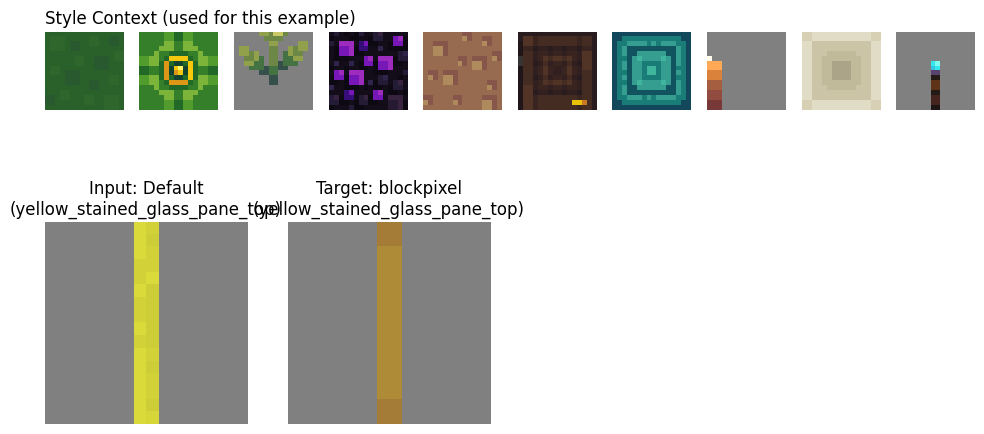

Pack ID: blockpixel
Texture Name: yellow_stained_glass_pane_top
Context Textures used for Style Vector (10):
  - green_concrete
  - green_shulker_box
  - pitcher_crop_bottom_stage_3
  - crying_obsidian
  - brown_mushroom_block
  - dark_oak_door_top
  - stripped_warped_stem_top
  - brown_candle_lit
  - bone_block_top
  - soul_torch


In [10]:
# NOTE: EVERY TIME YOU RUN THIS, YOU GET A DIFFERENT EXAMPLE (AS WE WANT)

import matplotlib.pyplot as plt

# make a tiny loader so we can sample from the dev set
sample_loader = DataLoader(dev_dataset, batch_size=1, shuffle=True)

# grab a single random triplet from dev
batch = next(iter(sample_loader))

# unpack batch (batch_size=1, so index with [0])
pack_id = batch["pack_id"][0]
texture_name = batch["texture_name"][0]

# --- REAL context names from dataset (no re-sampling) ---
# batch["context_names"] is a list of K tuples, each of length 1
raw_context = batch["context_names"]
context_names = [t[0] for t in raw_context]   # list of K strings (the actual neighbors)

# 1. get default image (structure)
default_idx = train_dataset.default_map[texture_name]
default_img = default_dataset[default_idx]["image_rgb"]

# 2. get target image (from its pack dataset, untransformed PIL)
test_ds = pack_datasets[pack_id]
target_img = None
for i in range(len(test_ds)):
    fname = test_ds.image_files[i]
    tname = os.path.splitext(fname)[0]
    if tname == texture_name:
        target_img = test_ds[i]["image_rgb"]
        break

if target_img is None:
    raise RuntimeError(f"Could not find target texture {texture_name} in pack {pack_id}")

# --- Visualization (EXACT old layout style) ---
plt.figure(figsize=(12, 6))

# Row 1: The 10 Context Images (Style Source) — now using *real* context_names
for i, name in enumerate(context_names):
    if i >= 10:
        break  # keep the old "10 slots" layout
    found = False
    for j in range(len(test_ds)):
        if os.path.splitext(test_ds.image_files[j])[0] == name:
            img = test_ds[j]["image_rgb"]
            plt.subplot(2, 10, i + 1)
            plt.imshow(img)
            plt.axis("off")
            if i == 0:
                plt.title("Style Context (used for this example)", loc="left")
            found = True
            break
    if not found:
        plt.subplot(2, 10, i + 1)
        plt.text(0.5, 0.5, "Not Found", ha="center", va="center")
        plt.axis("off")

# Row 2: The Triplet (Structure -> Target) with the *same* positions as your old code
# A. Default (Input)
plt.subplot(2, 4, 5)
plt.imshow(default_img)
plt.title(f"Input: Default\n({texture_name})")
plt.axis("off")

# B. Target (Ground Truth)
plt.subplot(2, 4, 6)
plt.imshow(target_img)
plt.title(f"Target: {pack_id}\n({texture_name})")
plt.axis("off")

plt.tight_layout()
plt.show()

print(f"Pack ID: {pack_id}")
print(f"Texture Name: {texture_name}")
print(f"Context Textures used for Style Vector ({len(context_names)}):")
for n in context_names:
    print("  -", n)

In [11]:
# install latest diffusers and huggingface_hub to fix version conflicts
!pip install -U diffusers huggingface_hub transformers accelerate

# install ip-adapter
!pip install git+https://github.com/tencent-ailab/IP-Adapter.git

  Using cached huggingface_hub-1.2.1-py3-none-any.whl.metadata (13 kB)
  Cloning https://github.com/tencent-ailab/IP-Adapter.git to /tmp/pip-req-build-bd7mvzlg
  Running command git clone --filter=blob:none --quiet https://github.com/tencent-ailab/IP-Adapter.git /tmp/pip-req-build-bd7mvzlg
  Resolved https://github.com/tencent-ailab/IP-Adapter.git to commit 62e4af9d0c1ac7d5f8dd386a0ccf2211346af1a2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [12]:
from huggingface_hub import hf_hub_download

if os.path.exists("sdxl_models/image_encoder"):
    shutil.rmtree("sdxl_models/image_encoder")

hf_hub_download(
    repo_id="h94/IP-Adapter",
    filename="sdxl_models/ip-adapter_sdxl_vit-h.safetensors",
    local_dir=".",
    local_dir_use_symlinks=False,
)

files_to_get = [
    "models/image_encoder/config.json",
    "models/image_encoder/model.safetensors",
]

for fname in files_to_get:
    hf_hub_download(
        repo_id="h94/IP-Adapter",
        filename=fname,
        local_dir=".",
        local_dir_use_symlinks=False,
    )

print("Download complete.")
print("Adapter: sdxl_models/ip-adapter_sdxl_vit-h.safetensors")
print("Encoder: models/image_encoder (ViT-H Config)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:979: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Download complete.
Adapter: sdxl_models/ip-adapter_sdxl_vit-h.safetensors
Encoder: models/image_encoder (ViT-H Config)


In [13]:
from diffusers import StableDiffusionXLImg2ImgPipeline # <-- CHANGED IMPORT
from ip_adapter import IPAdapterXL
import torch
import torch.nn as nn
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Load SDXL Img2Img pipeline in fp32
model_id = "stabilityai/stable-diffusion-xl-base-1.0"
pipe = StableDiffusionXLImg2ImgPipeline.from_pretrained( # <-- CHANGED PIPELINE
    model_id,
    torch_dtype=torch.float32,
    use_safetensors=True,
)
pipe.to(device=device, dtype=torch.float32)
pipe.vae.eval()

# 2. Load IP-Adapter (Standard, ViT-H)
ip_adapter_ckpt = "sdxl_models/ip-adapter_sdxl_vit-h.safetensors"
image_encoder_path = "models/image_encoder"

ip_model = IPAdapterXL(pipe, image_encoder_path, ip_adapter_ckpt, device)

# 2b. Your external CLIP style encoder (already created as `model`)
# Make sure it's on the same device & dtype
model.to(device=device, dtype=torch.float32)

# --- Make sure key modules are fp32 on the right device ---
pipe.unet.to(device=device, dtype=torch.float32)
pipe.vae.to(device=device, dtype=torch.float32)
pipe.text_encoder.to(device=device, dtype=torch.float32)
pipe.text_encoder_2.to(device=device, dtype=torch.float32)

ip_model.image_encoder.to(device=device, dtype=torch.float32)
ip_model.image_proj_model.to(device=device, dtype=torch.float32)

# 3. Freeze base SDXL + external CLIP
pipe.unet.requires_grad_(False)
pipe.vae.requires_grad_(False)
pipe.text_encoder.requires_grad_(False)
pipe.text_encoder_2.requires_grad_(False)

for p in model.parameters():
    p.requires_grad = False

# 4. Phase 1: Train IP-Adapter projection + UNet adapter modules

# A. Unfreeze the image projection MLP
ip_model.image_proj_model.requires_grad_(True)
ip_model.image_proj_model.train()

# B. Unfreeze the adapter modules inside UNet (attention processors)
adapter_modules = nn.ModuleList(pipe.unet.attn_processors.values())
adapter_modules.requires_grad_(True)
adapter_modules.train()

# 5. Optimizer over ONLY the trainable IP-Adapter parts
trainable_params = (
    list(ip_model.image_proj_model.parameters()) +
    list(adapter_modules.parameters())
)

optimizer = optim.AdamW(
    trainable_params,
    lr=1e-4,
    weight_decay=1e-2,
)

print("Model Setup Complete (Phase 1: IP-Adapter + adapter modules, all fp32)")
print(f"Trainable param tensors: {len(trainable_params)}")
print("UNet dtype:          ", next(pipe.unet.parameters()).dtype)
print("Proj MLP dtype:      ", next(ip_model.image_proj_model.parameters()).dtype)
print("Image encoder dtype: ", next(ip_model.image_encoder.parameters()).dtype)
print("External CLIP dtype: ", next(model.parameters()).dtype)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Model Setup Complete (Phase 1: IP-Adapter + adapter modules, all fp32)
Trainable param tensors: 144
UNet dtype:           torch.float32
Proj MLP dtype:       torch.float32
Image encoder dtype:  torch.float32
External CLIP dtype:  torch.float32


In [14]:
print(preprocess)

Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_to_rgb at 0x7ac489a77ba0>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)


In [15]:
import logging
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt
from diffusers import StableDiffusionXLImg2ImgPipeline
from torchvision import transforms

# 1. Suppress Diffusers warnings
logging.getLogger("diffusers").setLevel(logging.ERROR)

# --- Optimized Custom Loss Function ---
class MinecraftTextureLoss(nn.Module):
    def __init__(self, clip_model, vae, noise_scheduler, lambda_style=1.0):
        super().__init__()
        self.clip_model = clip_model
        self.vae = vae
        self.noise_scheduler = noise_scheduler
        self.lambda_style = lambda_style

        # Differentiable preprocessing
        self.resize = transforms.Resize(
            224,
            interpolation=transforms.InterpolationMode.BICUBIC,
            antialias=True,
        )
        self.center_crop = transforms.CenterCrop(224)

        # CLIP normalization constants
        self.register_buffer(
            "clip_mean",
            torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1, 3, 1, 1),
        )
        self.register_buffer(
            "clip_std",
            torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1, 3, 1, 1),
        )

    def decode_latents(self, latents):
        # Decode using VAE dtype (you've set VAE to fp32 upstream)
        latents = latents.to(dtype=self.vae.dtype)
        latents = latents / self.vae.config.scaling_factor
        image = self.vae.decode(latents).sample
        return (image / 2 + 0.5).clamp(0, 1)

    def get_clip_features(self, images_01):
        # CLIP in float32
        images_01 = images_01.float()
        clip_input = self.resize(images_01)
        clip_input = self.center_crop(clip_input)
        clip_input = (clip_input - self.clip_mean) / self.clip_std
        feats = self.clip_model.encode_image(clip_input)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        return feats

    # --- MODIFIED FORWARD PASS ---
    def forward(
        self,
        pred_noise,
        timesteps,
        # NOTE: We now assume noisy_latents comes from the default image,
        # so we rely on the UNet call (in the train_loop) using the default latent (z_default)
        # as the starting point for adding noise.
        noisy_latents,
        target_images_norm,
        target_clip_embeds,
    ):
        # Upcast sensitive math to fp32
        pred_noise = pred_noise.float()
        noisy_latents = noisy_latents.float()
        target_images_norm = target_images_norm.float()
        target_clip_embeds = target_clip_embeds.float()

        # 🔧 ensure scheduler buffer matches latents *dtype* as well as device
        alphas_cumprod = self.noise_scheduler.alphas_cumprod.to(
            device=noisy_latents.device,
            dtype=noisy_latents.dtype,
        )
        alpha_prod_t = alphas_cumprod[timesteps].view(-1, 1, 1, 1)
        beta_prod_t = 1 - alpha_prod_t

        # avoid division by 0
        eps = 1e-8
        alpha_prod_t = alpha_prod_t.clamp(min=eps)

        # Pred original latent (which should be the target latent z_target)
        pred_original_latents = (noisy_latents - beta_prod_t.sqrt() * pred_noise) / alpha_prod_t.sqrt()

        pred_images = self.decode_latents(pred_original_latents)

        # dataset gives [-1, 1]; map back to [0, 1] for the L1
        target_images = (target_images_norm / 2 + 0.5).clamp(0, 1)

        l1_loss = F.l1_loss(pred_images, target_images)

        pred_style = self.get_clip_features(pred_images)
        target_style = target_clip_embeds.to(
            device=pred_style.device, dtype=pred_style.dtype
        )

        # just in case something upstream is NaN
        pred_style = torch.nan_to_num(pred_style)
        target_style = torch.nan_to_num(target_style)

        style_loss = F.mse_loss(pred_style, target_style)

        total = l1_loss + self.lambda_style * style_loss
        return total, l1_loss, style_loss
    # --- END MODIFIED FORWARD PASS ---

In [16]:
# validation logger
def log_validation(pipe, dev_dataloader, epoch, ip_model, device, num_samples=2):
    """
    Reuses the existing SDXL pipeline on GPU; does NOT create a new pipeline.
    """
    val_pipe = pipe
    val_pipe.to(device)
    val_pipe.set_progress_bar_config(disable=True)

    ip_model.image_proj_model.eval()
    val_pipe.unet.eval()

    batch = next(iter(dev_dataloader))
    print(f"Generating validation figures for Epoch {epoch}...")

    current_bs = len(batch["texture_name"])
    n_display = min(num_samples, current_bs)

    to_pil = transforms.ToPILImage()
    unet_dtype = val_pipe.unet.dtype

    for i in range(n_display):
        texture_name = batch["texture_name"][i]
        pack_id = batch["pack_id"][i]
        nice_name = texture_name.replace("_", " ")

        # 1. Context names
        context_names = [batch["context_names"][k][i] for k in range(len(batch["context_names"]))]

        # 2. Style embedding -> IP-Adapter tokens
        raw_clip_embed = batch["style_embedding"][i].unsqueeze(0).to(device=device, dtype=unet_dtype)
        neg_clip_embed = torch.zeros_like(raw_clip_embed)

        with torch.no_grad():
            ip_tokens = ip_model.image_proj_model(raw_clip_embed.unsqueeze(1))       # [1, 1, D]
            ip_tokens_neg = ip_model.image_proj_model(neg_clip_embed.unsqueeze(1))  # [1, 1, D]

        ip_adapter_embeds = torch.cat([ip_tokens_neg, ip_tokens], dim=0)  # [2, 1, D]

        # 3. Prepare input/default image
        def_tensor = batch["default_image"][i]  # assumed in [-1, 1]
        def_img_01 = (def_tensor / 2 + 0.5).clamp(0, 1)
        def_pil = to_pil(def_img_01)

        prompt = f"minecraft texture of {nice_name}"

        # 4. Generate image
        with torch.no_grad():
            images = val_pipe(
                prompt=prompt,
                image=def_pil,
                cross_attention_kwargs={"ip_adapter_embeds": ip_adapter_embeds},
                strength=0.45,
                guidance_scale=7.5,
                num_inference_steps=30,
                output_type="pil",
            ).images

        gen_img = images[0]

        # 5. Plot
        fig = plt.figure(figsize=(16, 8))
        ds = pack_datasets[pack_id]

        # Add full prompt as figure title
        fig.suptitle(f'Prompt: {prompt}', fontsize=10, y=0.98)

        # Row 1: Context
        for idx, name in enumerate(context_names):
            found = False
            for j in range(len(ds)):
                if os.path.splitext(ds.image_files[j])[0] == name:
                    img_pil = ds[j]["image_rgb"]
                    plt.subplot(2, 10, idx + 1)
                    plt.imshow(img_pil)
                    plt.axis("off")
                    if idx == 0:
                        plt.title(f"Style Context\n{pack_id}", loc="left", fontsize=10)
                    found = True
                    break
            if not found:
                plt.subplot(2, 10, idx + 1)
                plt.axis("off")

        # Row 2: Triplet
        # Default / input
        plt.subplot(2, 4, 5)
        plt.imshow(def_pil)
        plt.title(f"Input\n({nice_name})")
        plt.axis("off")

        # Target
        tgt_tensor = batch["target_image"][i]  # assumed in [-1, 1]
        tgt_img = (tgt_tensor / 2 + 0.5).clamp(0, 1).permute(1, 2, 0).cpu().numpy()
        plt.subplot(2, 4, 6)
        plt.imshow(tgt_img)
        plt.title("Target")
        plt.axis("off")

        # Generated
        plt.subplot(2, 4, 7)
        plt.imshow(gen_img)
        plt.title(f"Generated (Ep {epoch})")
        plt.axis("off")

        # Leave room at the top for the prompt title
        plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.93])
        plt.show()
        plt.close(fig)

        print(f"Context Textures: {context_names}")

    # Restore train mode
    ip_model.image_proj_model.train()
    pipe.unet.train()

In [17]:
# 1. Initialize Loss (Uses default args which now contain the correct manual values)
minecraft_loss = MinecraftTextureLoss(
    clip_model=model,
    vae=pipe.vae,
    noise_scheduler=pipe.scheduler
).to(device)

print("Loss function initialized (Manual Differentiable Preprocess).")

# 2. Create Temp Loader
temp_loader = DataLoader(dev_dataset, batch_size=2, shuffle=True)

# 3. Run Verify
print("Running single verification batch...")
log_validation(pipe, temp_loader, epoch=0, ip_model=ip_model, device=device, num_samples=2)

Starting Training | Batch Size: 1 | Total Steps: 22263


Training:   0%|          | 0/22263 [00:00<?, ?step/s]

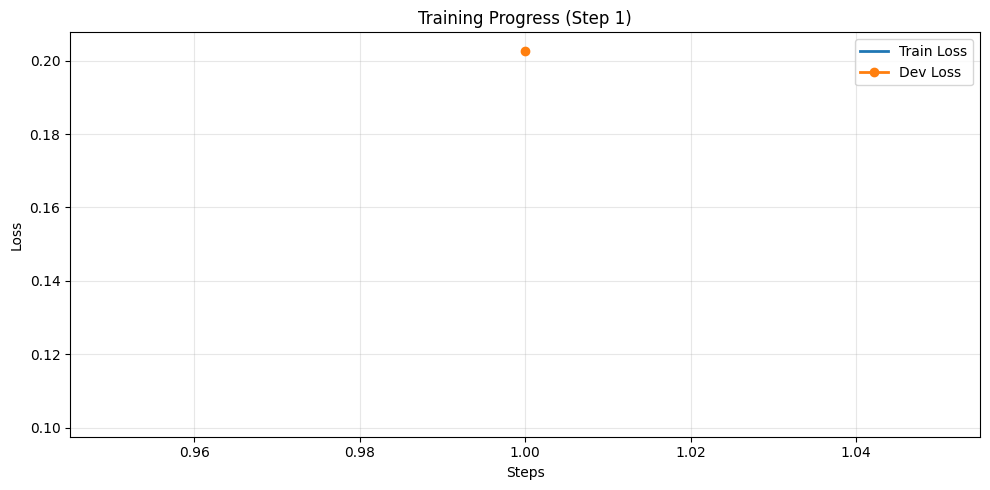


[VAL] Dev set samples:
Generating validation figures for Epoch 0...


/tmp/ipython-input-2504408696.py:107: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.93])


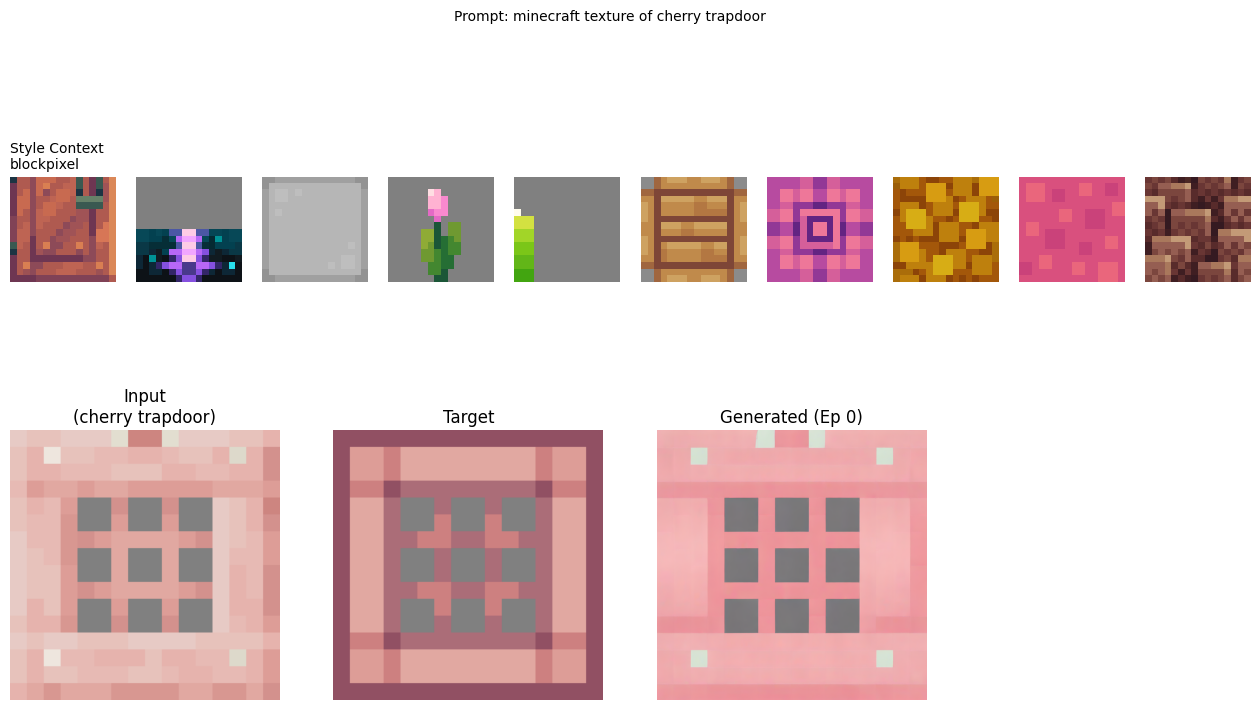

Context Textures: ['copper_door_bottom', 'calibrated_sculk_sensor_input_side', 'white_stained_glass', 'pink_tulip', 'lime_candle_lit', 'piston_top', 'shulker_box', 'horn_coral_block', 'pink_concrete', 'ancient_debris_side']


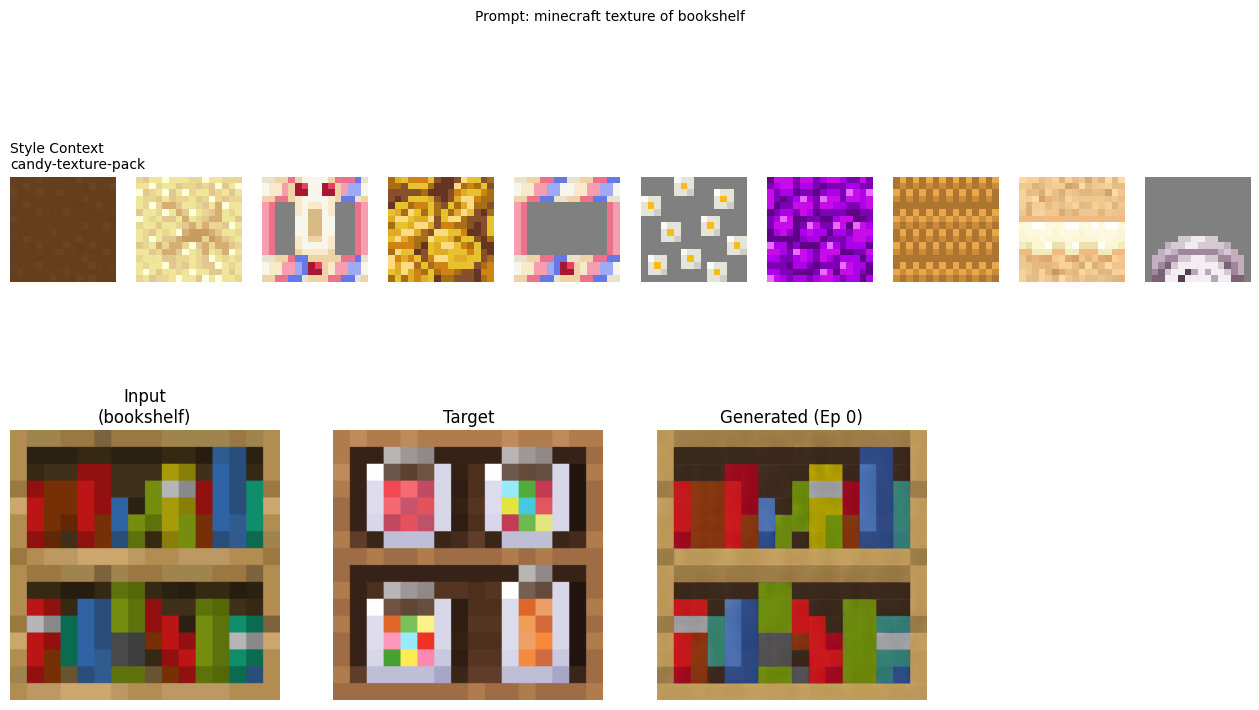

Context Textures: ['brown_concrete', 'suspicious_sand_2', 'vault_front_on_ominous', 'raw_gold_block', 'vault_side_on_ominous', 'frogspawn', 'magenta_wool', 'glass_pane_top', 'coarse_dirt', 'dead_horn_coral_fan']

[VAL] Train set samples:
Generating validation figures for Epoch 0...


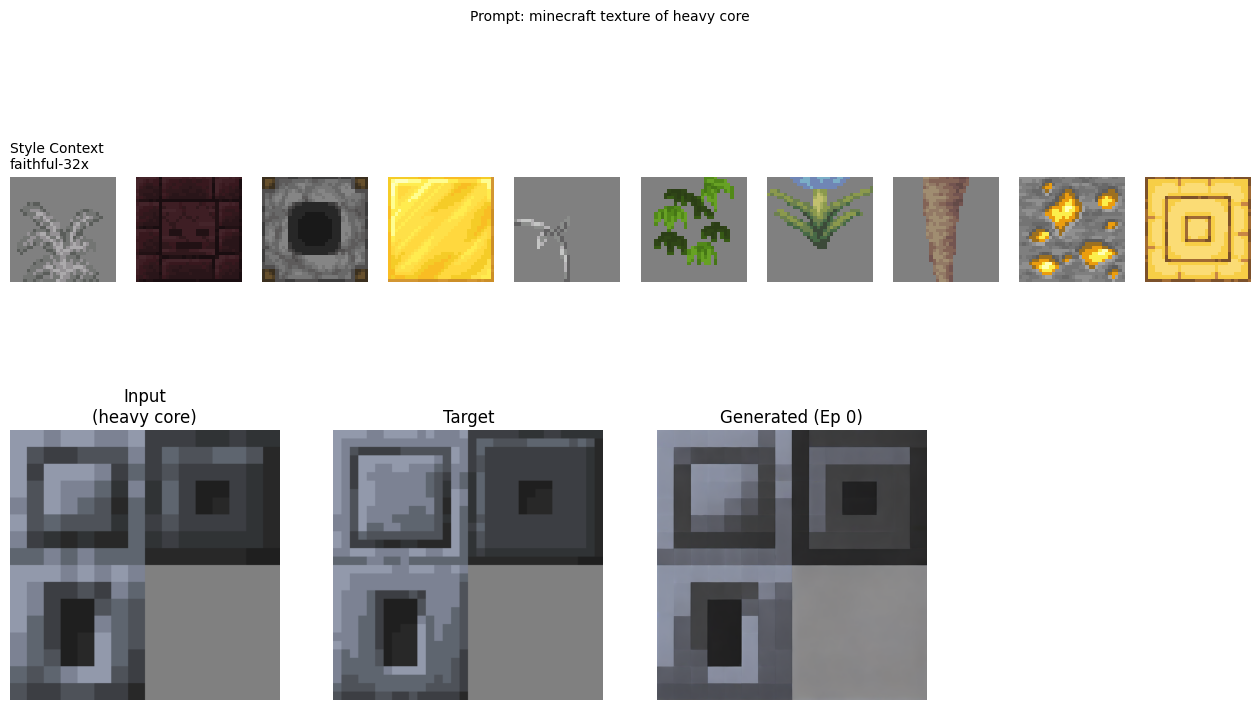

Context Textures: ['large_fern_top', 'chiseled_nether_bricks', 'smoker_top', 'gold_block', 'attached_melon_stem', 'bamboo_small_leaves', 'pitcher_crop_bottom_stage_4', 'pointed_dripstone_down_tip_merge', 'gold_ore', 'bee_nest_top']


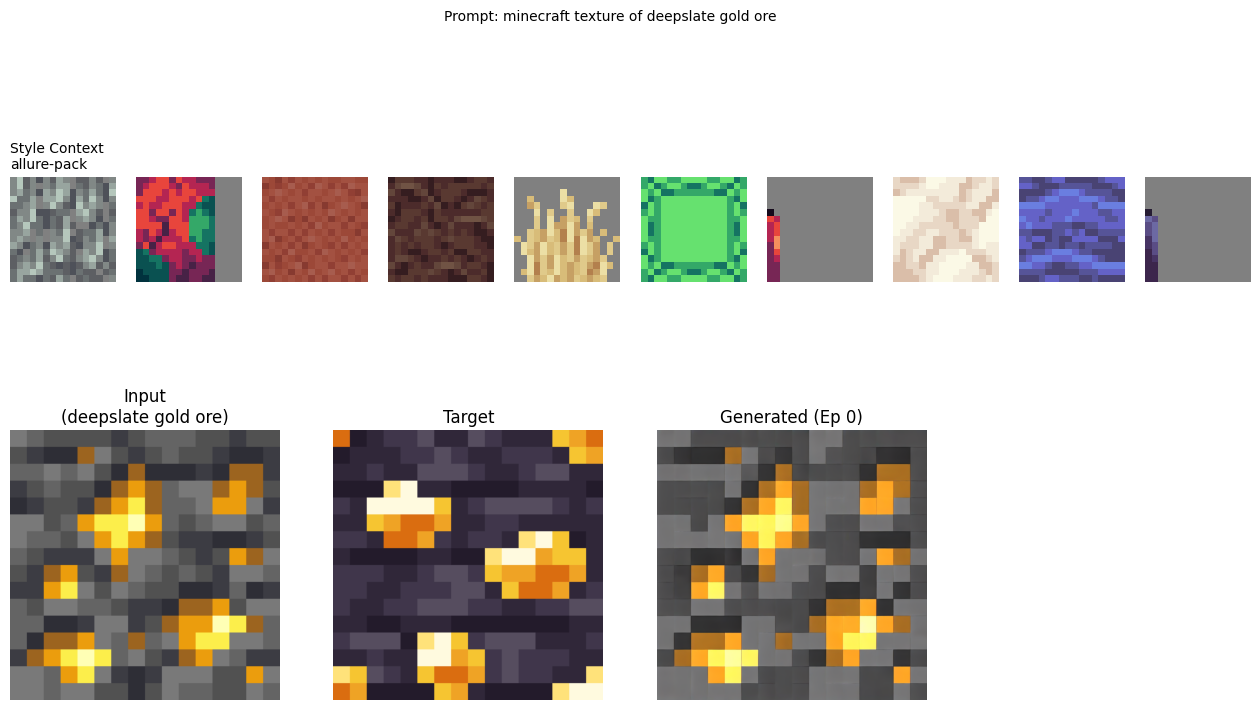

Context Textures: ['pale_oak_leaves', 'sniffer_egg_very_cracked_west', 'brown_concrete_powder', 'ancient_debris_top', 'tall_dry_grass', 'lime_shulker_box', 'red_candle', 'calcite', 'blue_terracotta', 'gray_candle_lit']
[step 50] total=0.2300 L1=0.2269 style=0.0008 λ_style=4.000 (style/L1 ≈ 0.01)
[step 100] total=0.2104 L1=0.2077 style=0.0007 λ_style=4.000 (style/L1 ≈ 0.01)
[step 150] total=0.0629 L1=0.0608 style=0.0005 λ_style=4.000 (style/L1 ≈ 0.04)
[step 200] total=0.1430 L1=0.1397 style=0.0008 λ_style=4.000 (style/L1 ≈ 0.02)
[step 250] total=0.1823 L1=0.1784 style=0.0010 λ_style=4.000 (style/L1 ≈ 0.02)
[step 300] total=0.0691 L1=0.0655 style=0.0009 λ_style=4.000 (style/L1 ≈ 0.06)
[step 350] total=0.0737 L1=0.0703 style=0.0008 λ_style=4.000 (style/L1 ≈ 0.05)
[step 400] total=0.1076 L1=0.1047 style=0.0007 λ_style=4.000 (style/L1 ≈ 0.03)
[step 450] total=0.2288 L1=0.2243 style=0.0011 λ_style=4.000 (style/L1 ≈ 0.02)
[step 500] total=0.0300 L1=0.0277 style=0.0006 λ_style=4.000 (style/L1 

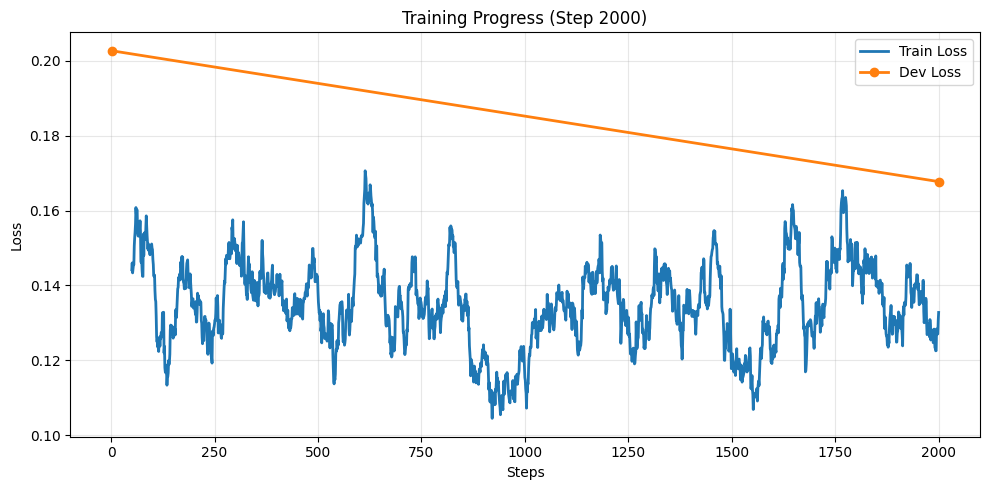


[VAL] Dev set samples:
Generating validation figures for Epoch 0...


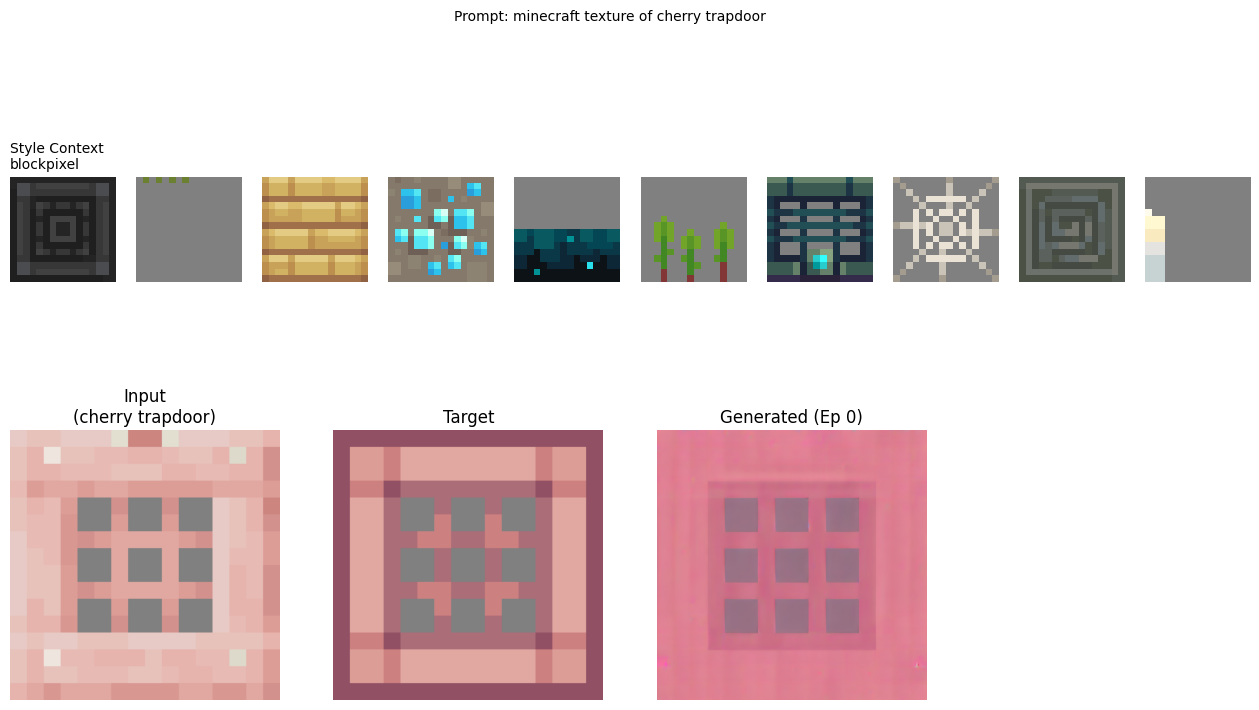

Context Textures: ['chiseled_deepslate', 'small_dripleaf_side', 'birch_planks', 'diamond_ore', 'sculk_sensor_side', 'beetroots_stage2', 'vault_side_on_ominous', 'cobweb', 'chiseled_tuff_top', 'white_candle_lit']


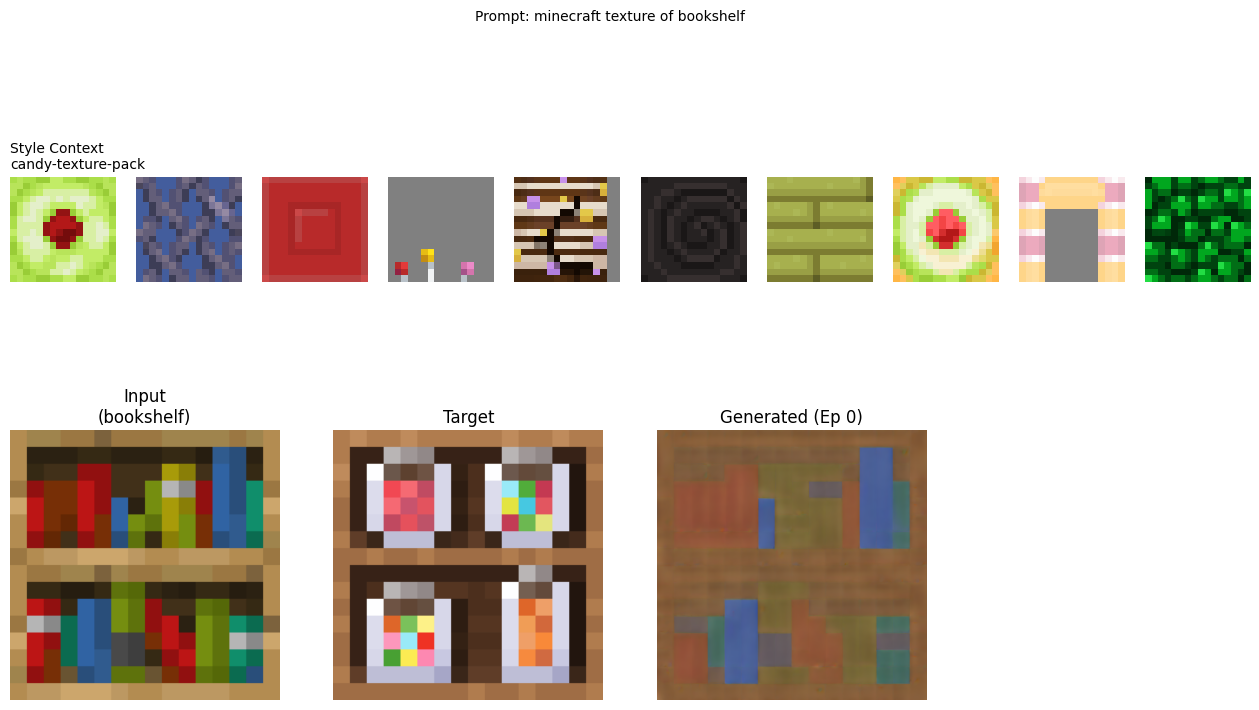

Context Textures: ['oxidized_copper_bulb', 'blue_stained_glass', 'beehive_end', 'wheat_stage1', 'sniffer_egg_slightly_cracked_south', 'sculk_sensor_bottom', 'acacia_planks', 'weathered_copper_bulb_lit_powered', 'bamboo_door_top', 'green_wool']

[VAL] Train set samples:
Generating validation figures for Epoch 0...


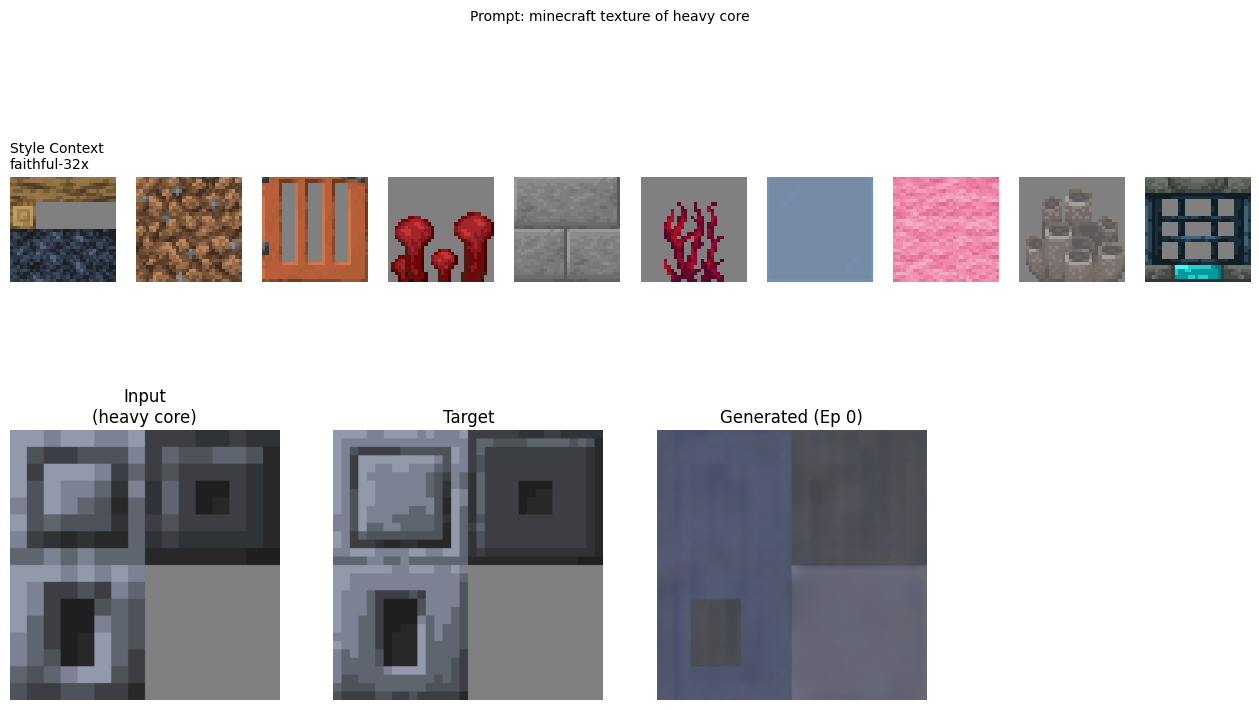

Context Textures: ['campfire_log', 'coarse_dirt', 'acacia_door_bottom', 'nether_wart_stage1', 'stone_bricks', 'crimson_roots_pot', 'light_blue_stained_glass', 'pink_wool', 'dead_tube_coral', 'vault_side_on_ominous']


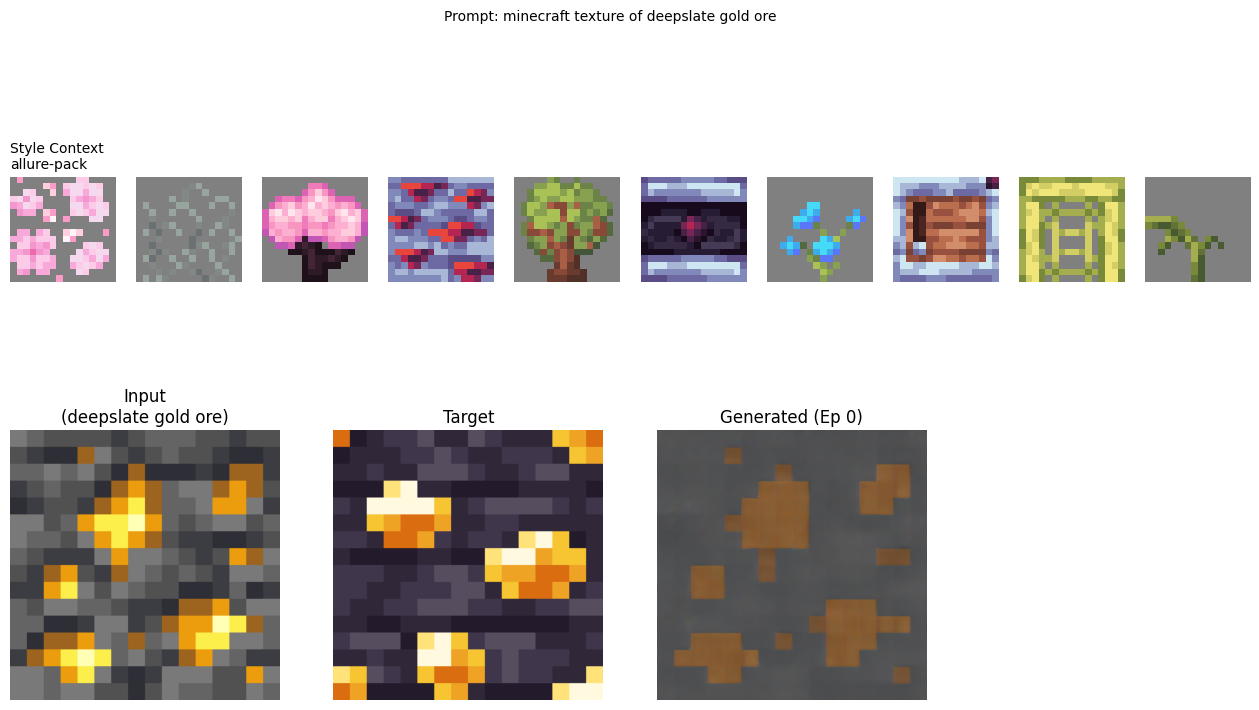

Context Textures: ['pink_petals', 'pale_moss_carpet_side_small', 'cherry_sapling', 'redstone_ore', 'oak_sapling', 'observer_back', 'blue_orchid', 'crafter_west', 'bamboo_door_top', 'attached_melon_stem']
[step 2050] total=0.3261 L1=0.3226 style=0.0009 λ_style=4.000 (style/L1 ≈ 0.01)
[step 2100] total=0.0245 L1=0.0221 style=0.0006 λ_style=4.000 (style/L1 ≈ 0.11)
[step 2150] total=0.1000 L1=0.0968 style=0.0008 λ_style=4.000 (style/L1 ≈ 0.03)
[step 2200] total=0.0933 L1=0.0892 style=0.0010 λ_style=4.000 (style/L1 ≈ 0.05)
[step 2250] total=0.0517 L1=0.0497 style=0.0005 λ_style=4.000 (style/L1 ≈ 0.04)
[step 2300] total=0.1358 L1=0.1327 style=0.0008 λ_style=4.000 (style/L1 ≈ 0.02)
[step 2350] total=0.2185 L1=0.2150 style=0.0009 λ_style=4.000 (style/L1 ≈ 0.02)
[step 2400] total=0.0834 L1=0.0796 style=0.0009 λ_style=4.000 (style/L1 ≈ 0.05)
[step 2450] total=0.1027 L1=0.1000 style=0.0007 λ_style=4.000 (style/L1 ≈ 0.03)
[step 2500] total=0.1112 L1=0.1076 style=0.0009 λ_style=4.000 (style/L1 ≈ 0.

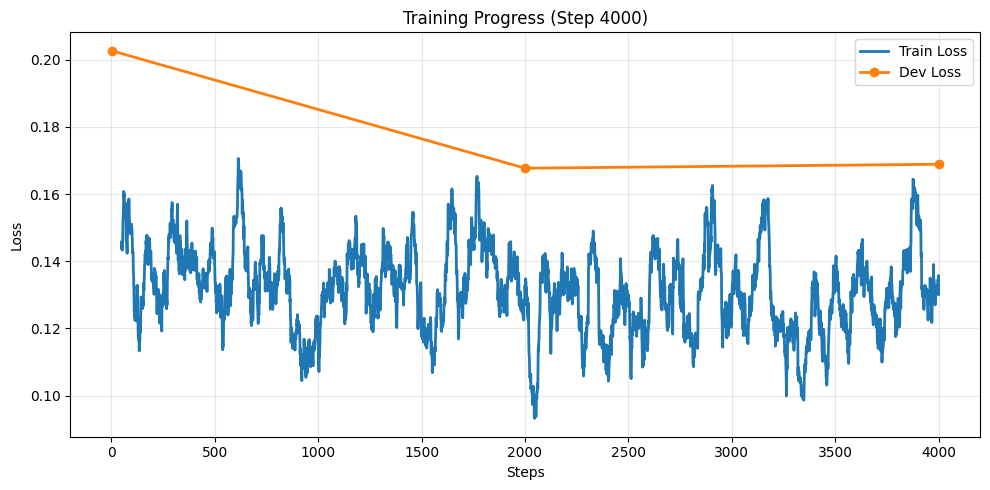


[VAL] Dev set samples:
Generating validation figures for Epoch 0...


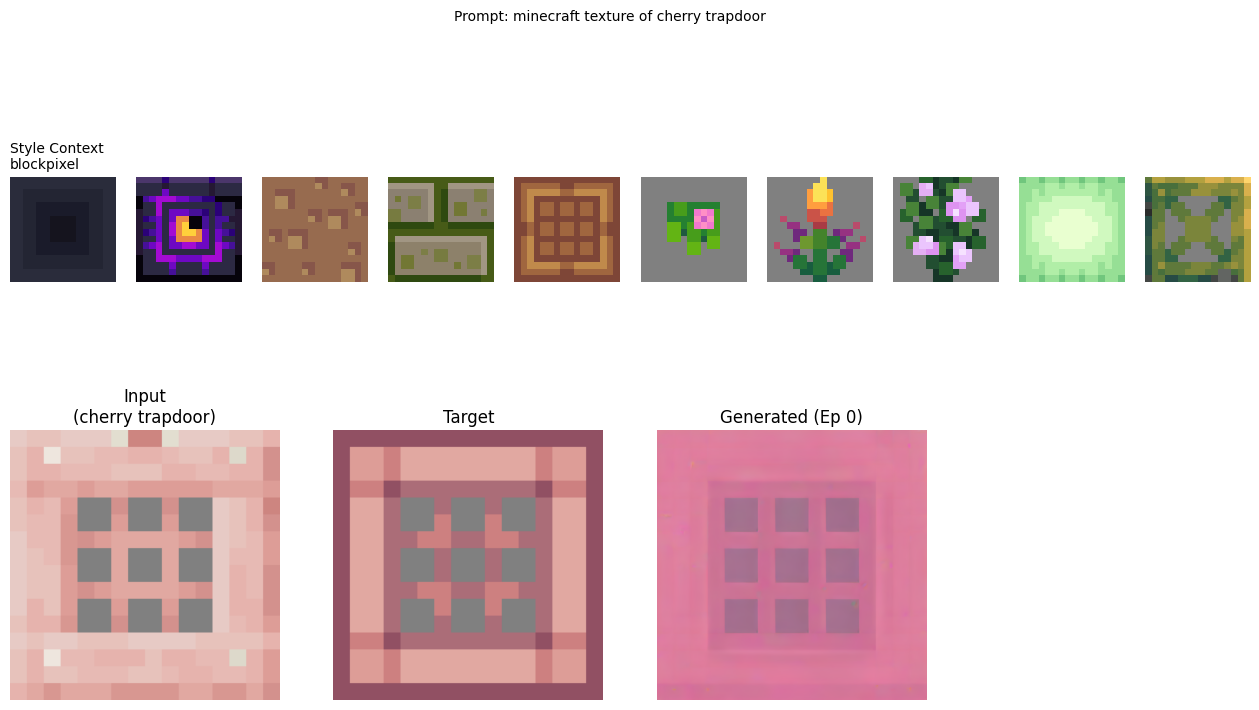

Context Textures: ['hopper_inside', 'respawn_anchor_side3', 'brown_mushroom_block', 'mossy_stone_bricks', 'crafting_table_top', 'potted_flowering_azalea_bush_side', 'torchflower', 'peony_bottom', 'verdant_froglight_side', 'weathered_copper_door_top']


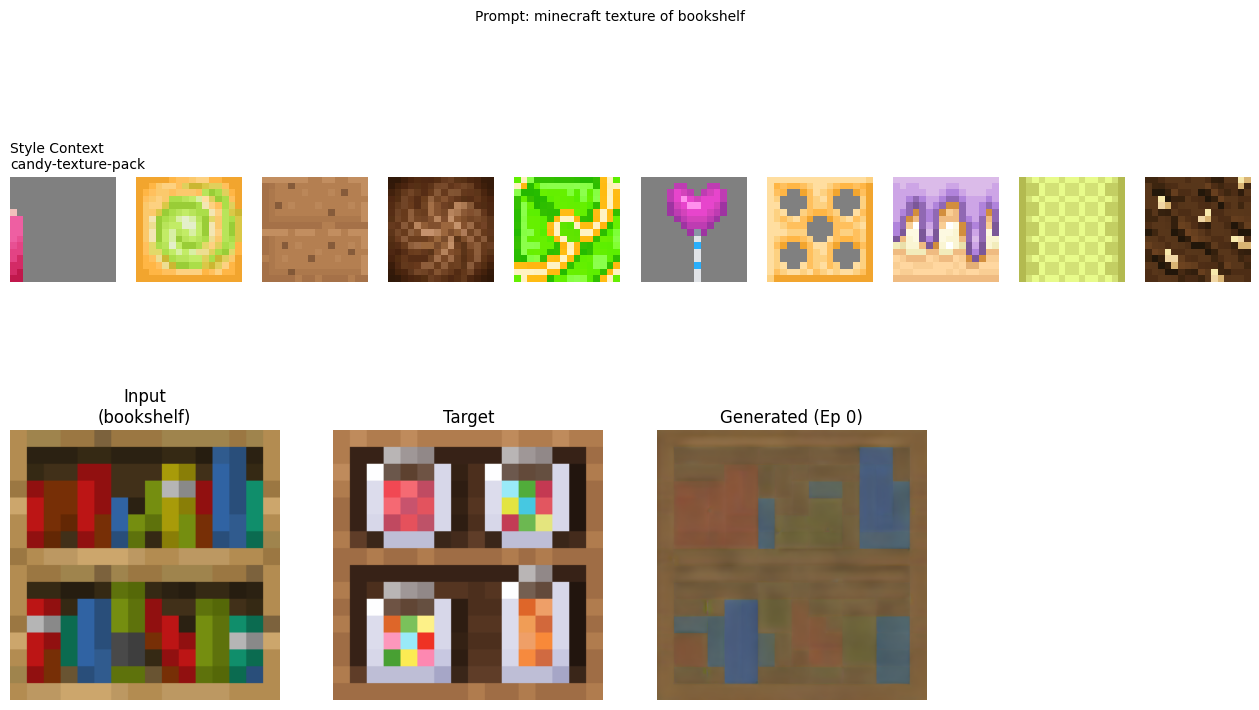

Context Textures: ['magenta_candle', 'exposed_chiseled_copper', 'chiseled_bookshelf_side', 'chiseled_stone_bricks', 'lime_glazed_terracotta', 'allium', 'copper_grate', 'mycelium_side', 'stripped_acacia_log', 'black_terracotta']

[VAL] Train set samples:
Generating validation figures for Epoch 0...


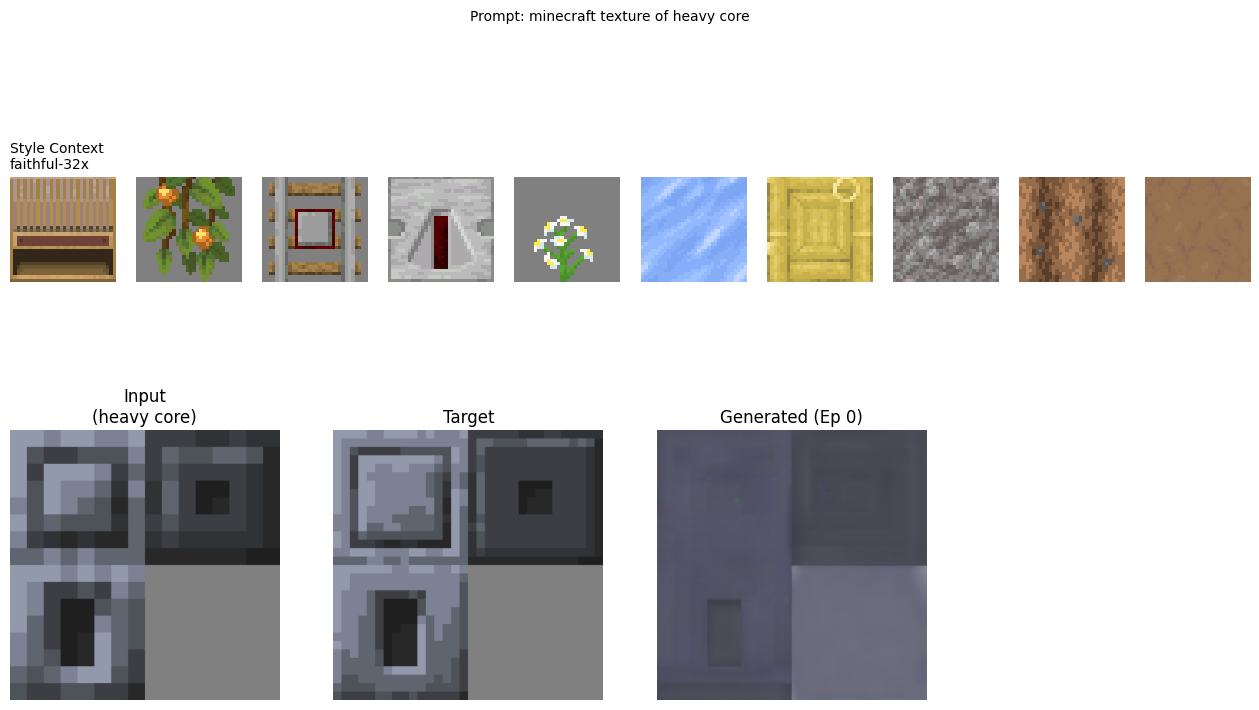

Context Textures: ['loom_front', 'cave_vines_lit', 'detector_rail', 'repeater', 'azure_bluet', 'packed_ice', 'bamboo_door_bottom', 'suspicious_gravel_0', 'farmland', 'brown_mushroom_block']


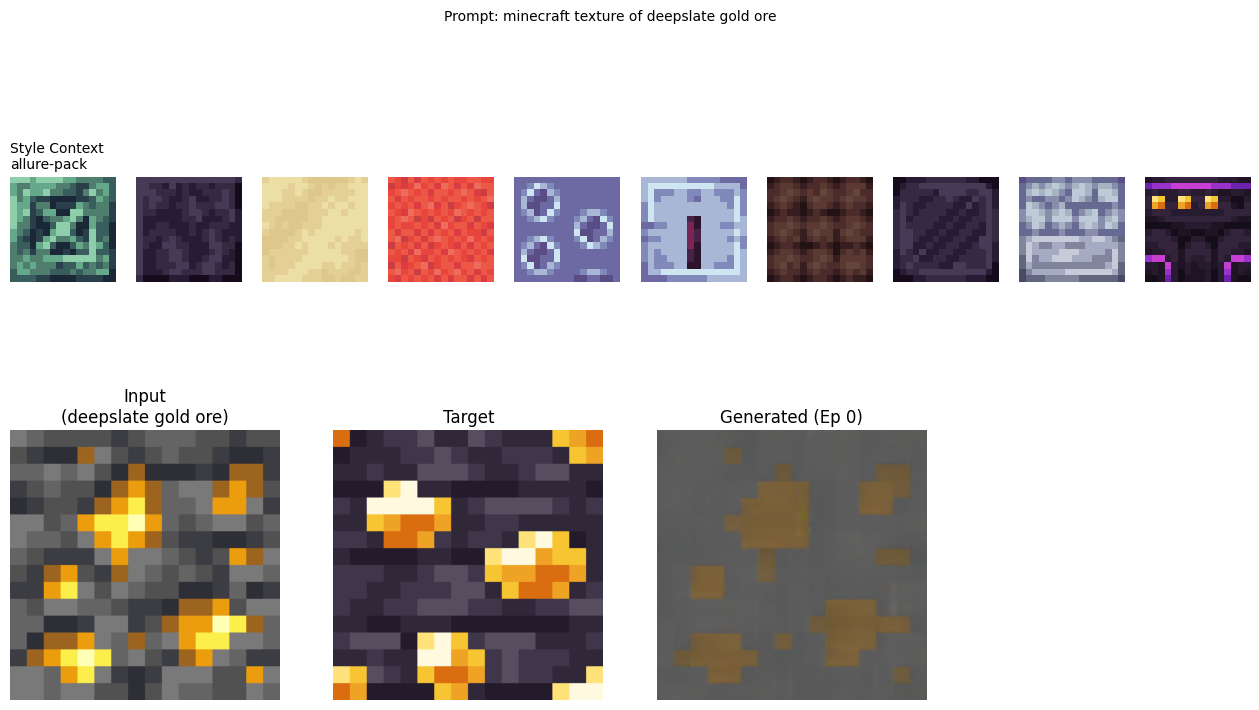

Context Textures: ['weathered_chiseled_copper', 'polished_blackstone', 'sandstone_top', 'red_concrete_powder', 'brewing_stand_base', 'repeater', 'daylight_detector_side', 'anvil', 'furnace_side', 'respawn_anchor_side3']
[step 4050] total=0.1186 L1=0.1164 style=0.0005 λ_style=4.000 (style/L1 ≈ 0.02)
[step 4100] total=0.1777 L1=0.1754 style=0.0006 λ_style=4.000 (style/L1 ≈ 0.01)
[step 4150] total=0.0568 L1=0.0550 style=0.0005 λ_style=4.000 (style/L1 ≈ 0.03)
[step 4200] total=0.0679 L1=0.0657 style=0.0005 λ_style=4.000 (style/L1 ≈ 0.03)
[step 4250] total=0.0455 L1=0.0426 style=0.0007 λ_style=4.000 (style/L1 ≈ 0.07)
[step 4300] total=0.0586 L1=0.0566 style=0.0005 λ_style=4.000 (style/L1 ≈ 0.03)
[step 4350] total=0.0793 L1=0.0743 style=0.0012 λ_style=4.000 (style/L1 ≈ 0.07)
[step 4400] total=0.1399 L1=0.1378 style=0.0005 λ_style=4.000 (style/L1 ≈ 0.02)
[step 4450] total=0.1969 L1=0.1942 style=0.0007 λ_style=4.000 (style/L1 ≈ 0.01)
[step 4500] total=0.1444 L1=0.1413 style=0.0008 λ_style=4.00

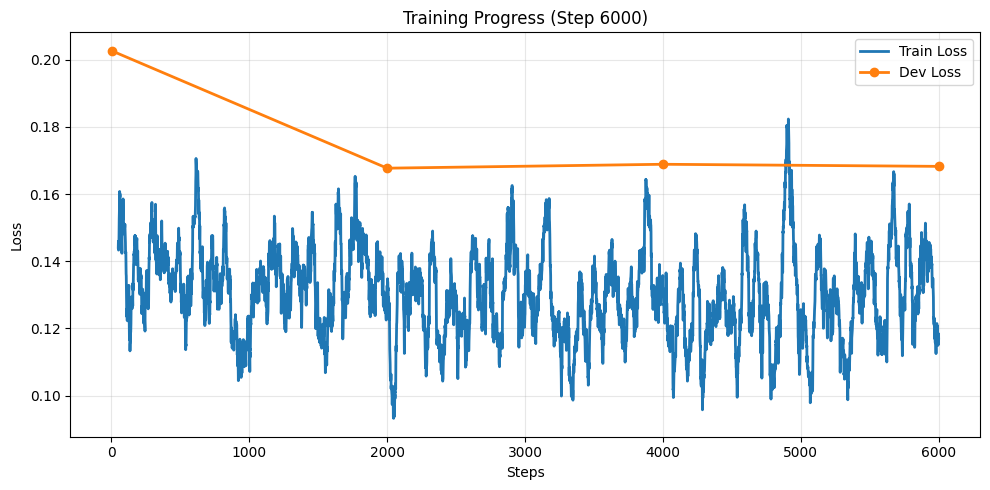


[VAL] Dev set samples:
Generating validation figures for Epoch 0...


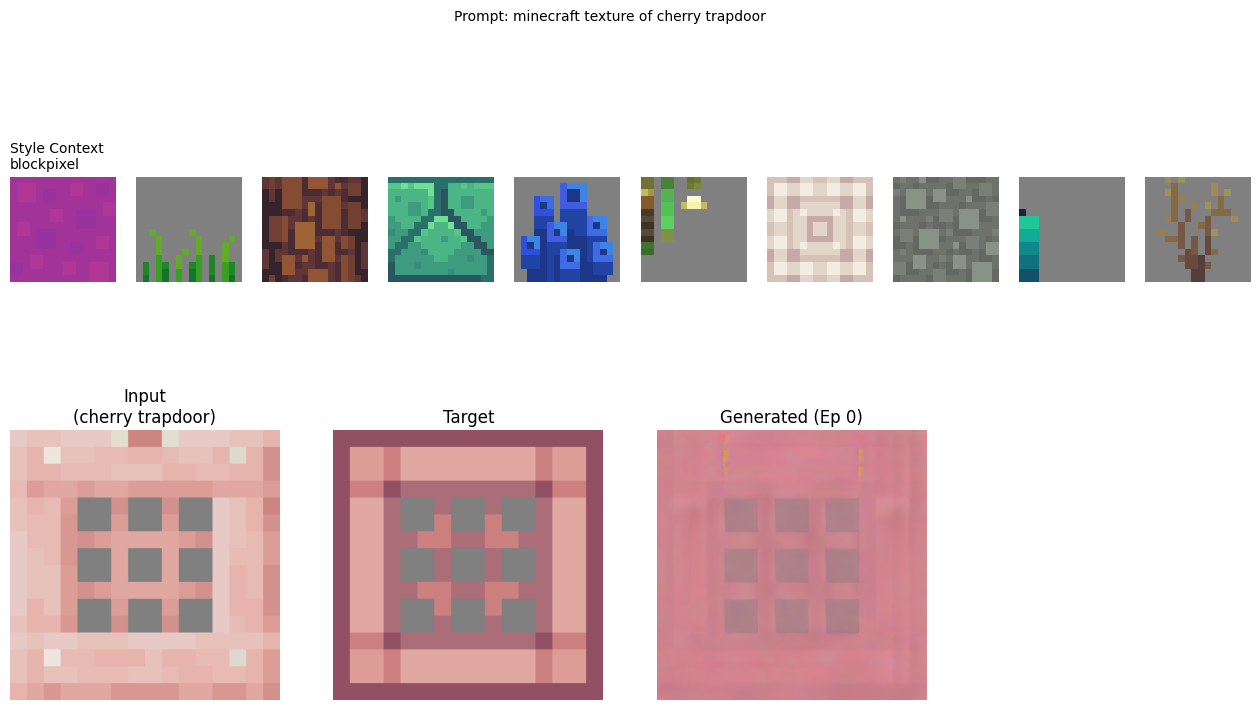

Context Textures: ['magenta_concrete', 'wheat_stage2', 'dark_oak_log', 'prismarine_bricks', 'tube_coral', 'mangrove_propagule_hanging', 'quartz_pillar_top', 'pale_moss_block', 'cyan_candle', 'dead_bush']


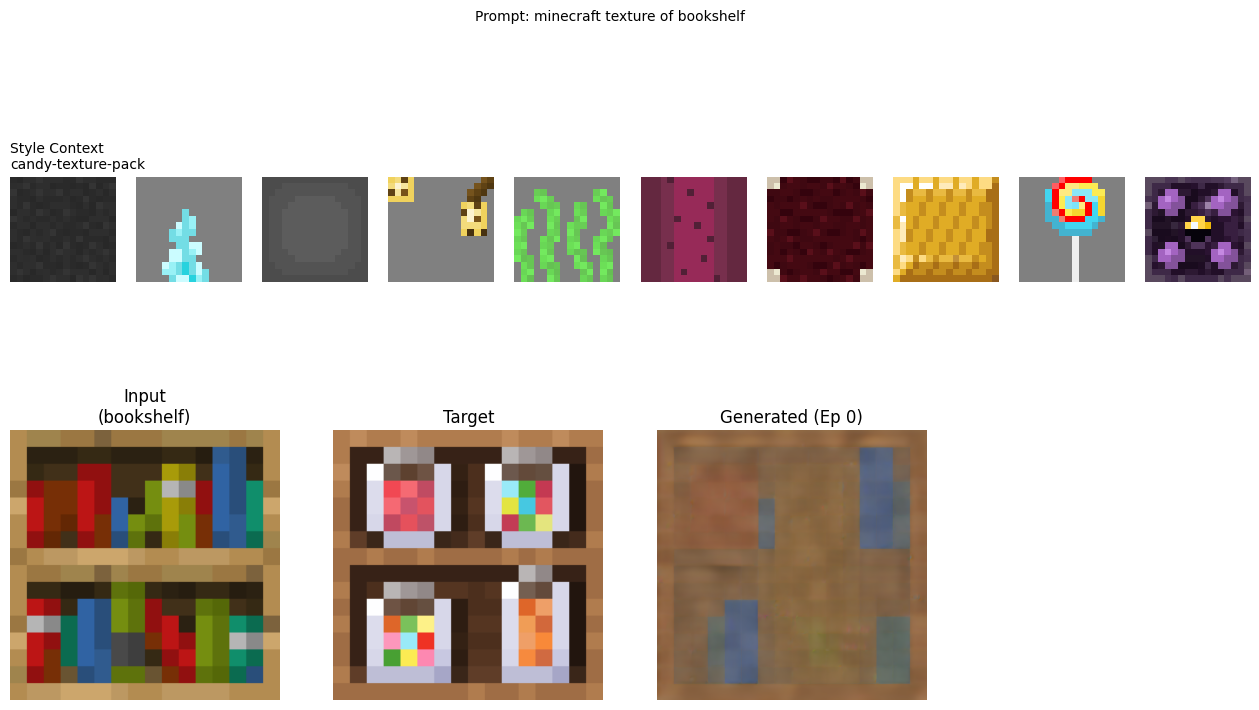

Context Textures: ['black_concrete', 'pointed_dripstone_up_tip', 'gray_shulker_box', 'cocoa_stage0', 'warped_roots', 'stripped_crimson_stem', 'reinforced_deepslate_bottom', 'gold_block', 'dead_bush', 'respawn_anchor_side2']

[VAL] Train set samples:
Generating validation figures for Epoch 0...


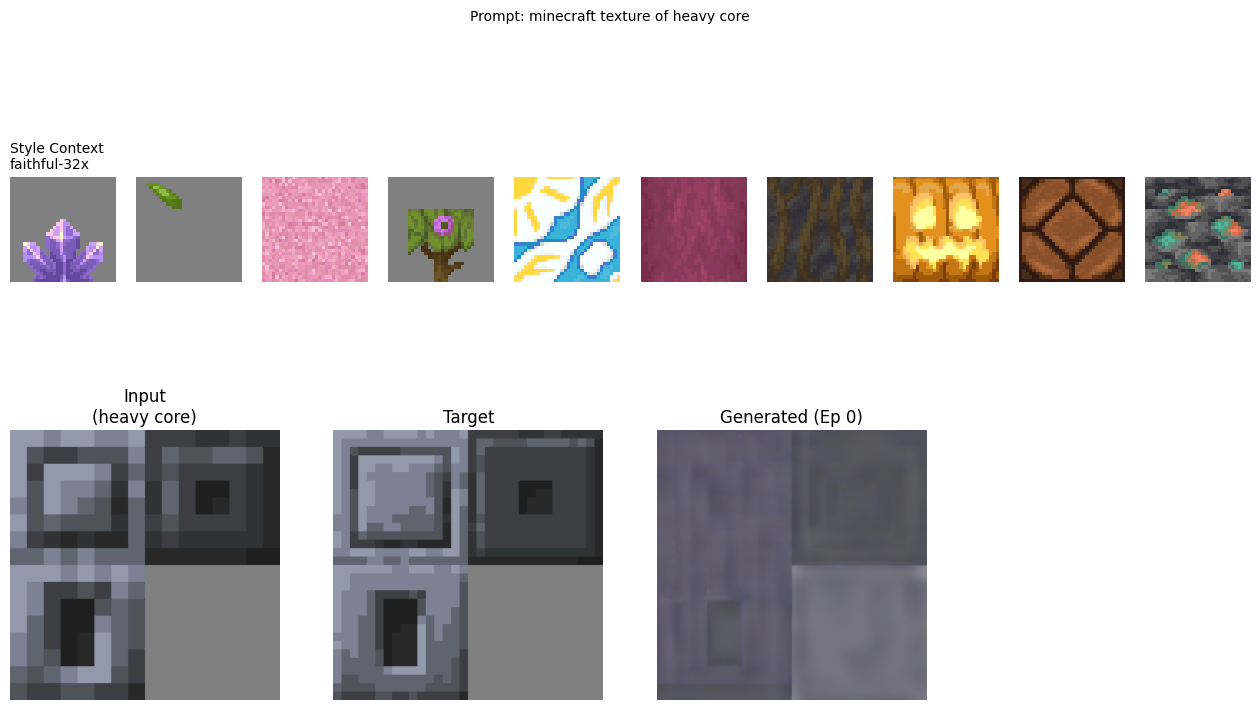

Context Textures: ['large_amethyst_bud', 'bamboo_singleleaf', 'pink_concrete_powder', 'potted_flowering_azalea_bush_plant', 'white_glazed_terracotta', 'stripped_crimson_stem', 'muddy_mangrove_roots_side', 'jack_o_lantern', 'redstone_lamp', 'deepslate_copper_ore']


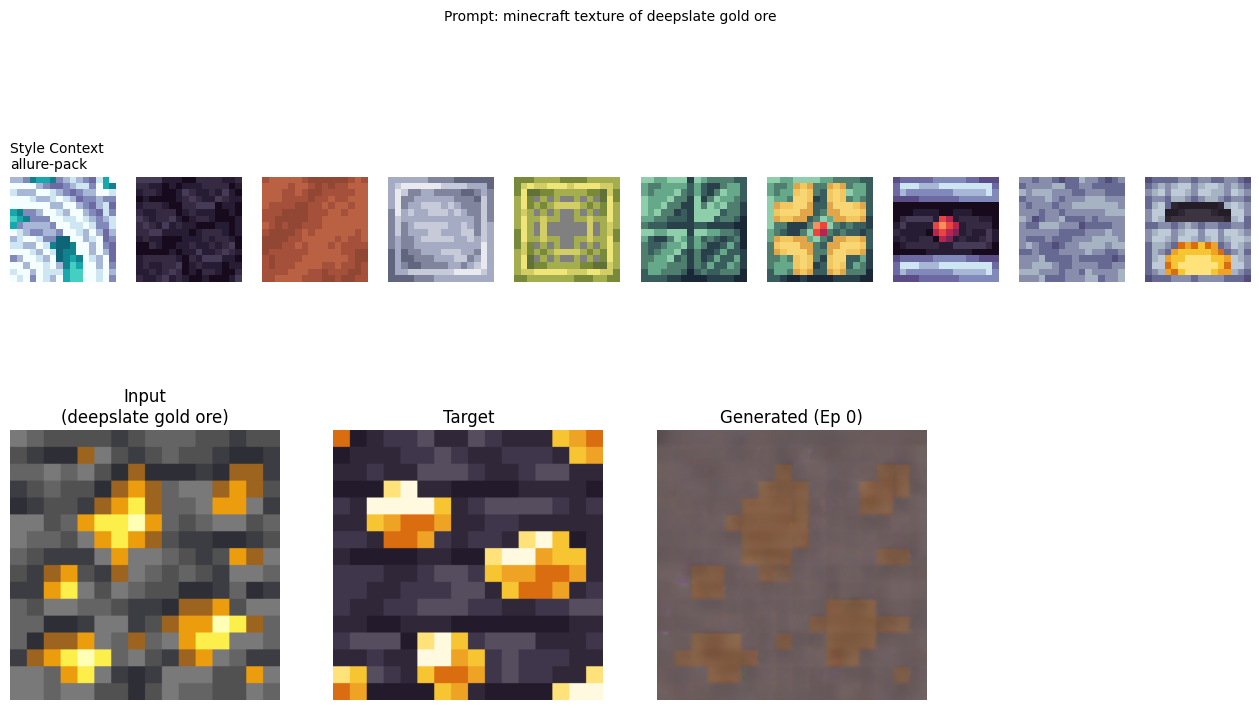

Context Textures: ['light_gray_glazed_terracotta', 'blackstone', 'red_sandstone_top', 'smooth_stone', 'bamboo_trapdoor', 'weathered_cut_copper', 'weathered_copper_bulb_lit_powered', 'observer_back_on', 'andesite', 'furnace_front_on']
[step 6050] total=0.1088 L1=0.1050 style=0.0009 λ_style=4.000 (style/L1 ≈ 0.04)
[step 6100] total=0.2005 L1=0.1978 style=0.0007 λ_style=4.000 (style/L1 ≈ 0.01)
[step 6150] total=0.2764 L1=0.2729 style=0.0009 λ_style=4.000 (style/L1 ≈ 0.01)
[step 6200] total=0.2473 L1=0.2430 style=0.0011 λ_style=4.000 (style/L1 ≈ 0.02)
[step 6250] total=0.0686 L1=0.0664 style=0.0006 λ_style=4.000 (style/L1 ≈ 0.03)
[step 6300] total=0.0772 L1=0.0751 style=0.0005 λ_style=4.000 (style/L1 ≈ 0.03)
[step 6350] total=0.1035 L1=0.1013 style=0.0006 λ_style=4.000 (style/L1 ≈ 0.02)
[step 6400] total=0.1203 L1=0.1187 style=0.0004 λ_style=4.000 (style/L1 ≈ 0.01)
[step 6450] total=0.1121 L1=0.1088 style=0.0008 λ_style=4.000 (style/L1 ≈ 0.03)
[step 6500] total=0.1115 L1=0.1091 style=0.000

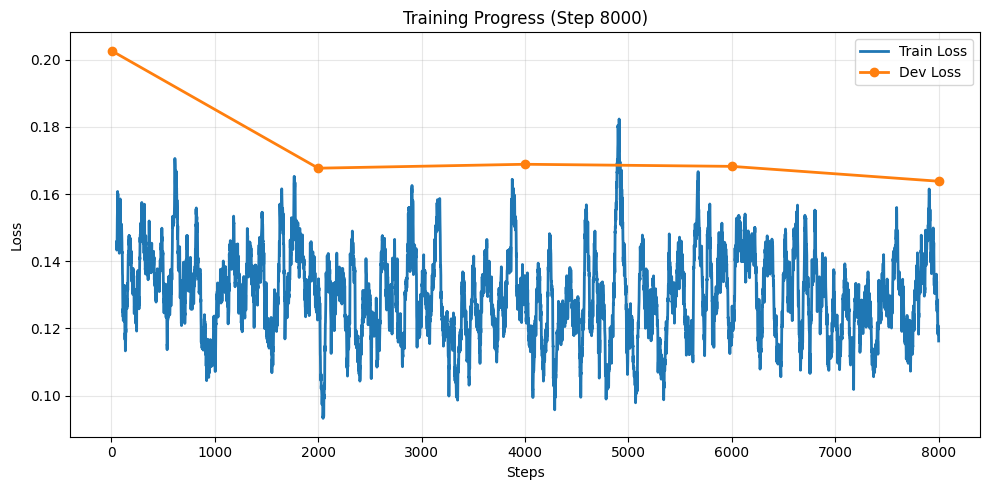


[VAL] Dev set samples:
Generating validation figures for Epoch 0...


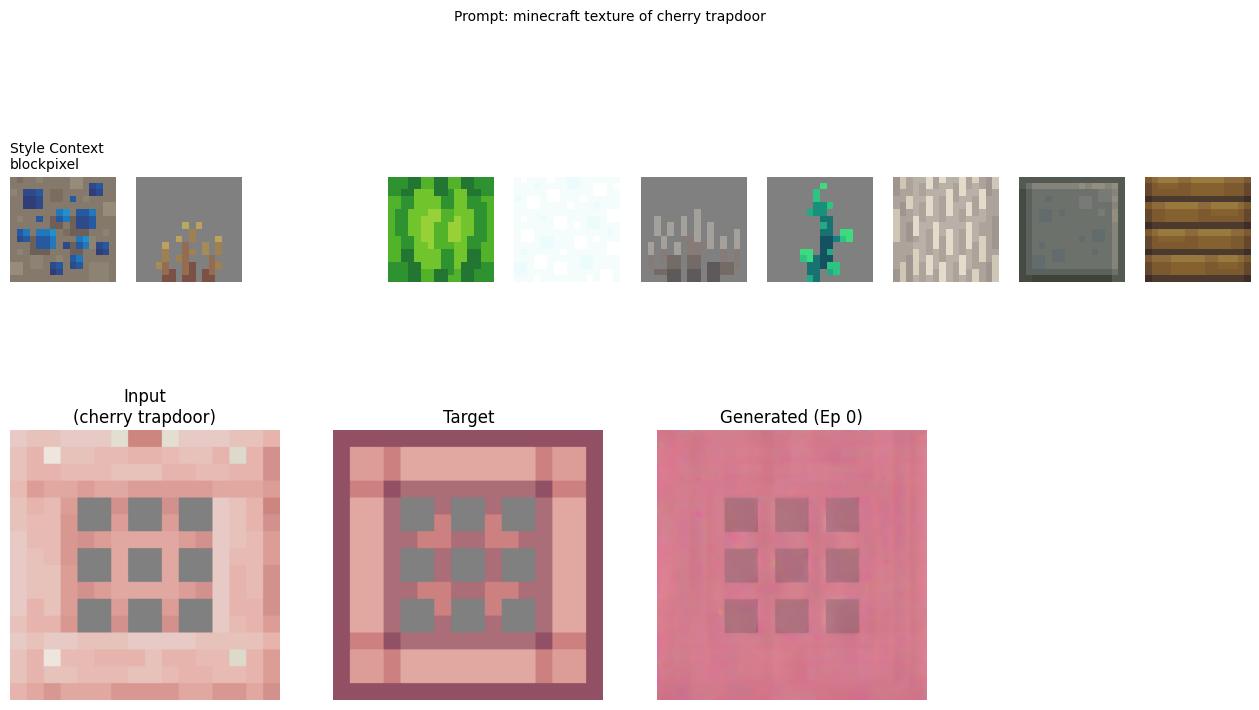

Context Textures: ['lapis_ore', 'short_dry_grass', 'lightning_rod_on', 'melon_side', 'powder_snow', 'dead_horn_coral_fan', 'twisting_vines', 'mushroom_stem', 'polished_tuff', 'spruce_planks']


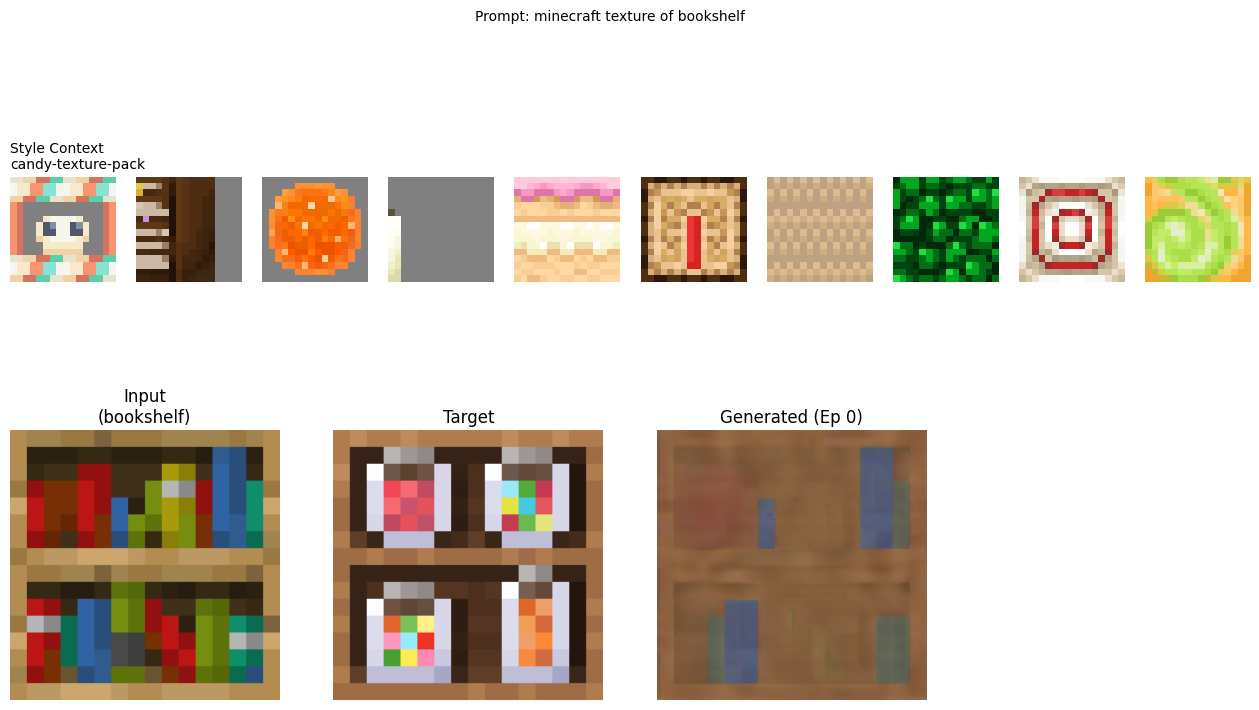

Context Textures: ['trial_spawner_side_inactive', 'sniffer_egg_not_cracked_east', 'lily_pad', 'candle_lit', 'grass_block_side', 'repeater_on', 'light_gray_stained_glass_pane_top', 'green_wool', 'target_side', 'weathered_copper_door_bottom']

[VAL] Train set samples:
Generating validation figures for Epoch 0...


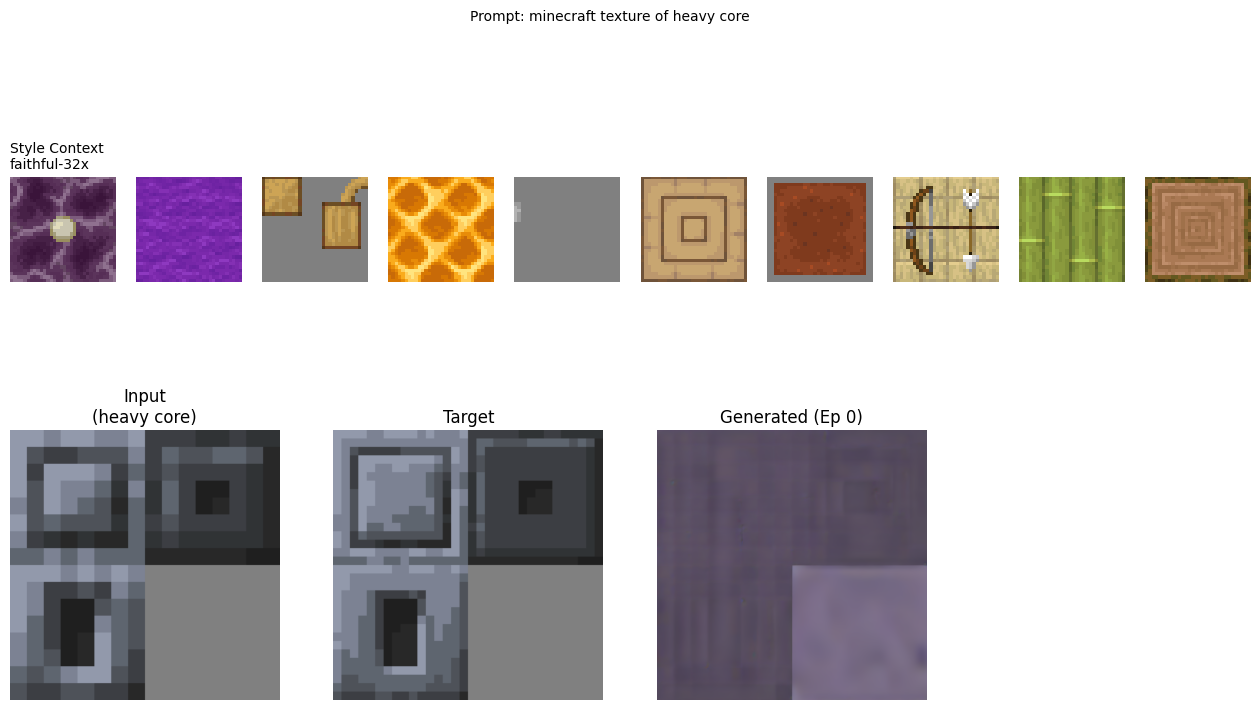

Context Textures: ['chorus_flower_dead', 'purple_wool', 'cocoa_stage1', 'honeycomb_block', 'pink_petals_stem', 'bee_nest_bottom', 'cake_bottom', 'fletching_table_front', 'bamboo_block', 'jungle_log_top']


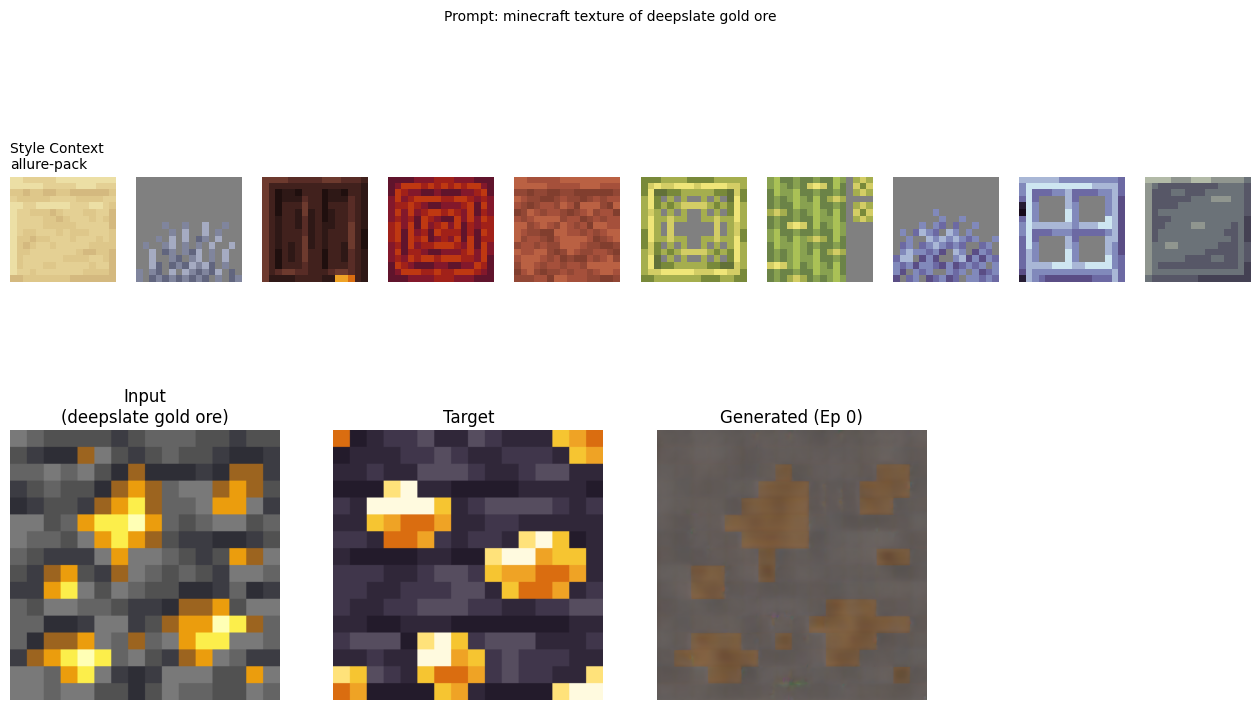

Context Textures: ['cut_sandstone', 'short_grass', 'dark_oak_door_top', 'stripped_mangrove_log_top', 'red_sandstone', 'bamboo_trapdoor', 'bamboo_stalk', 'dead_tube_coral_fan', 'iron_door_top', 'polished_tuff']
[step 8050] total=0.0663 L1=0.0628 style=0.0009 λ_style=4.000 (style/L1 ≈ 0.05)
[step 8100] total=0.3657 L1=0.3631 style=0.0007 λ_style=4.000 (style/L1 ≈ 0.01)
[step 8150] total=0.0919 L1=0.0896 style=0.0006 λ_style=4.000 (style/L1 ≈ 0.03)
[step 8200] total=0.2155 L1=0.2124 style=0.0008 λ_style=4.000 (style/L1 ≈ 0.01)
[step 8250] total=0.0983 L1=0.0945 style=0.0010 λ_style=4.000 (style/L1 ≈ 0.04)
[step 8300] total=0.0485 L1=0.0449 style=0.0009 λ_style=4.000 (style/L1 ≈ 0.08)
[step 8350] total=0.0342 L1=0.0315 style=0.0007 λ_style=4.000 (style/L1 ≈ 0.09)
[step 8400] total=0.1417 L1=0.1393 style=0.0006 λ_style=4.000 (style/L1 ≈ 0.02)
[step 8450] total=0.0681 L1=0.0661 style=0.0005 λ_style=4.000 (style/L1 ≈ 0.03)
[step 8500] total=0.0211 L1=0.0187 style=0.0006 λ_style=4.000 (style/L

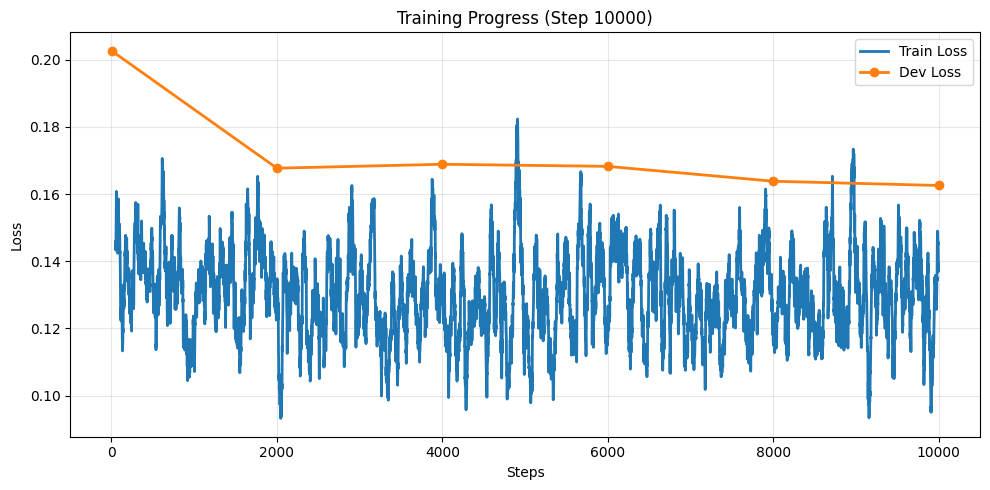


[VAL] Dev set samples:
Generating validation figures for Epoch 0...


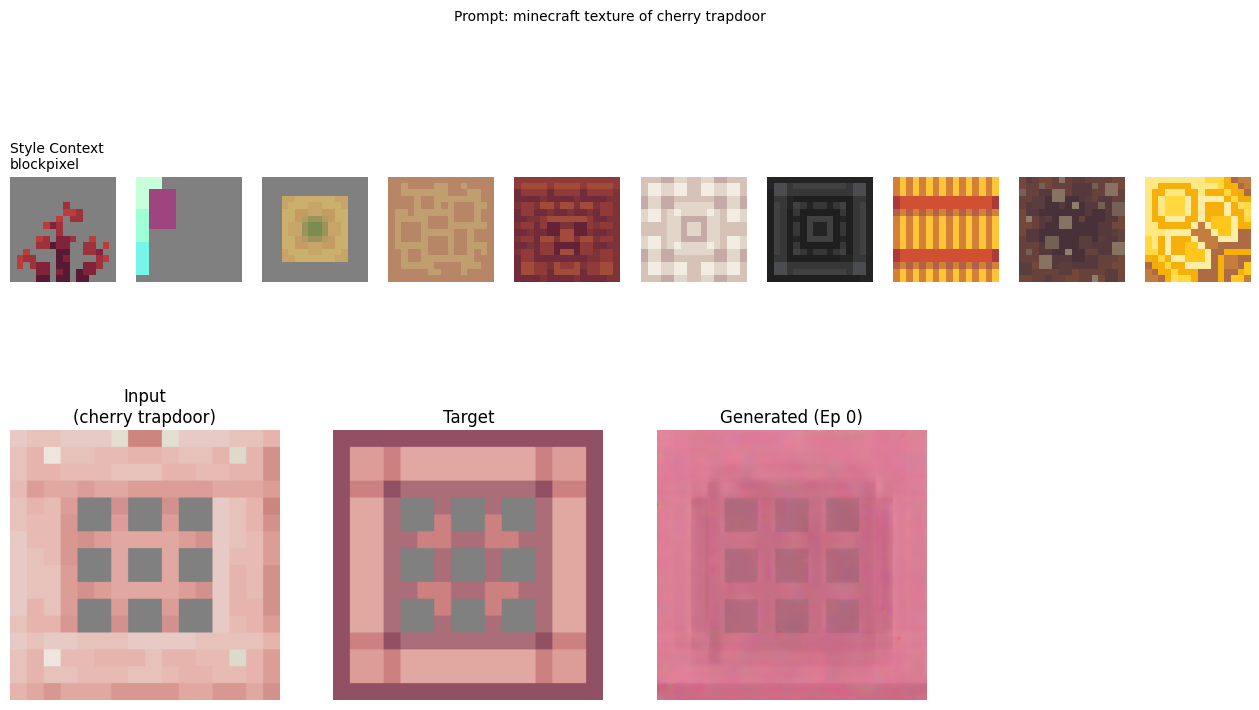

Context Textures: ['crimson_roots_pot', 'end_rod', 'pitcher_crop_top', 'sandstone_bottom', 'chiseled_red_sandstone', 'chiseled_quartz_block', 'chiseled_deepslate', 'hay_block_side', 'suspicious_gravel_3', 'yellow_glazed_terracotta']


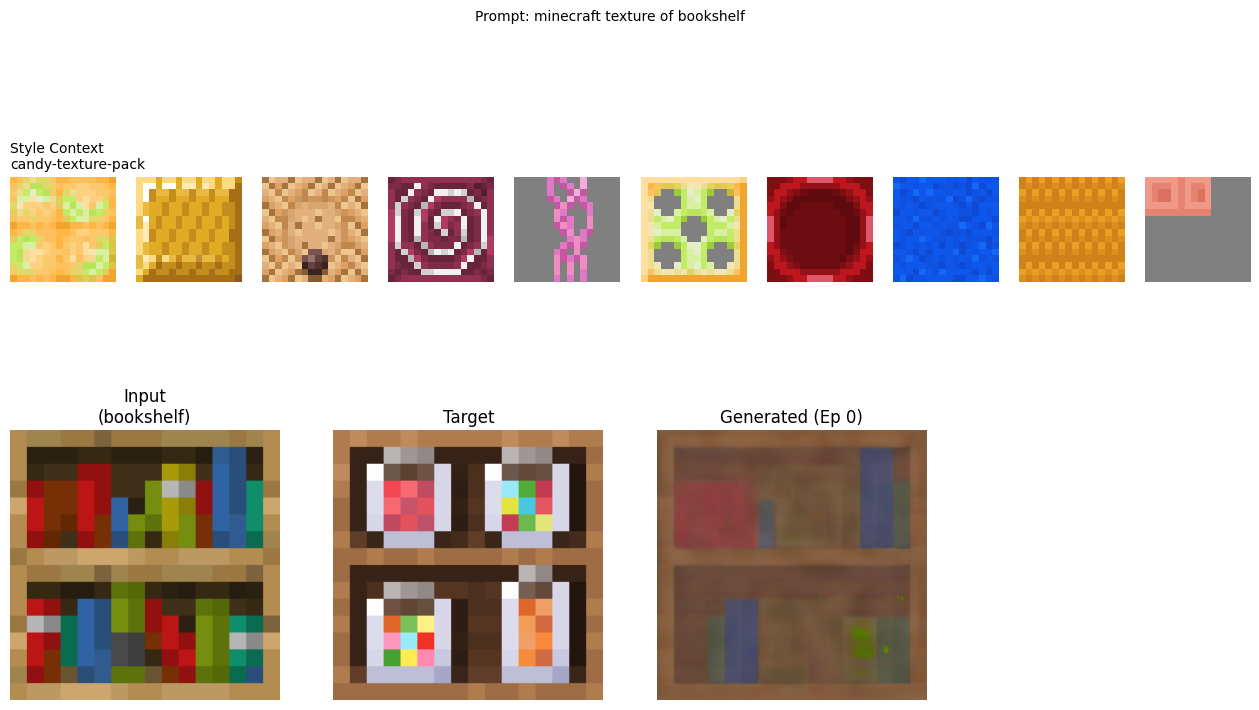

Context Textures: ['exposed_cut_copper', 'gold_block', 'spruce_trapdoor', 'crimson_stem_top', 'small_dripleaf_stem_bottom', 'weathered_copper_grate', 'chorus_flower_dead', 'blue_concrete_powder', 'orange_stained_glass_pane_top', 'grindstone_pivot']

[VAL] Train set samples:
Generating validation figures for Epoch 0...


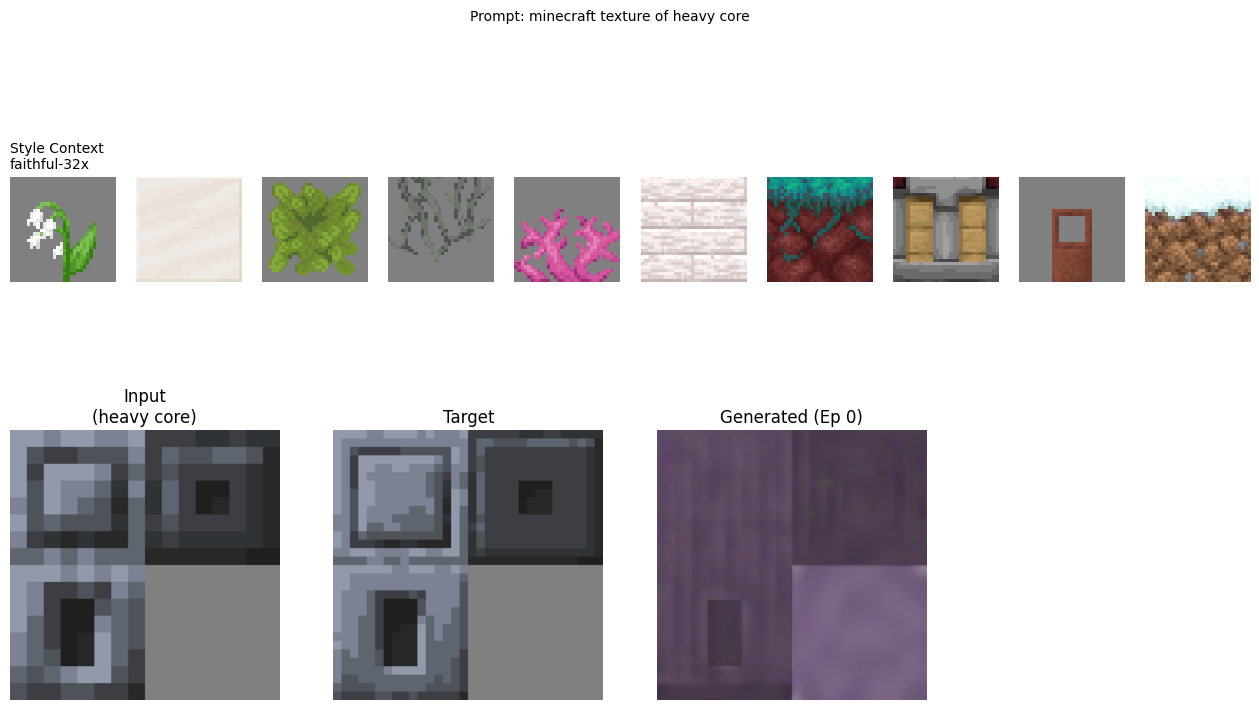

Context Textures: ['lily_of_the_valley', 'quartz_block_top', 'spore_blossom_base', 'pale_hanging_moss_tip', 'brain_coral_fan', 'pale_oak_planks', 'warped_nylium_side', 'crafter_south', 'flower_pot', 'grass_block_snow']


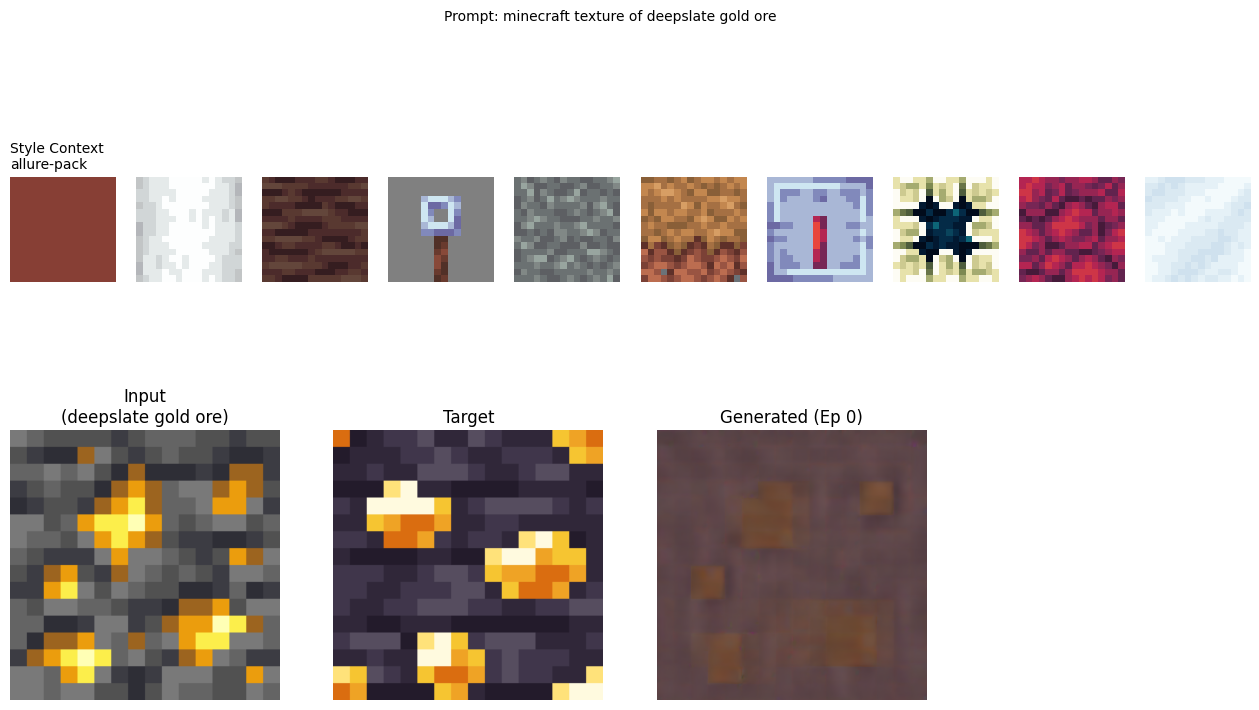

Context Textures: ['brown_concrete', 'stripped_pale_oak_log', 'mangrove_log', 'tripwire_hook', 'pale_moss_carpet', 'dirt_path_side', 'repeater_on', 'sculk_catalyst_bottom', 'netherrack', 'snow']
[step 10050] total=0.1685 L1=0.1659 style=0.0006 λ_style=4.000 (style/L1 ≈ 0.02)
[step 10100] total=0.0434 L1=0.0403 style=0.0008 λ_style=4.000 (style/L1 ≈ 0.08)
[step 10150] total=0.3225 L1=0.3195 style=0.0008 λ_style=4.000 (style/L1 ≈ 0.01)
[step 10200] total=0.0835 L1=0.0799 style=0.0009 λ_style=4.000 (style/L1 ≈ 0.04)
[step 10250] total=0.1528 L1=0.1501 style=0.0007 λ_style=4.000 (style/L1 ≈ 0.02)
[step 10300] total=0.3044 L1=0.3004 style=0.0010 λ_style=4.000 (style/L1 ≈ 0.01)
[step 10350] total=0.1189 L1=0.1169 style=0.0005 λ_style=4.000 (style/L1 ≈ 0.02)
[step 10400] total=0.0387 L1=0.0366 style=0.0005 λ_style=4.000 (style/L1 ≈ 0.06)
[step 10450] total=0.0798 L1=0.0776 style=0.0005 λ_style=4.000 (style/L1 ≈ 0.03)
[step 10500] total=0.1061 L1=0.1035 style=0.0007 λ_style=4.000 (style/L1 ≈ 0

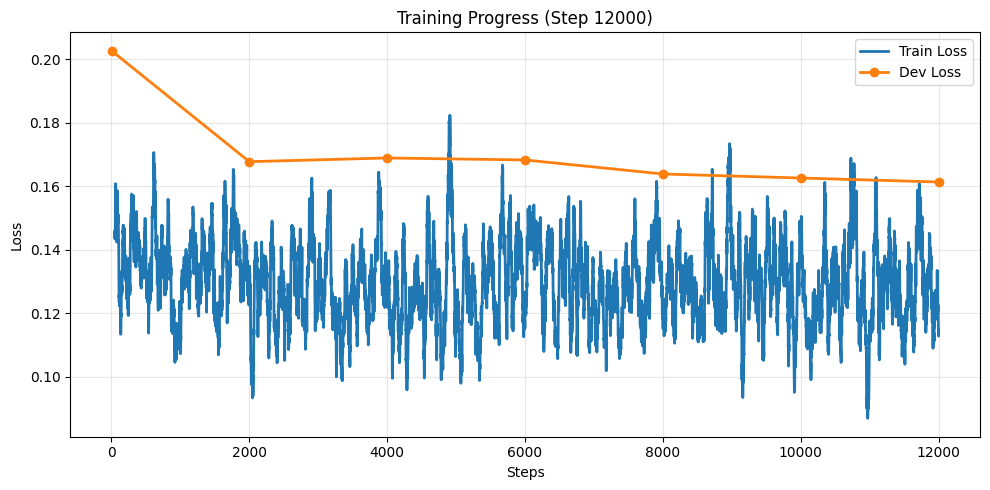


[VAL] Dev set samples:
Generating validation figures for Epoch 0...


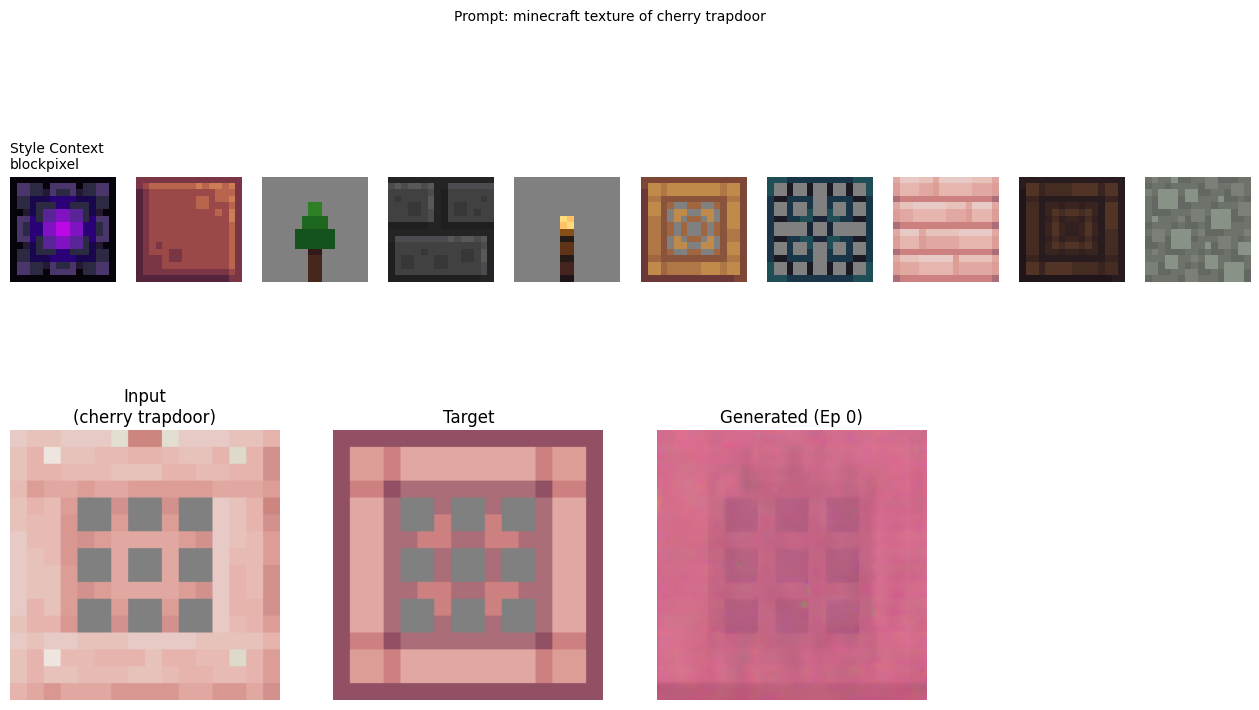

Context Textures: ['respawn_anchor_bottom', 'polished_granite', 'spruce_sapling', 'deepslate_bricks', 'torch', 'oak_trapdoor', 'trial_spawner_bottom', 'cherry_planks', 'dark_oak_trapdoor', 'pale_moss_block']


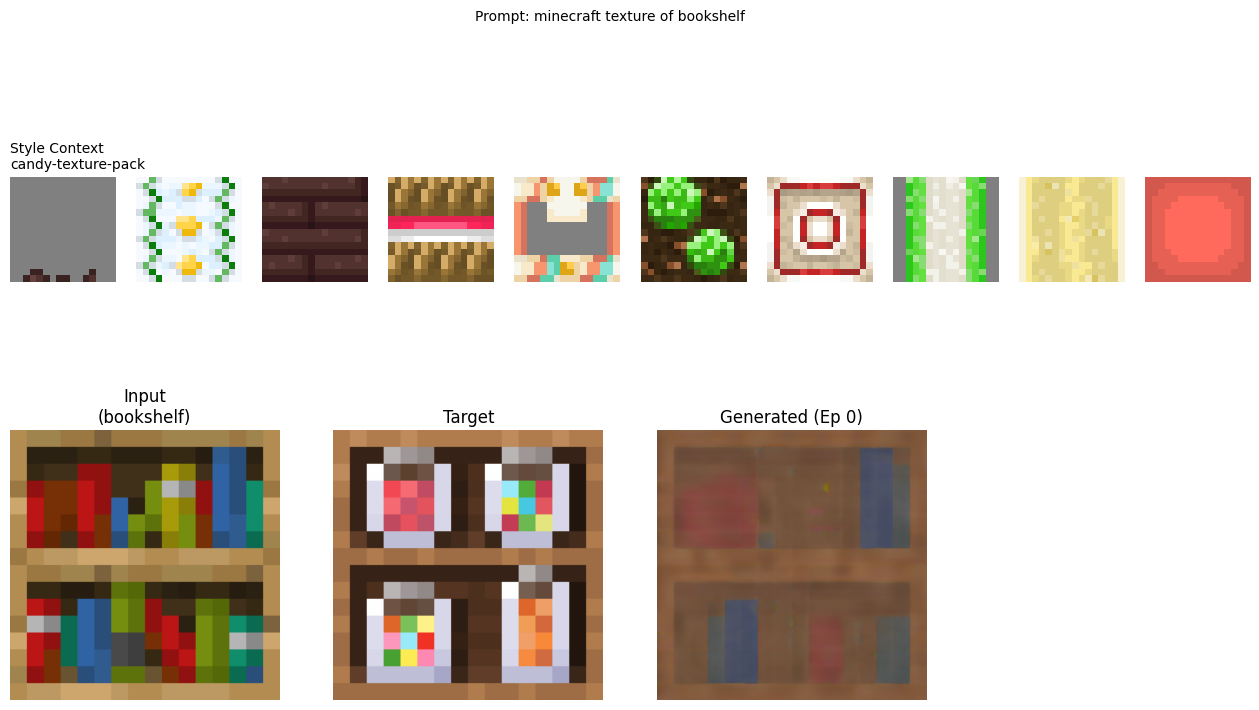

Context Textures: ['beetroots_stage0', 'quartz_pillar', 'spruce_planks', 'lodestone_side', 'vault_front_ejecting', 'emerald_ore', 'target_top', 'activator_rail', 'melon_side', 'shulker_box']

[VAL] Train set samples:
Generating validation figures for Epoch 0...


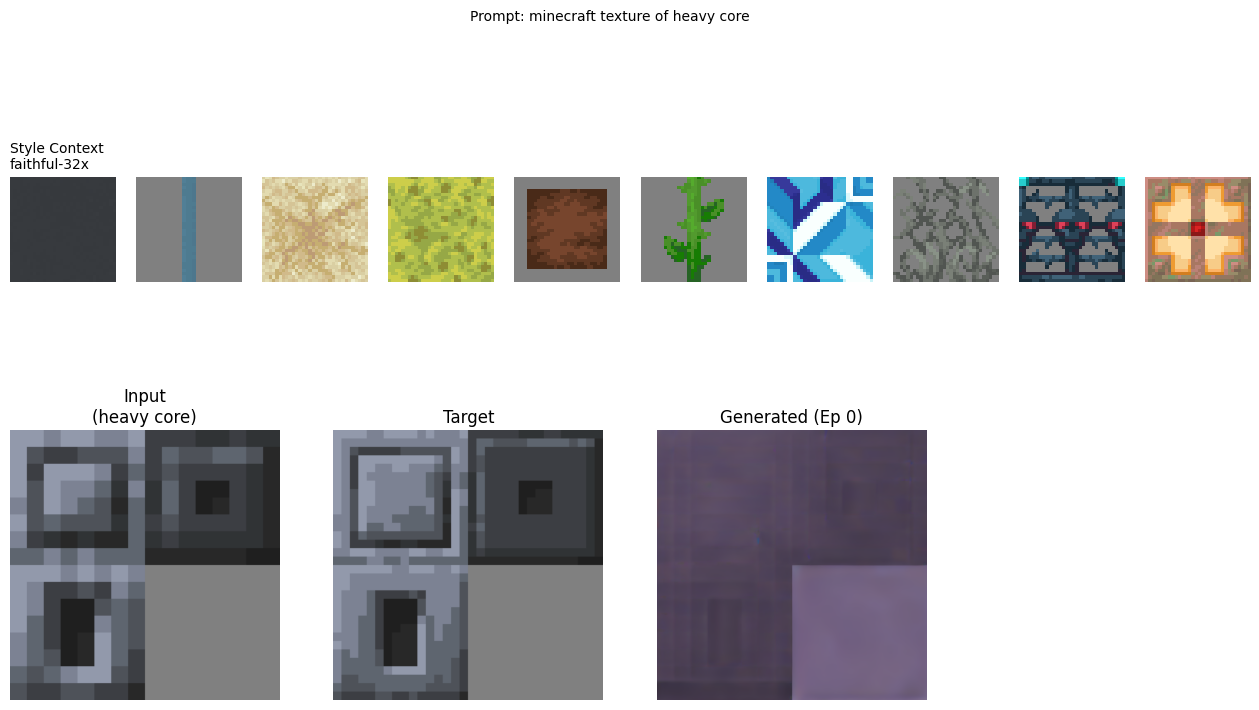

Context Textures: ['gray_concrete', 'cyan_stained_glass_pane_top', 'suspicious_sand_3', 'wet_sponge', 'pitcher_crop_bottom', 'sunflower_bottom', 'light_blue_glazed_terracotta', 'pale_moss_carpet_side_tall', 'trial_spawner_side_active_ominous', 'exposed_copper_bulb_lit_powered']


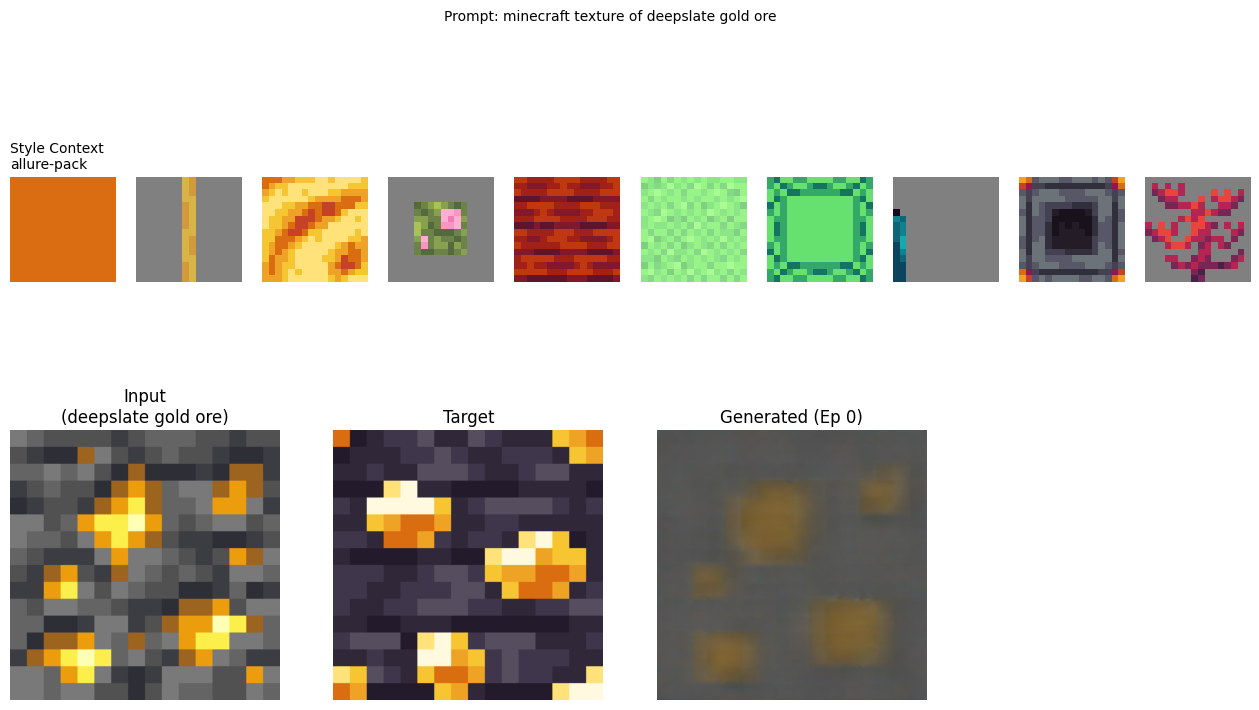

Context Textures: ['orange_concrete', 'yellow_stained_glass_pane_top', 'honey_block_top', 'potted_flowering_azalea_bush_top', 'mangrove_planks', 'lime_concrete_powder', 'lime_shulker_box', 'cyan_candle', 'trial_spawner_top_ejecting_reward', 'fire_coral']
[step 12050] total=0.1398 L1=0.1368 style=0.0008 λ_style=4.000 (style/L1 ≈ 0.02)
[step 12100] total=0.1180 L1=0.1156 style=0.0006 λ_style=4.000 (style/L1 ≈ 0.02)
[step 12150] total=0.3401 L1=0.3368 style=0.0008 λ_style=4.000 (style/L1 ≈ 0.01)
[step 12200] total=0.0117 L1=0.0101 style=0.0004 λ_style=4.000 (style/L1 ≈ 0.15)
[step 12250] total=0.0871 L1=0.0850 style=0.0005 λ_style=4.000 (style/L1 ≈ 0.02)
[step 12300] total=0.1101 L1=0.1064 style=0.0009 λ_style=4.000 (style/L1 ≈ 0.03)
[step 12350] total=0.0612 L1=0.0583 style=0.0007 λ_style=4.000 (style/L1 ≈ 0.05)
[step 12400] total=0.0245 L1=0.0200 style=0.0011 λ_style=4.000 (style/L1 ≈ 0.23)
[step 12450] total=0.0138 L1=0.0110 style=0.0007 λ_style=4.000 (style/L1 ≈ 0.25)
[step 12500] tot

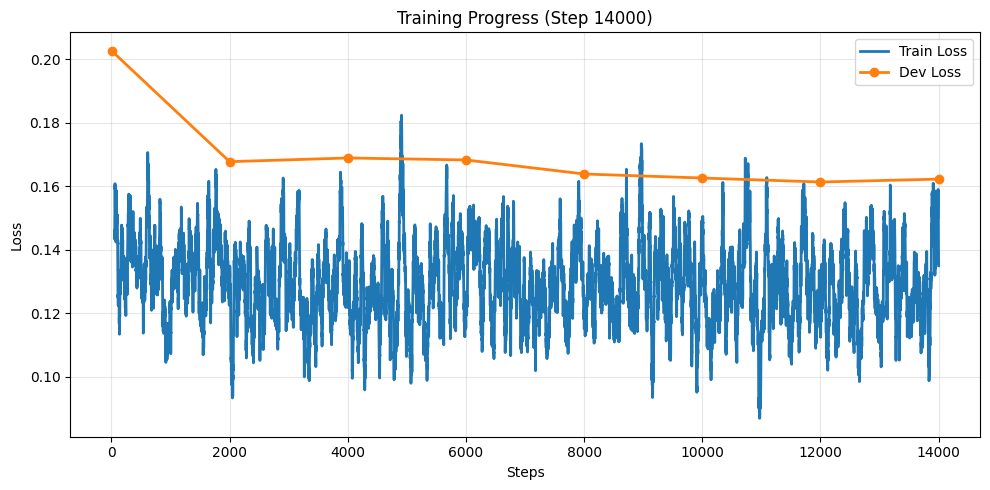


[VAL] Dev set samples:
Generating validation figures for Epoch 0...


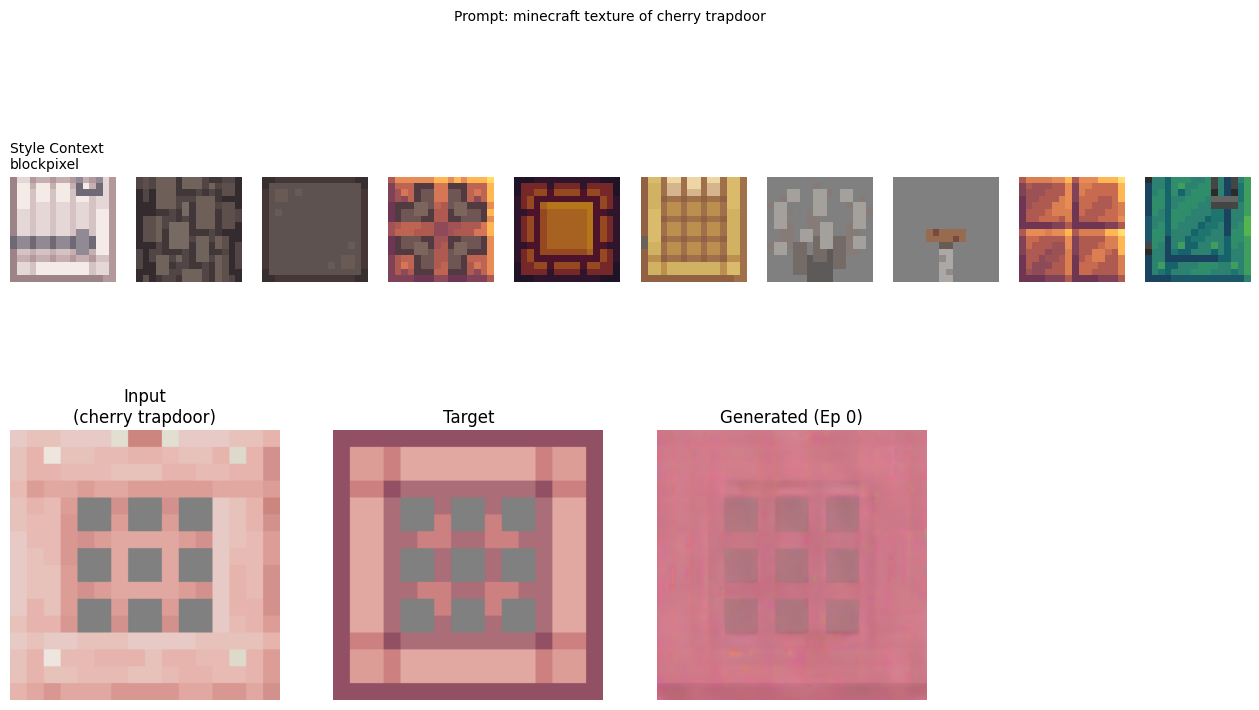

Context Textures: ['pale_oak_door_bottom', 'pale_oak_log', 'brown_stained_glass', 'copper_bulb', 'redstone_lamp', 'birch_door_bottom', 'dead_horn_coral', 'brown_mushroom', 'cut_copper', 'oxidized_copper_door_bottom']


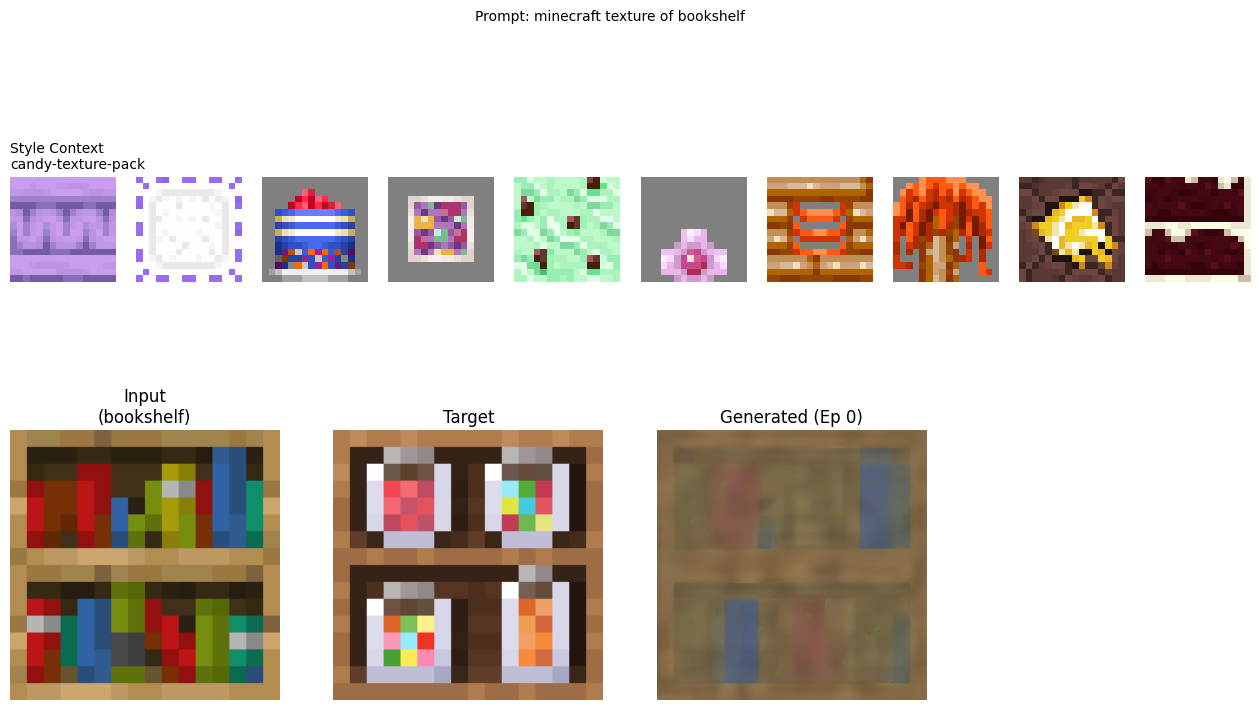

Context Textures: ['chiseled_tuff', 'pearlescent_froglight_top', 'cornflower', 'pitcher_crop_top', 'oak_leaves', 'pitcher_crop_top_stage_3', 'cherry_trapdoor', 'cherry_sapling', 'pumpkin_top', 'cracked_deepslate_bricks']

[VAL] Train set samples:
Generating validation figures for Epoch 0...


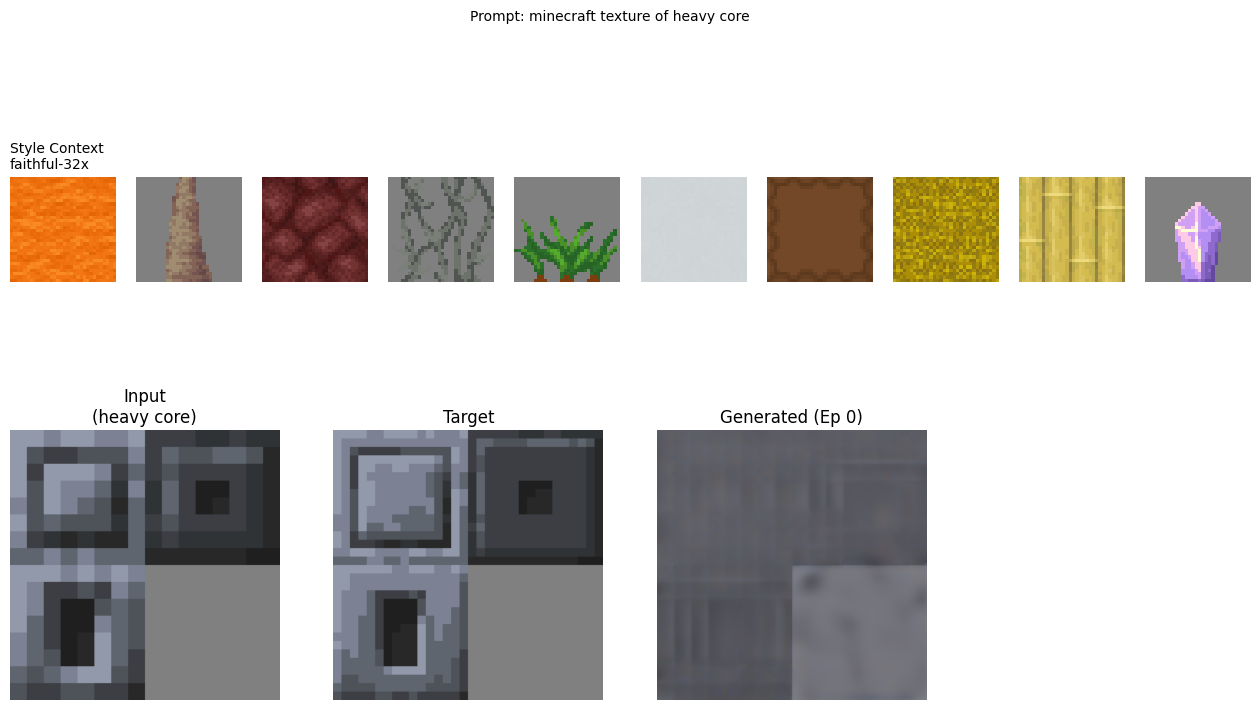

Context Textures: ['orange_wool', 'pointed_dripstone_up_tip_merge', 'netherrack', 'pale_hanging_moss', 'carrots_stage2', 'white_concrete', 'brown_shulker_box', 'hay_block_top', 'stripped_bamboo_block', 'calibrated_sculk_sensor_amethyst']


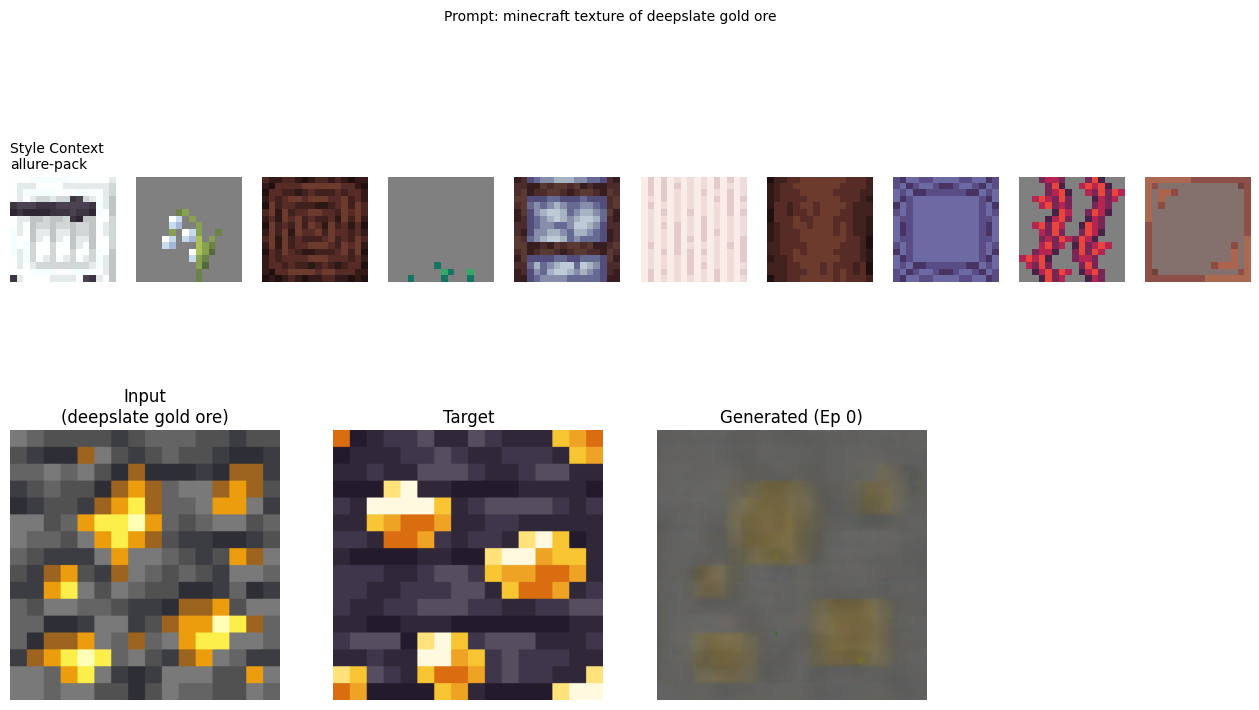

Context Textures: ['pale_oak_door_top', 'lily_of_the_valley', 'dark_oak_log_top', 'wheat_stage0', 'smoker_side', 'quartz_pillar', 'stripped_dark_oak_log', 'gray_shulker_box', 'weeping_vines_plant', 'brown_stained_glass']
[step 14050] total=0.0609 L1=0.0590 style=0.0005 λ_style=4.000 (style/L1 ≈ 0.03)
[step 14100] total=0.0533 L1=0.0512 style=0.0005 λ_style=4.000 (style/L1 ≈ 0.04)
[step 14150] total=0.2245 L1=0.2205 style=0.0010 λ_style=4.000 (style/L1 ≈ 0.02)
[step 14200] total=0.1299 L1=0.1269 style=0.0008 λ_style=4.000 (style/L1 ≈ 0.02)
[step 14250] total=0.1080 L1=0.1053 style=0.0007 λ_style=4.000 (style/L1 ≈ 0.03)
[step 14300] total=0.0461 L1=0.0436 style=0.0006 λ_style=4.000 (style/L1 ≈ 0.06)
[step 14350] total=0.1033 L1=0.1007 style=0.0006 λ_style=4.000 (style/L1 ≈ 0.03)
[step 14400] total=0.1761 L1=0.1740 style=0.0005 λ_style=4.000 (style/L1 ≈ 0.01)
[step 14450] total=0.3360 L1=0.3321 style=0.0010 λ_style=4.000 (style/L1 ≈ 0.01)
[step 14500] total=0.1472 L1=0.1442 style=0.0008 λ

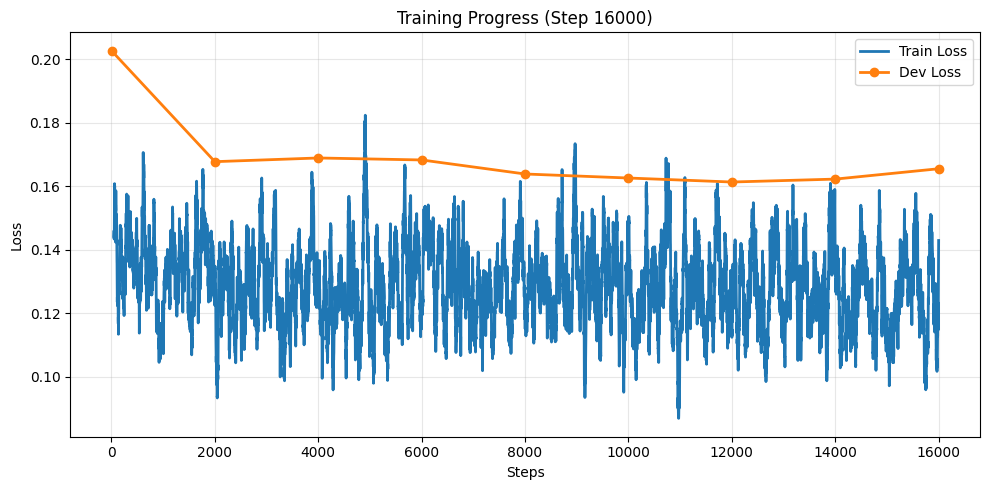


[VAL] Dev set samples:
Generating validation figures for Epoch 0...


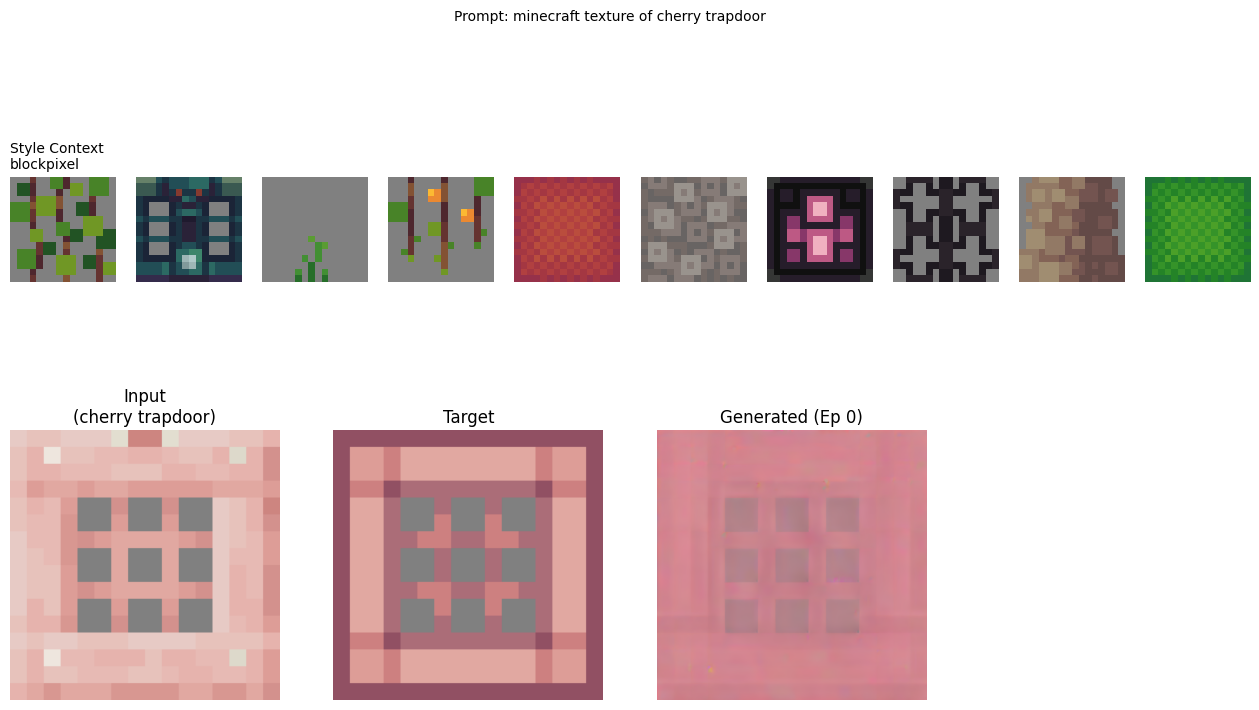

Context Textures: ['cave_vines_plant', 'vault_front_off', 'potatoes_stage1', 'cave_vines', 'red_wool', 'dead_fire_coral_block', 'jigsaw_side', 'iron_bars', 'pointed_dripstone_up_base', 'green_wool']


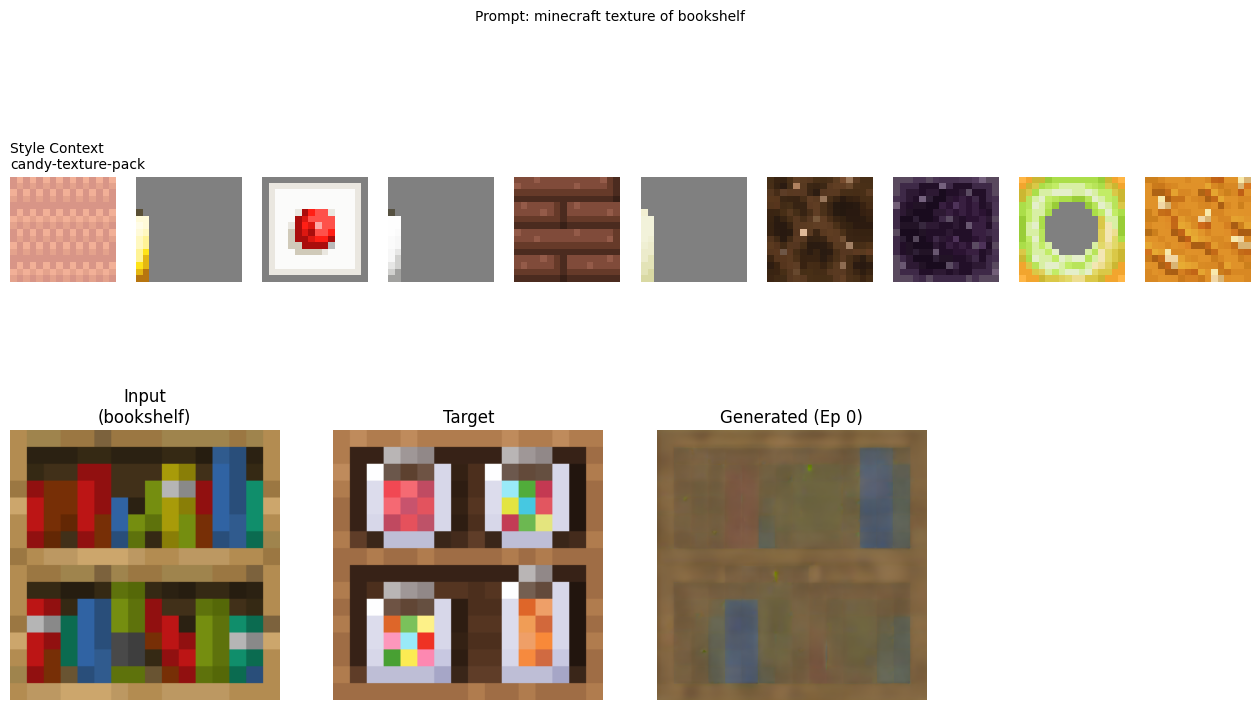

Context Textures: ['pink_stained_glass_pane_top', 'yellow_candle_lit', 'cake_top', 'white_candle_lit', 'jungle_planks', 'candle', 'soul_sand', 'enchanting_table_bottom', 'weathered_copper_trapdoor', 'orange_terracotta']

[VAL] Train set samples:
Generating validation figures for Epoch 0...


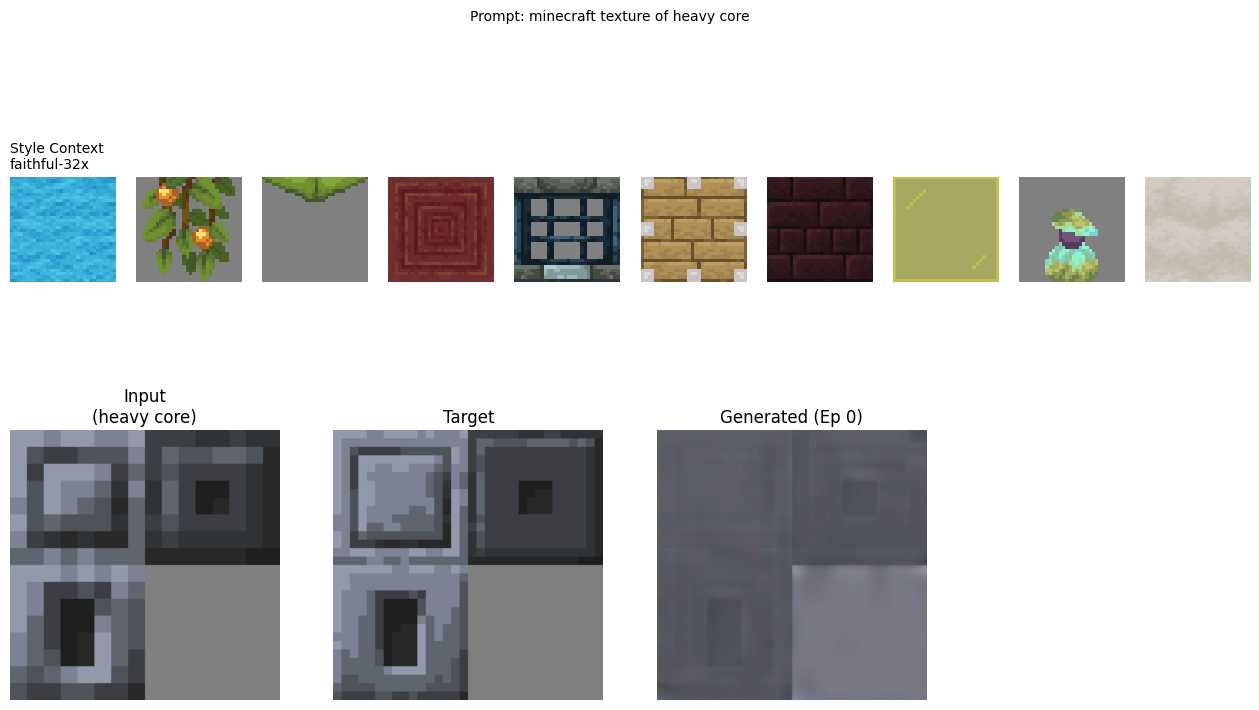

Context Textures: ['light_blue_wool', 'cave_vines_lit', 'big_dripleaf_tip', 'stripped_mangrove_log_top', 'vault_side_off', 'piston_top', 'nether_bricks', 'yellow_stained_glass', 'pitcher_crop_top_stage_3', 'mushroom_stem']


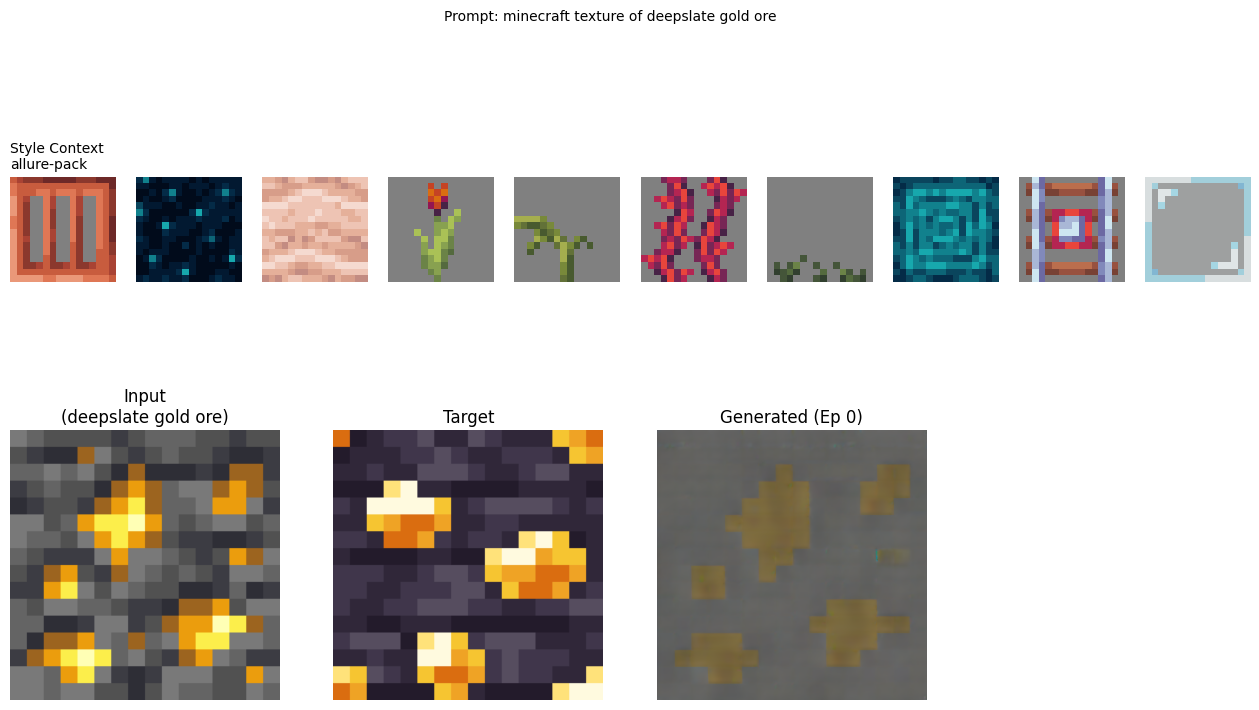

Context Textures: ['acacia_trapdoor', 'sculk_catalyst_top', 'white_terracotta', 'orange_tulip', 'attached_melon_stem', 'weeping_vines_plant', 'potatoes_stage0', 'warped_stem_top', 'detector_rail_on', 'white_stained_glass']
[step 16050] total=0.1311 L1=0.1282 style=0.0007 λ_style=4.000 (style/L1 ≈ 0.02)
[step 16100] total=0.0519 L1=0.0497 style=0.0006 λ_style=4.000 (style/L1 ≈ 0.05)
[step 16150] total=0.1906 L1=0.1880 style=0.0007 λ_style=4.000 (style/L1 ≈ 0.01)
[step 16200] total=0.0938 L1=0.0916 style=0.0006 λ_style=4.000 (style/L1 ≈ 0.02)
[step 16250] total=0.0866 L1=0.0824 style=0.0010 λ_style=4.000 (style/L1 ≈ 0.05)
[step 16300] total=0.1986 L1=0.1956 style=0.0007 λ_style=4.000 (style/L1 ≈ 0.02)
[step 16350] total=0.3606 L1=0.3576 style=0.0008 λ_style=4.000 (style/L1 ≈ 0.01)
[step 16400] total=0.1037 L1=0.1000 style=0.0009 λ_style=4.000 (style/L1 ≈ 0.04)
[step 16450] total=0.0424 L1=0.0403 style=0.0005 λ_style=4.000 (style/L1 ≈ 0.05)
[step 16500] total=0.1851 L1=0.1819 style=0.0008

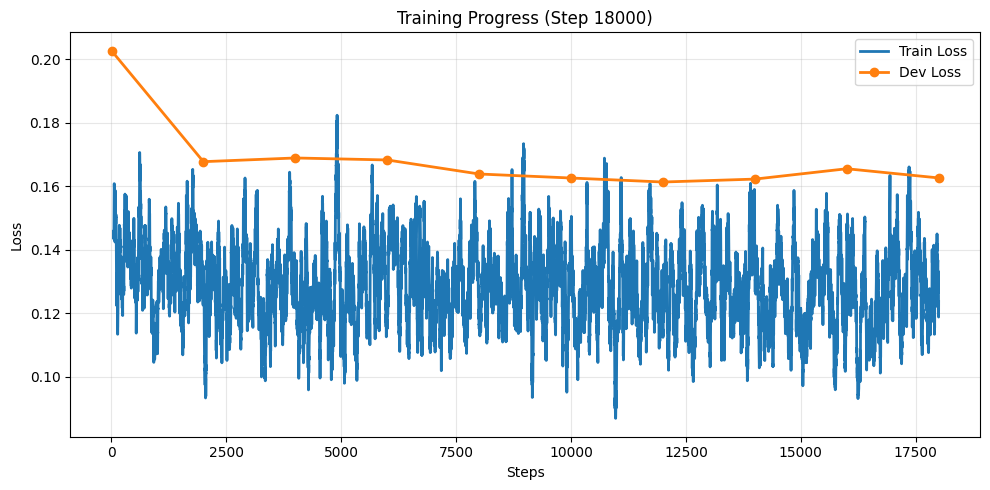


[VAL] Dev set samples:
Generating validation figures for Epoch 0...


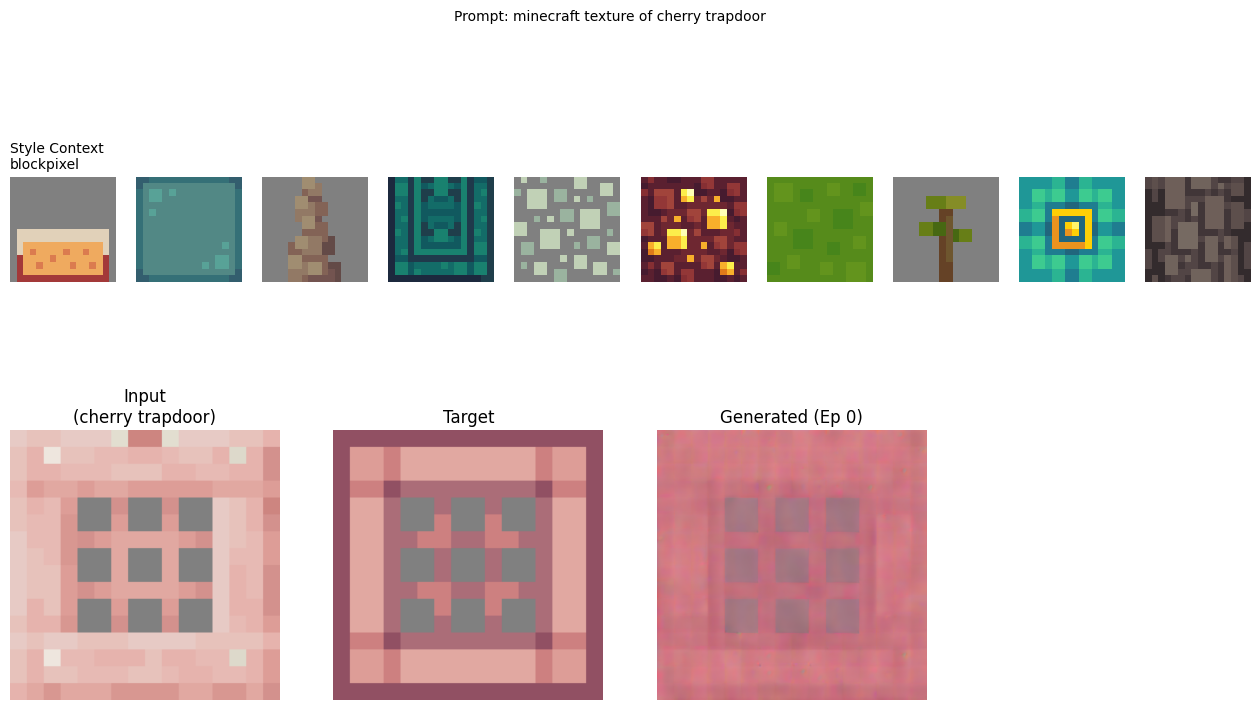

Context Textures: ['cake_inner', 'cyan_stained_glass', 'pointed_dripstone_up_tip_merge', 'warped_door_bottom', 'oak_leaves', 'nether_gold_ore', 'lime_concrete', 'acacia_sapling', 'cyan_shulker_box', 'pale_oak_log']


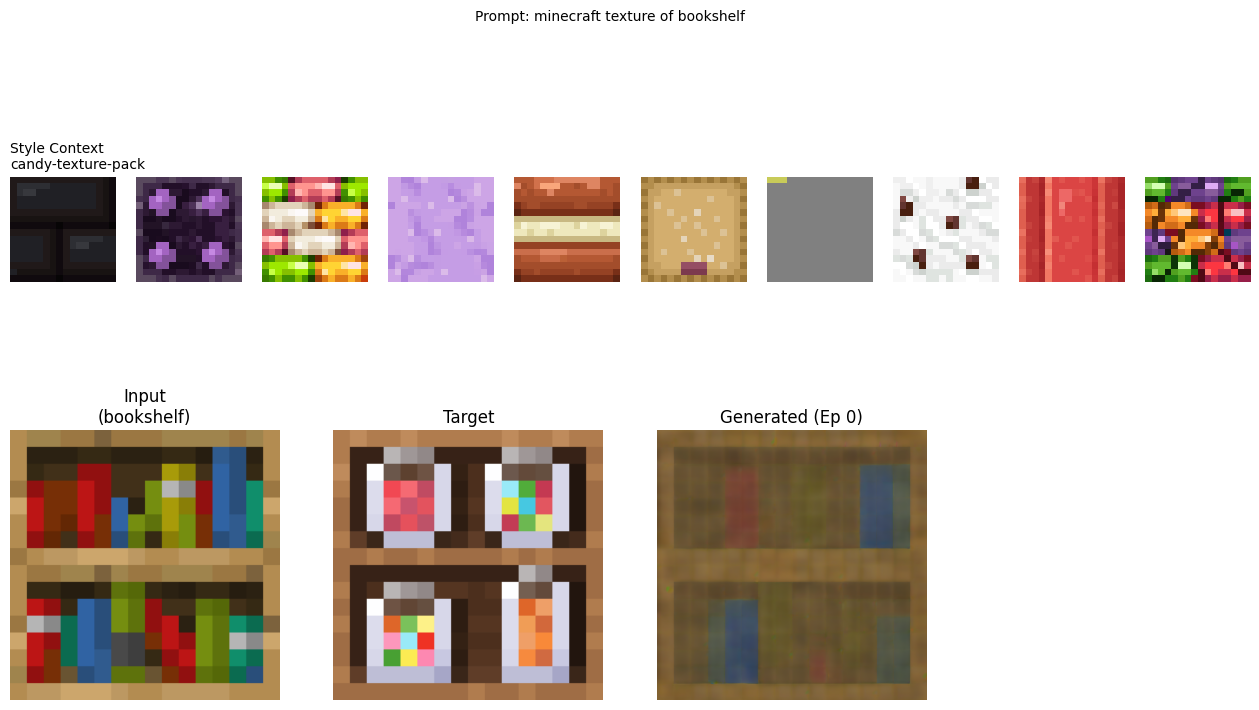

Context Textures: ['polished_blackstone_bricks', 'respawn_anchor_bottom', 'red_nether_bricks', 'mycelium_top', 'red_sandstone', 'jungle_trapdoor', 'big_dripleaf_side', 'mangrove_leaves', 'purpur_pillar', 'cracked_nether_bricks']

[VAL] Train set samples:
Generating validation figures for Epoch 0...


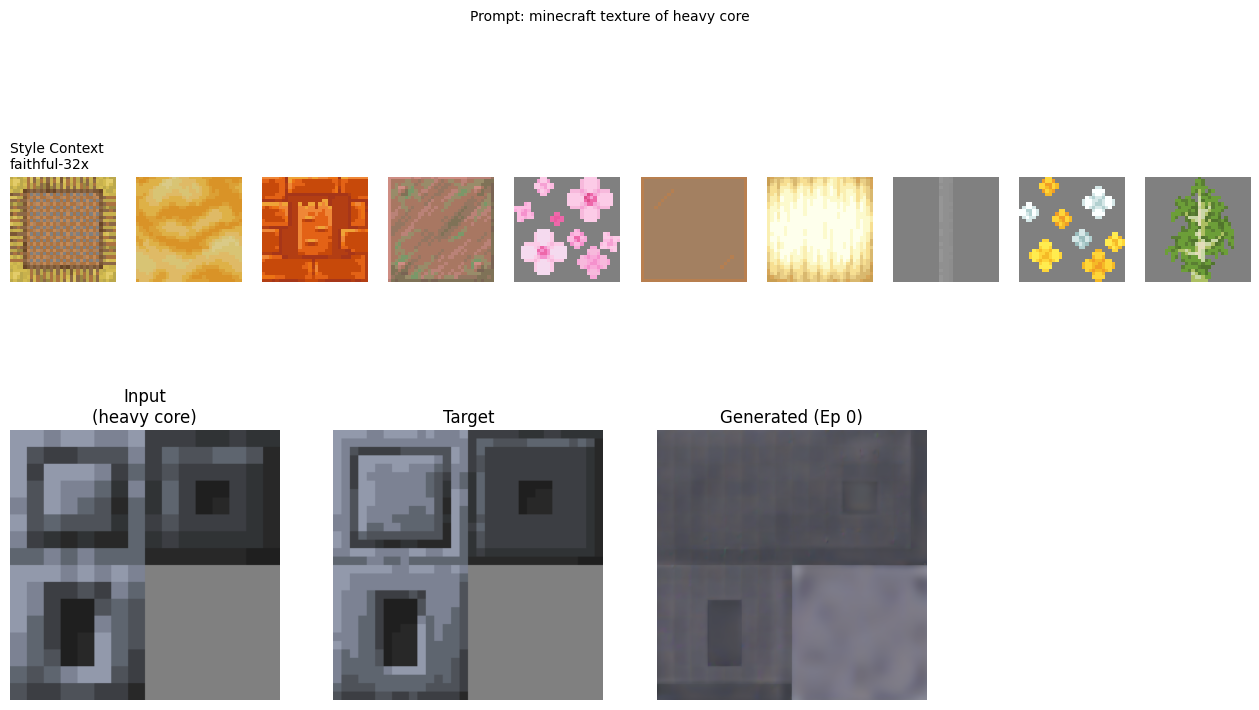

Context Textures: ['scaffolding_top', 'honey_block_side', 'chiseled_resin_bricks', 'exposed_copper', 'pink_petals', 'orange_stained_glass', 'ochre_froglight_side', 'light_gray_stained_glass_pane_top', 'wildflowers', 'birch_sapling']


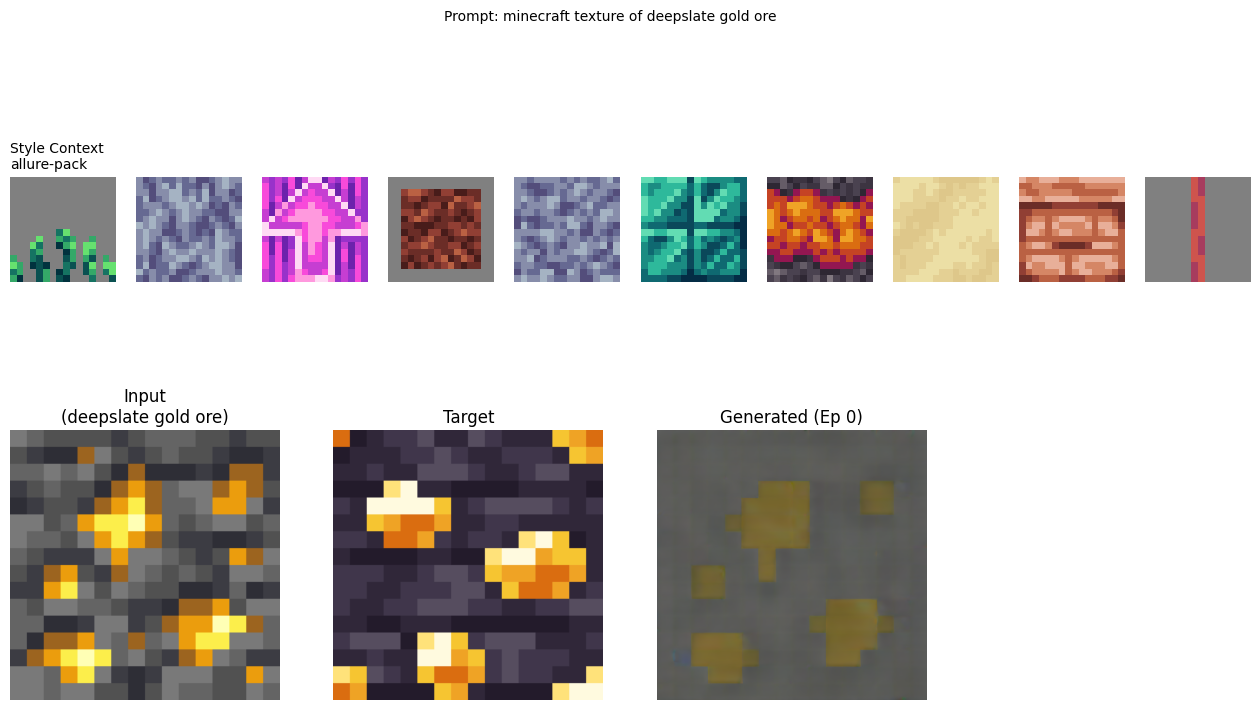

Context Textures: ['wheat_stage3', 'dead_fire_coral_block', 'magenta_glazed_terracotta', 'composter_compost', 'gravel', 'oxidized_cut_copper', 'creaking_heart_awake', 'sandstone_top', 'beehive_front', 'red_stained_glass_pane_top']
[step 18050] total=0.0370 L1=0.0346 style=0.0006 λ_style=4.000 (style/L1 ≈ 0.07)
[step 18100] total=0.0581 L1=0.0565 style=0.0004 λ_style=4.000 (style/L1 ≈ 0.03)
[step 18150] total=0.0215 L1=0.0194 style=0.0005 λ_style=4.000 (style/L1 ≈ 0.11)
[step 18200] total=0.0636 L1=0.0618 style=0.0004 λ_style=4.000 (style/L1 ≈ 0.03)
[step 18250] total=0.2542 L1=0.2504 style=0.0009 λ_style=4.000 (style/L1 ≈ 0.02)
[step 18300] total=0.0958 L1=0.0932 style=0.0006 λ_style=4.000 (style/L1 ≈ 0.03)
[step 18350] total=0.0780 L1=0.0734 style=0.0011 λ_style=4.000 (style/L1 ≈ 0.06)
[step 18400] total=0.1295 L1=0.1263 style=0.0008 λ_style=4.000 (style/L1 ≈ 0.03)
[step 18450] total=0.0340 L1=0.0320 style=0.0005 λ_style=4.000 (style/L1 ≈ 0.06)
[step 18500] total=0.1780 L1=0.1740 styl

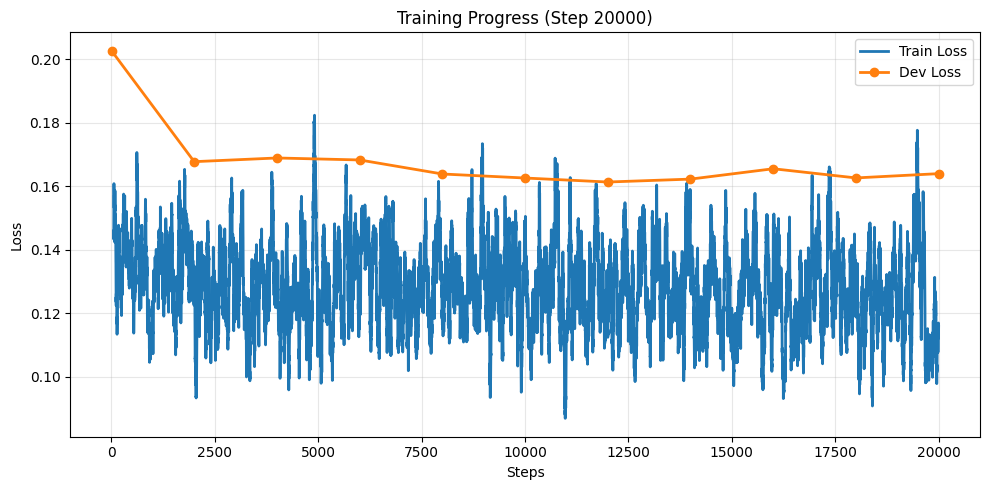


[VAL] Dev set samples:
Generating validation figures for Epoch 0...


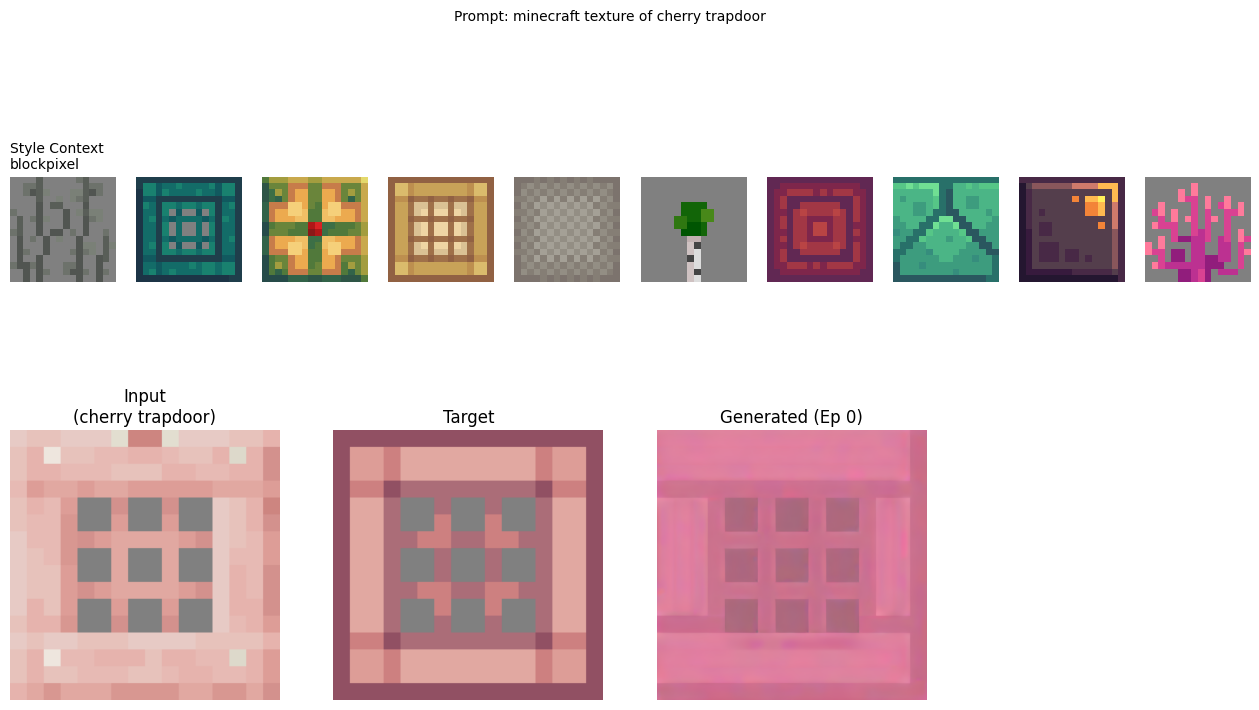

Context Textures: ['pale_moss_carpet_side_tall', 'warped_trapdoor', 'weathered_copper_bulb_lit_powered', 'birch_trapdoor', 'light_gray_wool', 'birch_sapling', 'stripped_crimson_stem_top', 'prismarine_bricks', 'netherite_block', 'brain_coral']


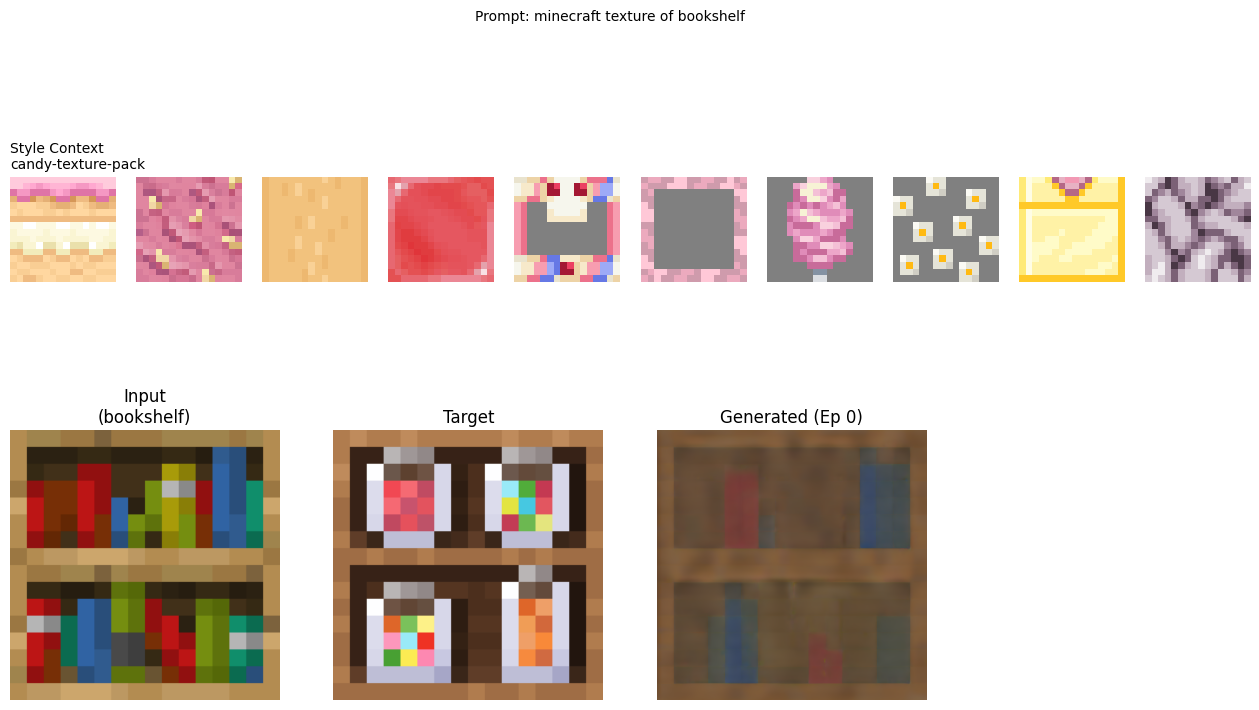

Context Textures: ['grass_block_side', 'magenta_terracotta', 'stripped_birch_log', 'dark_prismarine', 'vault_front_ejecting_ominous', 'scaffolding_bottom', 'fern', 'frogspawn', 'crafter_south_triggered', 'dead_horn_coral_block']

[VAL] Train set samples:
Generating validation figures for Epoch 0...


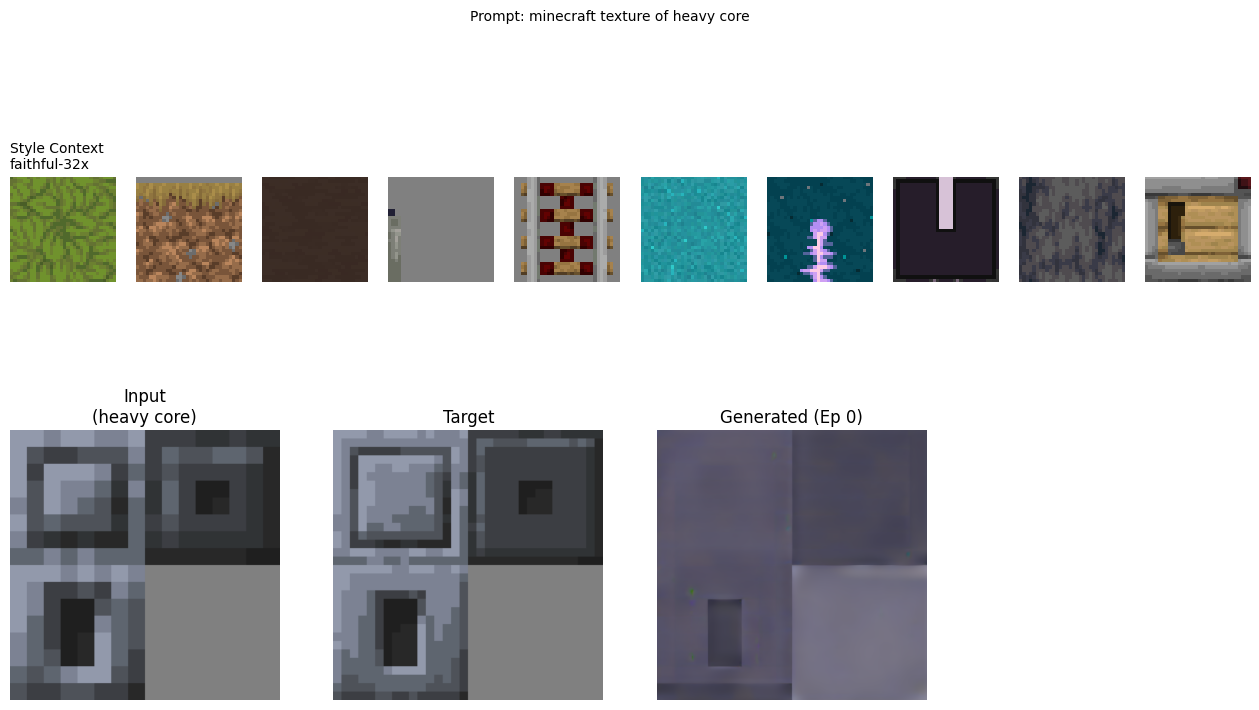

Context Textures: ['azalea_top', 'dirt_path_side', 'gray_terracotta', 'light_gray_candle', 'activator_rail', 'cyan_concrete_powder', 'calibrated_sculk_sensor_top', 'jigsaw_lock', 'basalt_side', 'crafter_west']


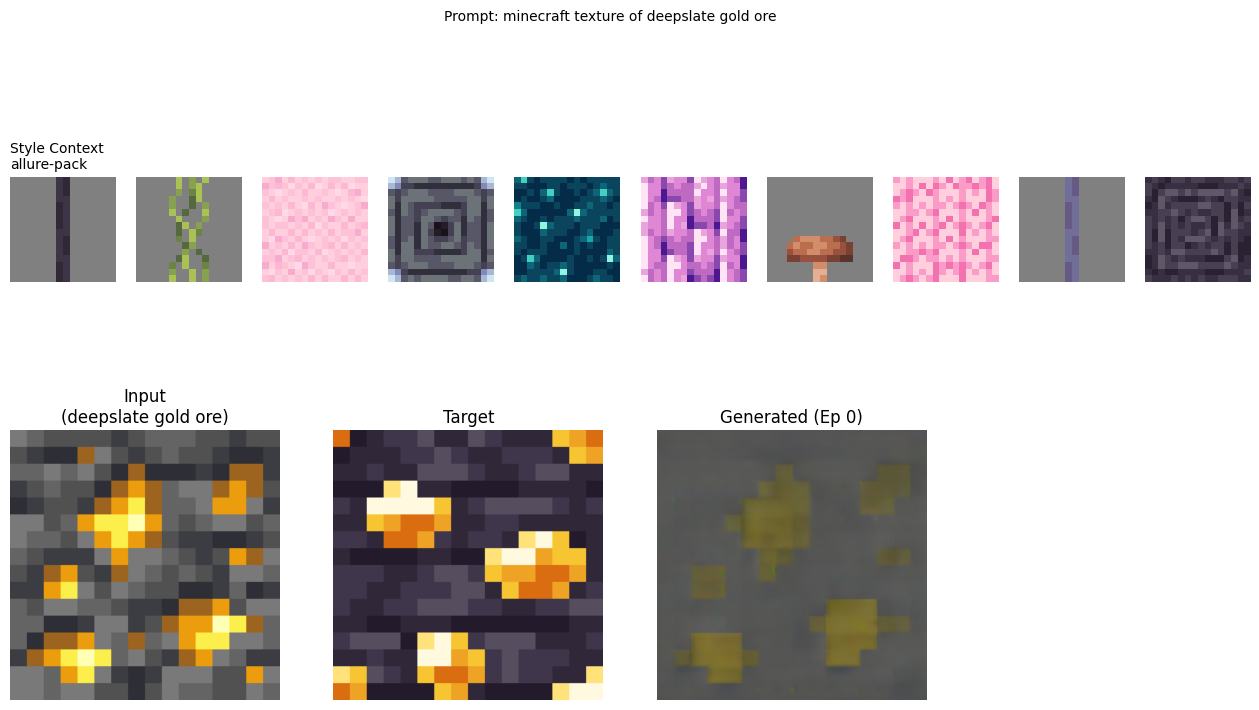

Context Textures: ['black_stained_glass_pane_top', 'small_dripleaf_stem_bottom', 'pink_concrete_powder', 'trial_spawner_top_inactive', 'sculk_sensor_top', 'purpur_pillar', 'brown_mushroom', 'pink_wool', 'gray_stained_glass_pane_top', 'polished_basalt_top']
[step 20050] total=0.0852 L1=0.0825 style=0.0007 λ_style=4.000 (style/L1 ≈ 0.03)
[step 20100] total=0.0903 L1=0.0878 style=0.0006 λ_style=4.000 (style/L1 ≈ 0.03)
[step 20150] total=0.0162 L1=0.0139 style=0.0006 λ_style=4.000 (style/L1 ≈ 0.16)
[step 20200] total=0.2973 L1=0.2941 style=0.0008 λ_style=4.000 (style/L1 ≈ 0.01)
[step 20250] total=0.0365 L1=0.0348 style=0.0004 λ_style=4.000 (style/L1 ≈ 0.05)
[step 20300] total=0.1001 L1=0.0972 style=0.0007 λ_style=4.000 (style/L1 ≈ 0.03)
[step 20350] total=0.1007 L1=0.0987 style=0.0005 λ_style=4.000 (style/L1 ≈ 0.02)
[step 20400] total=0.2279 L1=0.2252 style=0.0007 λ_style=4.000 (style/L1 ≈ 0.01)
[step 20450] total=0.0641 L1=0.0619 style=0.0006 λ_style=4.000 (style/L1 ≈ 0.04)
[step 20500] t

In [18]:
from diffusers import DDPMScheduler
from tqdm.auto import tqdm
import numpy as np
from torch.utils.data import DataLoader, Subset
from collections import deque

BATCH_SIZE = 1
DEV_BATCH_SIZE = 2
LEARNING_RATE = 3e-5
LAMBDA_STYLE = 4
GRAD_ACCUM_STEPS = 8
NUM_EPOCHS = 1
VALIDATION_INTERVAL = 2000
SAVE_INTERVAL = 1  # still save once per epoch (cheap)

# new: step-based checkpointing config
CHECKPOINT_INTERVAL_STEPS = 2000   # save every 2000 steps
MAX_CHECKPOINTS = 2                # keep only the most recent 2 step-checkpoints

# --- DataLoaders ---
def make_balanced_dev_subset(dataset, n_per_pack=3, seed=42):
    """
    Pick n_per_pack random indices from each pack_id in the dev dataset,
    and keep them fixed for the entire run.
    Assumes each dataset item has a 'pack_id' field, which can be a string
    like 'ashen' / 'plastic' or a tensor.
    """
    pack_to_indices = {}

    # Group indices by pack_id
    for idx in range(len(dataset)):
        item = dataset[idx]
        pack_id = item["pack_id"]

        # If pack_id is a tensor, convert to Python type
        if isinstance(pack_id, torch.Tensor):
            pack_id = pack_id.item()

        pack_to_indices.setdefault(pack_id, []).append(idx)

    rng = np.random.RandomState(seed)
    selected_indices = []

    for pack_id, indices in pack_to_indices.items():
        if len(indices) < n_per_pack:
            raise ValueError(
                f"Not enough examples in pack {pack_id}: "
                f"needed {n_per_pack}, found {len(indices)}"
            )

        chosen = rng.choice(indices, size=n_per_pack, replace=False)
        selected_indices.extend(chosen.tolist())

    expected = len(pack_to_indices) * n_per_pack
    if len(selected_indices) != expected:
        print(f"[WARN] Expected {expected} dev examples, got {len(selected_indices)}")

    return selected_indices


# --- DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# build a fixed, balanced dev subset
dev_eval_indices = make_balanced_dev_subset(dev_dataset, n_per_pack=1, seed=67)
dev_eval_dataset = Subset(dev_dataset, dev_eval_indices)

# this loader now always yields those same dev examples
dev_loader = DataLoader(dev_eval_dataset, batch_size=DEV_BATCH_SIZE, shuffle=False, num_workers=2)

# --- Small fixed train subset for visualization ---
# we just pick a few random train examples once and reuse them every validation
rng = np.random.RandomState(123)
n_train_vis = min(DEV_BATCH_SIZE, len(train_dataset))
train_eval_indices = rng.choice(len(train_dataset), size=n_train_vis, replace=False)
train_eval_dataset = Subset(train_dataset, train_eval_indices)
train_eval_loader = DataLoader(
    train_eval_dataset,
    batch_size=n_train_vis,
    shuffle=False,
    num_workers=2,
)


# --- Helper Functions  ---
def compute_time_ids(batch_size, device):
    time_ids = torch.tensor([[1024, 1024, 0, 0, 1024, 1024]], device=device)
    return time_ids.repeat(batch_size, 1)

def encode_prompts(pipe, prompt_batch, device):
    with torch.no_grad():
        tokens_1 = pipe.tokenizer(
            prompt_batch,
            padding="max_length",
            max_length=77,
            truncation=True,
            return_tensors="pt",
        ).input_ids.to(device)
        tokens_2 = pipe.tokenizer_2(
            prompt_batch,
            padding="max_length",
            max_length=77,
            truncation=True,
            return_tensors="pt",
        ).input_ids.to(device)

        prompt_embeds_1 = pipe.text_encoder(tokens_1)[0]
        te2_out = pipe.text_encoder_2(tokens_2, output_hidden_states=True)
        prompt_embeds_2 = te2_out.hidden_states[-2]
        pooled_embeds = te2_out.text_embeds

        prompt_embeds = torch.cat([prompt_embeds_1, prompt_embeds_2], dim=-1)
    return prompt_embeds, pooled_embeds

def debug_check_tensor(name, t, step):
    if not torch.is_tensor(t):
        return
    if not torch.isfinite(t).all():
        print(f"\n[DEBUG] {name} has non-finite values at step {step}")
        print(
            f"        dtype={t.dtype}, "
            f"min={t.min().item() if torch.isfinite(t).any() else 'NaN/Inf-only'}, "
            f"max={t.max().item() if torch.isfinite(t).any() else 'NaN/Inf-only'}"
        )
        raise RuntimeError(f"Non-finite values in {name} at step {step}")

def update_dashboard(train_losses, dev_losses, step_count):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 5))
    plt.title(f"Training Progress (Step {step_count})")

    if len(train_losses) > 0:
        window = 50
        steps = np.arange(1, len(train_losses) + 1)

        if len(train_losses) >= window:
            smoothed = np.convolve(train_losses, np.ones(window) / window, mode="valid")
            steps_sm = steps[window - 1:]
        else:
            smoothed = train_losses
            steps_sm = steps

        plt.plot(steps_sm, smoothed, label="Train Loss", linewidth=2)

    if len(dev_losses) > 0:
        dev_x, dev_y = zip(*dev_losses)
        plt.plot(dev_x, dev_y, "o-", label="Dev Loss", linewidth=2)

    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close("all")


# training loop
def train_loop(pipe, ip_model, optimizer, train_loader, dev_loader, epochs, model, lambda_style, grad_accum_steps):
    noise_scheduler = DDPMScheduler.from_config(pipe.scheduler.config)
    loss_fn = MinecraftTextureLoss(
        model,
        pipe.vae,
        noise_scheduler,
        lambda_style=lambda_style,
    ).to(device)

    # --- Match training noise to zero-shot img2img call ---
    # In log_validation, you use: strength=0.65, num_inference_steps=30
    TRAIN_STRENGTH = 0.45
    TRAIN_NUM_STEPS = 30

    # This mimics SDXL img2img internal timestep choice
    noise_scheduler.set_timesteps(TRAIN_NUM_STEPS)
    idx = int(TRAIN_STRENGTH * TRAIN_NUM_STEPS)
    idx = min(idx, TRAIN_NUM_STEPS - 1)
    img2img_timestep = noise_scheduler.timesteps[idx].item()
    # -----------------------------------------------------

    step_count = 0
    train_loss_history = []
    dev_loss_history = []

    # track saved checkpoints with a rotating buffer
    saved_checkpoints = deque(maxlen=MAX_CHECKPOINTS)

    if hasattr(ip_model, "image_encoder") and ip_model.image_encoder is not None:
        del ip_model.image_encoder
        torch.cuda.empty_cache()

    total_steps = len(train_loader) * epochs
    print(f"Starting Training | Batch Size: {BATCH_SIZE} | Total Steps: {total_steps}")

    ip_dtype = next(ip_model.image_proj_model.parameters()).dtype

    scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer,
        start_factor=1.0,
        end_factor=0.1,
        total_iters=epochs,
    )

    with tqdm(total=total_steps, desc="Training", unit="step", leave=True) as pbar:
        for epoch in range(epochs):
            ip_model.image_proj_model.train()
            pipe.unet.train()

            optimizer.zero_grad(set_to_none=True)

            for batch_idx, batch in enumerate(train_loader):
                step_count += 1
                pbar.update(1)

                # 1. Inputs
                default_images = batch["default_image"].to(device, dtype=torch.float32)
                target_images  = batch["target_image"].to(device, dtype=torch.float32)
                target_clip_vecs = batch["target_clip_embedding"].to(device, dtype=torch.float32)
                style_embeds = batch["style_embedding"].to(device, dtype=ip_dtype)
                prompts = [n.replace("_", " ") for n in batch["texture_name"]]

                debug_check_tensor("target_images", target_images, step_count)
                debug_check_tensor("target_clip_vecs", target_clip_vecs, step_count)
                debug_check_tensor("style_embeds", style_embeds, step_count)

                # 2. Text & style
                prompt_embeds, pooled_embeds = encode_prompts(pipe, prompts, device)
                ip_tokens = ip_model.image_proj_model(style_embeds.unsqueeze(1))

                debug_check_tensor("prompt_embeds", prompt_embeds, step_count)
                debug_check_tensor("pooled_embeds", pooled_embeds, step_count)
                debug_check_tensor("ip_tokens", ip_tokens, step_count)

                # 3. Latents & noise
                bsz = target_images.shape[0]
                time_ids = compute_time_ids(bsz, device).float()

                # Use the SAME img2img-style timestep for all examples in the batch
                timesteps = torch.full(
                    (bsz,),
                    img2img_timestep,
                    device=device,
                    dtype=torch.long,
                )

                with torch.no_grad():
                    # Encode the *default* texture to get the structural prior latents
                    vae_in = default_images.to(dtype=pipe.vae.dtype)
                    enc_out = pipe.vae.encode(vae_in)
                    latent_dist = enc_out.latent_dist

                    debug_check_tensor("latent_mean", latent_dist.mean, step_count)
                    if hasattr(latent_dist, "variance"):
                        debug_check_tensor("latent_var", latent_dist.variance, step_count)
                    elif hasattr(latent_dist, "std"):
                        debug_check_tensor("latent_std", latent_dist.std, step_count)

                    default_latents = latent_dist.mean * pipe.vae.config.scaling_factor
                    debug_check_tensor("default_latents", default_latents, step_count)

                    noise = torch.randn_like(default_latents)
                    noisy_latents = noise_scheduler.add_noise(default_latents, noise, timesteps)

                debug_check_tensor("noise", noise, step_count)
                debug_check_tensor("noisy_latents", noisy_latents, step_count)

                # 4. UNet forward
                noise_pred = pipe.unet(
                    noisy_latents,
                    timesteps,
                    encoder_hidden_states=prompt_embeds,
                    added_cond_kwargs={"text_embeds": pooled_embeds, "time_ids": time_ids},
                    cross_attention_kwargs={"ip_adapter_embeds": ip_tokens},
                ).sample

                debug_check_tensor("noise_pred", noise_pred, step_count)

                # 5. Loss
                loss_val, l1, style = loss_fn(
                    noise_pred, timesteps, noisy_latents,
                    target_images, target_clip_vecs
                )

                if not torch.isfinite(loss_val):
                    print(
                        f"\n[WARN] Non-finite loss at step {step_count} "
                        f"(epoch {epoch}): total={loss_val.item()}, "
                        f"L1={l1.item()}, style={style.item()}"
                    )
                    optimizer.zero_grad(set_to_none=True)
                    pbar.set_postfix({"loss": "NaN", "epoch": epoch})
                    continue

                loss = loss_val / grad_accum_steps
                loss.backward()

                do_step = ((batch_idx + 1) % grad_accum_steps == 0) or ((batch_idx + 1) == len(train_loader))
                if do_step:
                    torch.nn.utils.clip_grad_norm_(
                        ip_model.image_proj_model.parameters(),
                        max_norm=1.0,
                    )
                    optimizer.step()
                    optimizer.zero_grad(set_to_none=True)

                    # step-based checkpointing with rotation
                    if step_count % CHECKPOINT_INTERVAL_STEPS == 0:
                        ckpt_path = f"ip_adapter_step_{step_count}.pt"
                        torch.save(
                            ip_model.image_proj_model.state_dict(),
                            ckpt_path,
                        )

                        # if buffer is full, delete the oldest file
                        if len(saved_checkpoints) == saved_checkpoints.maxlen:
                            oldest = saved_checkpoints.popleft()
                            if os.path.exists(oldest):
                                os.remove(oldest)

                        saved_checkpoints.append(ckpt_path)
                        print(
                            f"\n[CKPT] Saved {ckpt_path} "
                            f"(kept {len(saved_checkpoints)}/{saved_checkpoints.maxlen})"
                        )

                train_loss_history.append(loss_val.item())
                pbar.set_postfix({"loss": f"{loss_val.item():.4f}", "epoch": epoch})

                if step_count % 50 == 0:
                    style_weighted = loss_fn.lambda_style * style.item()
                    ratio = style_weighted / (l1.item() + 1e-8)
                    print(
                        f"[step {step_count}] total={loss_val.item():.4f} "
                        f"L1={l1.item():.4f} style={style.item():.4f} "
                        f"λ_style={loss_fn.lambda_style:.3f} "
                        f"(style/L1 ≈ {ratio:.2f})"
                    )

                if step_count == 1 or step_count % VALIDATION_INTERVAL == 0:
                    ip_model.image_proj_model.eval()
                    pipe.unet.eval()

                    with torch.no_grad():
                        # ---------- DEV LOSS ----------
                        dev_batch = next(iter(dev_loader))

                        d_def = dev_batch["default_image"].to(device, dtype=torch.float32)
                        d_tgt = dev_batch["target_image"].to(device, dtype=torch.float32)
                        d_vec = dev_batch["target_clip_embedding"].to(device, dtype=torch.float32)
                        d_sty = dev_batch["style_embedding"].to(device, dtype=ip_dtype)
                        d_prompts = [n.replace("_", " ") for n in dev_batch["texture_name"]]

                        d_bsz = d_def.shape[0]
                        d_pe, d_poe = encode_prompts(pipe, d_prompts, device)
                        d_time_ids = compute_time_ids(d_bsz, device).float()
                        d_tokens = ip_model.image_proj_model(d_sty.unsqueeze(1))

                        vae_in = d_def.to(dtype=pipe.vae.dtype)
                        d_latent_dist = pipe.vae.encode(vae_in).latent_dist
                        d_latents = d_latent_dist.mean * pipe.vae.config.scaling_factor

                        d_noise = torch.randn_like(d_latents)
                        d_ts = torch.full(
                            (d_bsz,),
                            img2img_timestep,
                            device=device,
                            dtype=torch.long,
                        )
                        d_noisy = noise_scheduler.add_noise(d_latents, d_noise, d_ts)

                        d_pred = pipe.unet(
                            d_noisy,
                            d_ts,
                            encoder_hidden_states=d_pe,
                            added_cond_kwargs={"text_embeds": d_poe, "time_ids": d_time_ids},
                            cross_attention_kwargs={"ip_adapter_embeds": d_tokens},
                        ).sample

                        d_loss, _, _ = loss_fn(d_pred, d_ts, d_noisy, d_tgt, d_vec)

                        if torch.isfinite(d_loss):
                            dev_loss_history.append((step_count, d_loss.item()))
                        else:
                            print(
                                f"\n[WARN] Non-finite DEV loss at train step {step_count}, "
                                f"skipping from dev avg."
                            )

                    # plots
                    update_dashboard(train_loss_history, dev_loss_history, step_count)

                    # ---------- VISUALIZE DEV EXAMPLES ----------
                    print("\n[VAL] Dev set samples:")
                    log_validation(pipe, dev_loader, epoch, ip_model, device, num_samples=DEV_BATCH_SIZE)

                    # ---------- VISUALIZE TRAIN EXAMPLES ----------
                    print("\n[VAL] Train set samples:")
                    log_validation(
                        pipe,
                        train_eval_loader,
                        epoch,
                        ip_model,
                        device,
                        num_samples=len(train_eval_dataset),
                    )

                    ip_model.image_proj_model.train()
                    pipe.unet.train()


            if (epoch + 1) % SAVE_INTERVAL == 0:
                print(f"\nSaving checkpoint for Epoch {epoch + 1}...")
                torch.save(
                    ip_model.image_proj_model.state_dict(),
                    f"ip_adapter_epoch_{epoch + 1}.pt",
                )

            scheduler.step()


optimizer = optim.AdamW(
    trainable_params,
    lr=LEARNING_RATE,   # bruh i wasnt changing the learning rate
    weight_decay=1e-2,
)

train_loop(
    pipe,
    ip_model,
    optimizer,
    train_loader,
    dev_loader,
    epochs=NUM_EPOCHS,
    model=model,
    lambda_style=LAMBDA_STYLE,
    grad_accum_steps=GRAD_ACCUM_STEPS,
)

The notebook crashed here because it finished training and then the runtime disconnected before I could run any evals; it was the worst than the pretrained weights anyway.